# Steelmaking Cost Breakdown — $/ton, by Province, With Cap vs. No Cap

Extends the model's own cost accounting (`undiscounted_costs_by_id.csv` —
Investment / Fixed O&M / Variable O&M) with the feedstock and energy costs it
doesn't capture: **Coal, Natural Gas, Steel Scrap, DRI, Hydrogen, Electricity**,
computed directly as `price × total annual flow` from `flows.csv` and the
system's price inputs. Covers all **5 steelmaking technologies** (BF-BOF,
BF-BOF + CCS, DRI-EAF, Scrap EAF 56%, Scrap EAF 100%), all 4 periods, **both
scenarios**:

- **With cap** (`results_period_N`): capacity constraints bound by
  `existing_capacity` for system and locations are applied.
- **No cap** (`no_cap_results_period_N`): the same system without those
  capacity constraints.

Every chart compares no-cap vs. with-cap directly — there's no cap-only view.
For each technology:

- **Per-province, raw $** — total cost per province, stacked by category, no
  cap (left, lighter) vs. with cap (right, solid), one figure per period.
- **Per-province, $/ton** — same breakdown divided by that province's own
  annual steel production (from `flows.csv`).
- **National total, unnormalized** — the same categories, but summed across
  all provinces (not divided by anything), one figure with all 4 periods on
  the x-axis and no-cap/with-cap grouped side by side. This is the "don't
  normalize, sum every province together" view.

### Price sources per commodity
| Commodity | Source | Notes |
|---|---|---|
| Coal, Natural Gas | `system/fuel_prices_N.csv` | Per-province, per-timestep. Shared system input -- identical for both scenarios. |
| Steel Scrap | `system/nodes_N.json` (`SteelScrap` node `supply.seg1.price`) | Fixed, same value all provinces. Shared system input. |
| DRI, Hydrogen, Electricity | `<scenario>_results_period_N/balance_duals.csv` | Per-province, per-timestep shadow price. Scenario-specific -- the cap changes the shadow price. |

### Known exclusion
**Iron Ore is excluded.** It has no price anywhere in this case's inputs — no
`supply`/`price` block in `nodes.json`, no column in `fuel_prices.csv`, and
`BalanceConstraint: false` means it can never appear in `balance_duals.csv`
either. Per-ton costs shown here are therefore a **lower bound** — iron ore is
a major input by mass for the ore-based routes (BF-BOF, BF-BOF+CCS, Scrap EAF 56%).

### Weighting
`flows.csv`, `fuel_prices_N.csv`, and `balance_duals.csv` are all 288-row,
per-timestep tables for the 12-day TDR case; `time_weights.csv` gives each
timestep's annual weight (sums to 8760). Annual cost for a time-varying-price
commodity is `Σ_t (flow[t] × price[t] × weight[t])` — computed per timestep,
not `(weighted flow) × (average price)`.


In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## Configuration

In [2]:
BASE = Path(
    "/Users/chinnykwok/hmei/Net_Zero_China/NZC_Workshop_Example_Systems_June_2026/"
    "NZC_Workshop_All Sector_12day_MultiPeriods_WIP/case/results_tdr12days_062026"
)
CASE_DIR = BASE.parent
SYSTEM_DIR = CASE_DIR / "system"
PERIODS = [1, 2, 3, 4]
SCENARIOS = ["no_cap", "cap"]  # order matters: no_cap plotted first (left) in comparisons

# resource_id suffix (as it appears in flows.csv / undiscounted_costs_by_id.csv) -> display name
TECHS = {
    "bfbof":       "BF-BOF",
    "bfbofccs":    "BF-BOF + CCS",
    "drieaf":      "DRI-EAF",
    "scrapeaf56":  "Scrap EAF 56%",
    "scrapeaf100": "Scrap EAF 100%",
}

# display category -> stack color. Investment/FixedOM/VariableOM colors match
# case/tools/plot_helpers/plot_undiscounted_costs.py's CATEGORY_STYLE, for
# visual consistency with the model's-own-accounting charts elsewhere in this
# project.
CATEGORY_COLORS = {
    "Coal":          "#4a5568",
    "Natural Gas":   "#eb7a23",
    "Steel Scrap":   "#38a938",
    "DRI":           "#9467bd",
    "Hydrogen":      "#17becf",
    "Electricity":   "#00bfff",
    "Variable O&M":  "#6aab6a",
    "Investment":    "#c05050",
    "Fixed O&M":     "#c1558f",
}
CATEGORIES_ORDER = list(CATEGORY_COLORS.keys())  # also controls stack bottom-to-top order

# commodity key -> (display label, flow-edge suffix in flows.csv, price source).
# Same edge-suffix convention (<province>_<tech>_<suffix>) confirmed across all 5 technologies.
COMMODITY_CONFIG = {
    "coal":       {"display": "Coal",        "edge_suffix": "coal_edge",       "price_source": "fuel_prices",   "price_col_prefix": "coal_"},
    "natgas":     {"display": "Natural Gas", "edge_suffix": "natgas_edge",     "price_source": "fuel_prices",   "price_col_prefix": "natgas_"},
    "steelscrap": {"display": "Steel Scrap", "edge_suffix": "steelscrap_edge", "price_source": "nodes_json"},
    "dri":        {"display": "DRI",         "edge_suffix": "dri_edge",        "price_source": "balance_duals", "price_col_prefix": "dri_"},
    "hydrogen":   {"display": "Hydrogen",    "edge_suffix": "hydrogen_edge",   "price_source": "balance_duals", "price_col_prefix": "h2_"},
    "elec":       {"display": "Electricity", "edge_suffix": "elec_edge",       "price_source": "balance_duals", "price_col_prefix": "elec_"},
}
# raw undiscounted_costs_by_id.csv column -> display category name
COST_ACCOUNTING_DISPLAY = {"Investment": "Investment", "FixedOM": "Fixed O&M", "VariableOM": "Variable O&M"}

EXCLUDED_COMMODITIES = {
    "Iron Ore": (
        "No price source anywhere in the model's inputs: no supply/price block in nodes.json, "
        "no column in fuel_prices.csv, and BalanceConstraint=False means it can never appear in "
        "balance_duals.csv either. Excluded from this chart -- per-ton costs shown are a lower bound."
    ),
}
print("Excluded commodities:")
for name, reason in EXCLUDED_COMMODITIES.items():
    print(f"  - {name}: {reason}")


def results_dir(scenario, period):
    prefix = "no_cap_" if scenario == "no_cap" else ""
    return BASE / f"{prefix}results_period_{period}"


Excluded commodities:
  - Iron Ore: No price source anywhere in the model's inputs: no supply/price block in nodes.json, no column in fuel_prices.csv, and BalanceConstraint=False means it can never appear in balance_duals.csv either. Excluded from this chart -- per-ton costs shown are a lower bound.


In [3]:
DUALS_AVAILABLE = {
    (scenario, p): (results_dir(scenario, p) / "balance_duals.csv").exists()
    for scenario in SCENARIOS for p in PERIODS
}
if all(DUALS_AVAILABLE.values()):
    print("balance_duals.csv found for all scenario/period combinations -- "
          "DRI/Hydrogen/Electricity will use real shadow prices throughout.")
else:
    missing = [k for k, ok in DUALS_AVAILABLE.items() if not ok]
    print("=" * 70)
    print(f"WARNING: balance_duals.csv missing for {missing}.")
    print("DRI/Hydrogen/Electricity cost will be recorded as $0 (status='blocked_pending_duals')")
    print("for those scenario/period combinations. Re-run with DualExportsEnabled=true and")
    print("re-execute this notebook to pick up real numbers -- no code changes needed.")
    print("=" * 70)


balance_duals.csv found for all scenario/period combinations -- DRI/Hydrogen/Electricity will use real shadow prices throughout.


## Loader functions

Fuel prices (Coal/NaturalGas) and Steel Scrap prices come from `system/`,
which is shared by both scenarios and all technologies -- the capacity cap
doesn't change exogenous input prices. Flows, weights, the model's own cost
accounting, and the balance duals are scenario-specific (the cap changes
flows, costs, and shadow prices), so those loaders take a `scenario`
argument. All of these files cover every technology in one table, so nothing
here needs a `tech` argument -- that filtering happens downstream.


In [4]:
def load_flows_and_weights(scenario, period):
    p = results_dir(scenario, period)
    flows = pd.read_csv(p / "flows.csv")
    tw = pd.read_csv(p / "time_weights.csv")
    assert len(flows) == len(tw) == 288, f"unexpected row count in {scenario} period {period}"
    return flows, tw["weight"].values


def load_fuel_prices(period):
    df = pd.read_csv(SYSTEM_DIR / f"fuel_prices_{period}.csv", encoding="utf-8-sig")
    assert len(df) == 288
    return df


def load_steelscrap_prices(period):
    """province -> $/ton, from nodes_N.json's SteelScrap block (fixed price per province)."""
    with open(SYSTEM_DIR / f"nodes_{period}.json") as f:
        data = json.load(f)
    block = next(b for b in data["nodes"] if b["type"] == "SteelScrap")
    pat = re.compile(r"^steelscrap_source_(Region\d+[A-Za-z]+)$")
    prices = {}
    for inst in block["instance_data"]:
        m = pat.match(inst["id"])
        if m:
            prices[m.group(1)] = inst["supply"]["seg1"]["price"][0]
    return prices


def load_undiscounted_costs_by_id(scenario, period):
    df = pd.read_csv(results_dir(scenario, period) / "undiscounted_costs_by_id.csv")
    return df.set_index("id")


def load_balance_duals(scenario, period):
    """Returns None if the file doesn't exist yet for this scenario/period (see DUALS_AVAILABLE above)."""
    p = results_dir(scenario, period) / "balance_duals.csv"
    if not p.exists():
        return None
    df = pd.read_csv(p, encoding="utf-8-sig")
    assert len(df) == 288, f"balance_duals.csv for {scenario} period {period} has {len(df)} rows, expected 288"
    return df


## Weighted annual sum / cost helpers

In [5]:
def annual_weighted_sum(flow, weight):
    """Σ_t (flow[t] * weight[t]) -- correct annual total from 288 sampled representative hours."""
    flow = np.asarray(flow, dtype=float)
    weight = np.asarray(weight, dtype=float)
    assert len(flow) == len(weight) == 288
    return float((flow * weight).sum())


def annual_weighted_cost(flow, price, weight):
    """Σ_t (flow[t] * price[t] * weight[t]) -- must multiply per-timestep since price varies by hour."""
    flow = np.asarray(flow, dtype=float)
    price = np.asarray(price, dtype=float)
    weight = np.asarray(weight, dtype=float)
    assert len(flow) == len(price) == len(weight) == 288
    return float((flow * price * weight).sum())


## Compute the per-province, per-category cost breakdown

In [6]:
def compute_tech_cost_breakdown(scenario, period, tech):
    """Long-format rows: scenario, period, technology, province, region_num, province_label,
    category, cost_usd, production_tons_annual, status.

    status is 'ok', 'structural_zero' (flow is genuinely zero for this tech/commodity pair --
    e.g. BF-BOF doesn't consume DRI, DRI-EAF doesn't consume coal, by design), or
    'blocked_pending_duals' / 'missing_price' / 'missing_cost_row' for real gaps.
    """
    flows, weights = load_flows_and_weights(scenario, period)
    fuel_prices = load_fuel_prices(period)
    steelscrap_price = load_steelscrap_prices(period)
    costs_by_id = load_undiscounted_costs_by_id(scenario, period)
    duals = load_balance_duals(scenario, period)

    province_pat = re.compile(rf"^(Region(\d+)[A-Za-z]+)_{tech}_crudesteel_edge$")
    province_to_num = {}
    for col in flows.columns:
        m = province_pat.match(col)
        if m:
            province_to_num[m.group(1)] = int(m.group(2))
    provinces = sorted(province_to_num.items(), key=lambda kv: kv[1])

    rows = []
    for province, region_num in provinces:
        province_label = re.sub(r"^Region\d+", "", province)
        production_tons = annual_weighted_sum(flows[f"{province}_{tech}_crudesteel_edge"].values, weights)

        tech_id = f"{province}_{tech}"
        cost_row = costs_by_id.loc[tech_id] if tech_id in costs_by_id.index else None
        for raw_cat, display_cat in COST_ACCOUNTING_DISPLAY.items():
            value = float(cost_row[raw_cat]) if cost_row is not None else 0.0
            rows.append(dict(scenario=scenario, period=period, technology=tech, province=province,
                              region_num=region_num, province_label=province_label, category=display_cat,
                              cost_usd=value, production_tons_annual=production_tons,
                              status="ok" if cost_row is not None else "missing_cost_row"))

        for key, cfg in COMMODITY_CONFIG.items():
            edge_col = f"{province}_{tech}_{cfg['edge_suffix']}"
            flow_vals = np.abs(flows[edge_col].values) if edge_col in flows.columns else np.zeros(288)

            if cfg["price_source"] == "fuel_prices":
                price_col = f"{cfg['price_col_prefix']}{province}"
                cost = annual_weighted_cost(flow_vals, fuel_prices[price_col].values, weights)
                status = "ok"
            elif cfg["price_source"] == "nodes_json":
                price = steelscrap_price.get(province)
                if price is None:
                    cost, status = 0.0, "missing_price"
                else:
                    cost, status = price * annual_weighted_sum(flow_vals, weights), "ok"
            elif cfg["price_source"] == "balance_duals":
                if duals is None:
                    cost, status = 0.0, "blocked_pending_duals"
                else:
                    price_col = f"{cfg['price_col_prefix']}{province}"
                    if price_col not in duals.columns:
                        cost, status = 0.0, "missing_price"
                    else:
                        cost = annual_weighted_cost(flow_vals, duals[price_col].values, weights)
                        status = "ok"
            else:
                cost, status = 0.0, "unknown"

            if not flow_vals.any():
                status = "structural_zero"  # this tech doesn't consume this commodity by design

            rows.append(dict(scenario=scenario, period=period, technology=tech, province=province,
                              region_num=region_num, province_label=province_label, category=cfg["display"],
                              cost_usd=cost, production_tons_annual=production_tons,
                              status=status))
    return pd.DataFrame(rows)


In [7]:
all_df = pd.concat(
    [compute_tech_cost_breakdown(scenario, p, tech)
     for scenario in SCENARIOS for p in PERIODS for tech in TECHS],
    ignore_index=True,
)
all_df["cost_per_ton"] = all_df["cost_usd"] / all_df["production_tons_annual"]

print("Rows per (scenario, period, technology) (expect 29 provinces x 9 categories = 261):")
print(all_df.groupby(["scenario", "period", "technology"]).size().unstack("technology"))
print()
print("Status breakdown:")
print(all_df["status"].value_counts())


Rows per (scenario, period, technology) (expect 29 provinces x 9 categories = 261):
technology       bfbof  bfbofccs  drieaf  scrapeaf100  scrapeaf56
scenario period                                                  
cap      1         261       261     261          261         261
         2         261       261     261          261         261
         3         261       261     261          261         261
         4         261       261     261          261         261
no_cap   1         261       261     261          261         261
         2         261       261     261          261         261
         3         261       261     261          261         261
         4         261       261     261          261         261

Status breakdown:
status
ok                 6496
structural_zero    3944
Name: count, dtype: int64


## Data-quality checks

Two things worth surfacing before trusting the chart numbers, rather than
silently plotting through them.


In [8]:
# Check 1: Investment/FixedOM anomaly across periods -- flagged per scenario/technology,
# since each scenario's own cost export could independently be affected.
cost_acct = all_df[all_df["category"].isin(["Investment", "Fixed O&M"])]
pivot = cost_acct.pivot_table(index=["scenario", "technology", "province", "category"], columns="period", values="cost_usd")
median = pivot.median(axis=1)
ratio = pivot.div(median, axis=0)
flagged = pivot[((ratio > 20) | (ratio < 0.05)).any(axis=1)]
if flagged.empty:
    print("No cross-period Investment/Fixed O&M outliers found (all periods within 20x of each province's median).")
else:
    print(f"{len(flagged)} scenario/technology/province/category rows have a period >20x (or <0.05x) their own cross-period median.")
    print("(Showing summary counts by technology; full table available in `flagged`.)")
    print(flagged.reset_index().groupby(["scenario", "technology"]).size())


278 scenario/technology/province/category rows have a period >20x (or <0.05x) their own cross-period median.
(Showing summary counts by technology; full table available in `flagged`.)
scenario  technology 
cap       bfbof          30
          bfbofccs        1
          drieaf         54
          scrapeaf100    42
          scrapeaf56      8
no_cap    bfbof          30
          bfbofccs        6
          drieaf         47
          scrapeaf100    50
          scrapeaf56     10
dtype: int64


In [9]:
# Check 2: near-zero production -- dividing by a tiny denominator makes $/ton
# explode even for modest dollar costs. Not a computation bug -- e.g. BF-BOF
# production collapses toward zero by period 4 under both scenarios (see
# earlier analysis in this notebook's git history / companion capacity
# notebook) -- but it makes per-province $/ton charts hard to read when
# widespread. Flag it, don't hide it.
prod = all_df.drop_duplicates(["scenario", "period", "technology", "province"])[
    ["scenario", "period", "technology", "province", "production_tons_annual"]
]
summary = (
    prod.assign(near_zero=prod["production_tons_annual"] < 1000)
        .groupby(["technology", "scenario", "period"])["near_zero"]
        .agg(["sum", "count"])
        .rename(columns={"sum": "near_zero_provinces", "count": "total_provinces"})
)
display(summary)


near_zero_provinces  total_provinces
technology  scenario period                                      
bfbof       cap      1                         0               29
                     2                         0               29
                     3                         3               29
                     4                        29               29
            no_cap   1                         0               29
                     2                         3               29
                     3                         3               29
                     4                        29               29
bfbofccs    cap      1                        29               29
                     2                        29               29
                     3                        29               29
                     4                        29               29
            no_cap   1                        29               29
                     2                        29               29
                     3                        29               29
                     4                        29               29
drieaf      cap      1                        25               29
                     2                        13               29
                     3                        11               29
                     4                         3               29
            no_cap   1                        16               29
                     2                        14               29
                     3                        10               29
                     4                         3               29
scrapeaf100 cap      1                        29               29
                     2                        29               29
                     3                        26               29
                     4                        14               29
            no_cap   1                        29               29
                     2                        29               29
                     3                        26               29
                     4                         4               29
scrapeaf56  cap      1                        24               29
                     2                        27               29
                     3                        29               29
                     4                        29               29
            no_cap   1                        23               29
                     2                        29               29
                     3                        29               29
                     4                        29               29

## Plotting functions

In [10]:
def _stack_pivot(df_long, scenario, period, tech, value_col):
    subset = df_long[(df_long["scenario"] == scenario) & (df_long["period"] == period)
                      & (df_long["technology"] == tech)]
    return (subset.pivot_table(index=["region_num", "province_label"], columns="category",
                                values=value_col, aggfunc="sum")
                  .reindex(columns=CATEGORIES_ORDER, fill_value=0.0)
                  .sort_index(level="region_num"))


def plot_cost_stack_comparison(df_long, tech, period, value_col, title, ylabel, decimals=2):
    """Per-province stacked bars, no-cap (left, lighter) vs. with-cap (right, solid)."""
    pivots = {s: _stack_pivot(df_long, s, period, tech, value_col) for s in SCENARIOS}
    index = pivots["no_cap"].index.union(pivots["cap"].index)
    index = index.sortlevel("region_num")[0]
    for s in SCENARIOS:
        pivots[s] = pivots[s].reindex(index, fill_value=0.0)

    n = len(index)
    fig, ax = plt.subplots(figsize=(max(14, 0.7 * n), 6.5))
    x = np.arange(n)
    width = 0.38
    offsets = {"no_cap": -width / 2, "cap": width / 2}
    alphas = {"no_cap": 0.55, "cap": 1.0}

    for scenario in SCENARIOS:
        bottom = np.zeros(n)
        pivot = pivots[scenario]
        for cat in CATEGORIES_ORDER:
            vals = pivot[cat].values
            ax.bar(x + offsets[scenario], vals, width, bottom=bottom, color=CATEGORY_COLORS[cat],
                   alpha=alphas[scenario], edgecolor="white", linewidth=0.4,
                   label=cat if scenario == "cap" else None)
            bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(index.get_level_values("province_label"), rotation=60, ha="right", fontsize=8)
    ax.set_title(title + "\n(left, lighter = No Cap · right, solid = With Cap)", fontsize=13)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:,.{decimals}f}"))
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8,
              title="Cost Category", framealpha=0.9)
    plt.tight_layout()
    plt.show()


def plot_national_total_comparison(df_long, tech, title, ylabel="Total Cost (USD)", decimals=0):
    """Unnormalized: cost summed across every province (not divided by production),
    one bar-group per period, no-cap vs. with-cap side by side."""
    subset = df_long[df_long["technology"] == tech]
    nat = subset.groupby(["scenario", "period", "category"])["cost_usd"].sum()

    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(PERIODS))
    width = 0.35
    offsets = {"no_cap": -width / 2, "cap": width / 2}
    alphas = {"no_cap": 0.55, "cap": 1.0}

    for scenario in SCENARIOS:
        bottom = np.zeros(len(PERIODS))
        for cat in CATEGORIES_ORDER:
            vals = np.array([nat.get((scenario, p, cat), 0.0) for p in PERIODS])
            ax.bar(x + offsets[scenario], vals, width, bottom=bottom, color=CATEGORY_COLORS[cat],
                   alpha=alphas[scenario], edgecolor="white", linewidth=0.4,
                   label=cat if scenario == "cap" else None)
            bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels([f"Period {p}" for p in PERIODS])
    ax.set_title(title + "\n(left, lighter = No Cap · right, solid = With Cap)", fontsize=13)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:,.{decimals}f}"))
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8,
              title="Cost Category", framealpha=0.9)
    plt.tight_layout()
    plt.show()


---
# BF-BOF


## BF-BOF — per-province cost, no cap vs. with cap (USD)

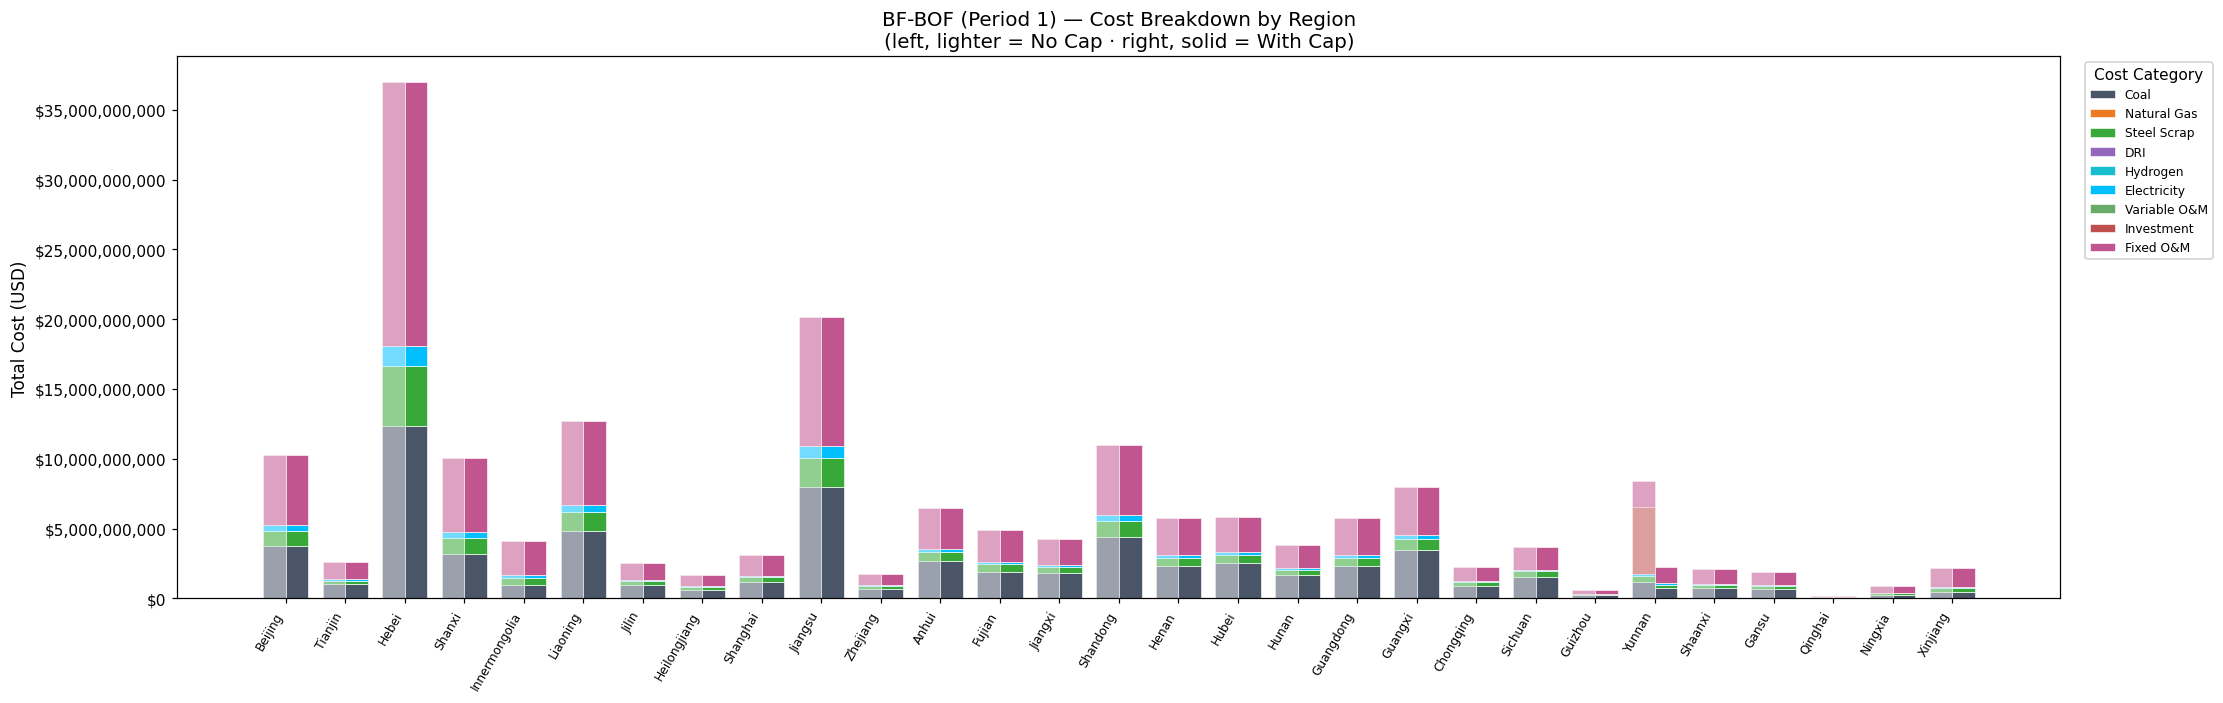

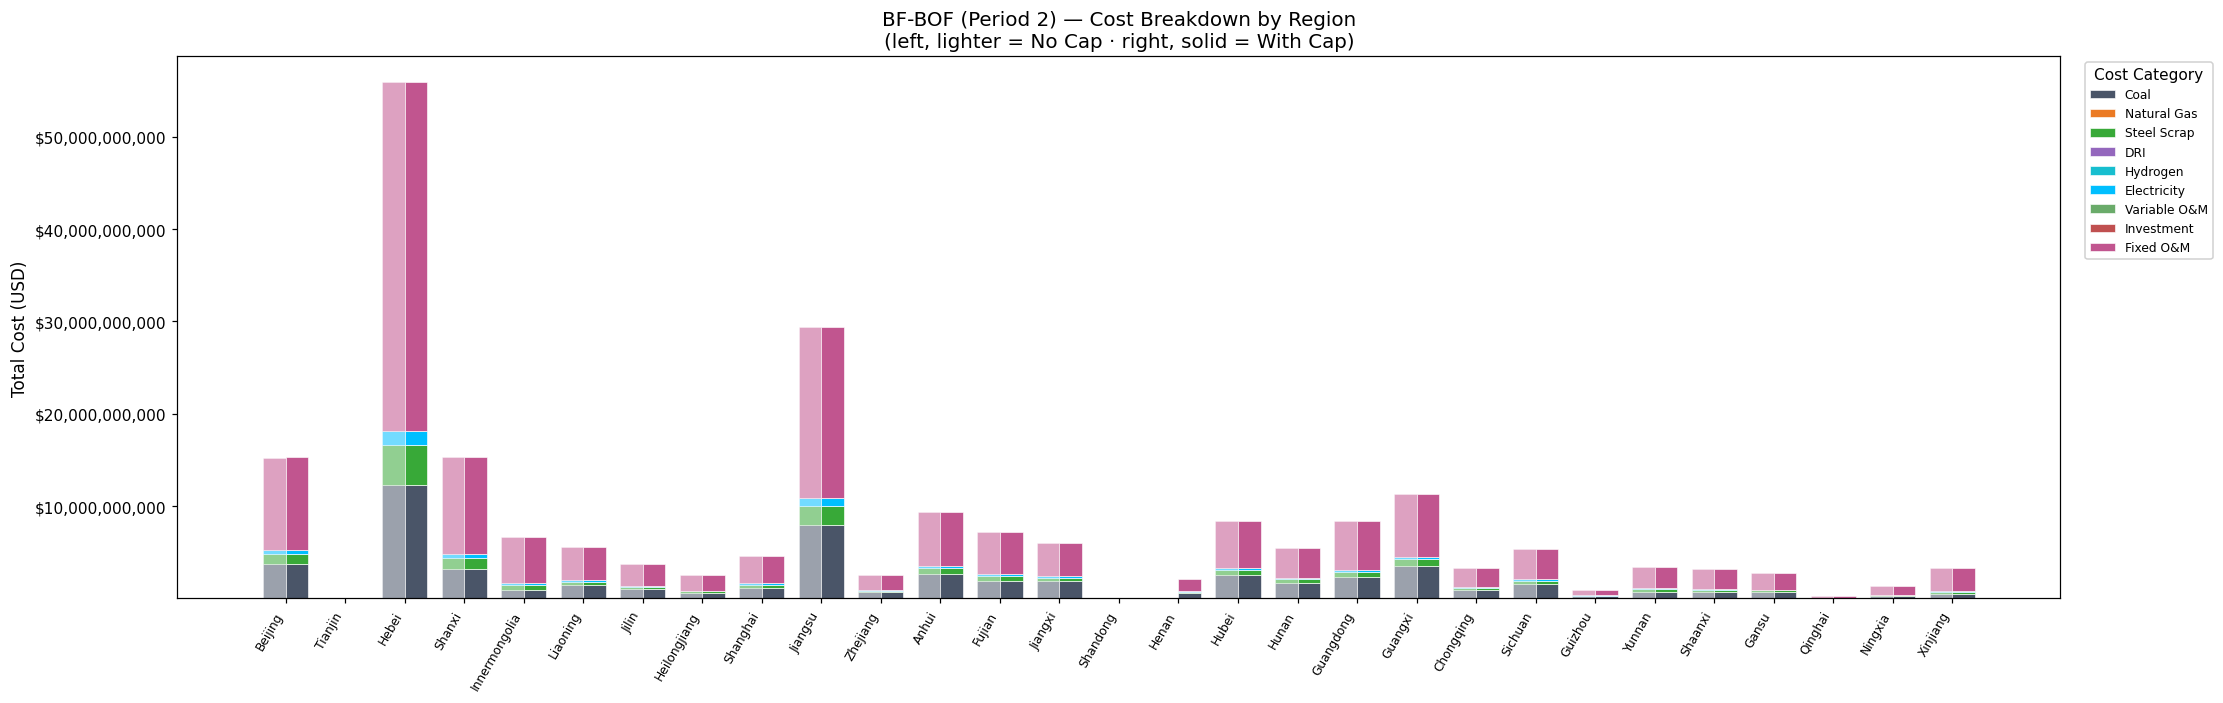

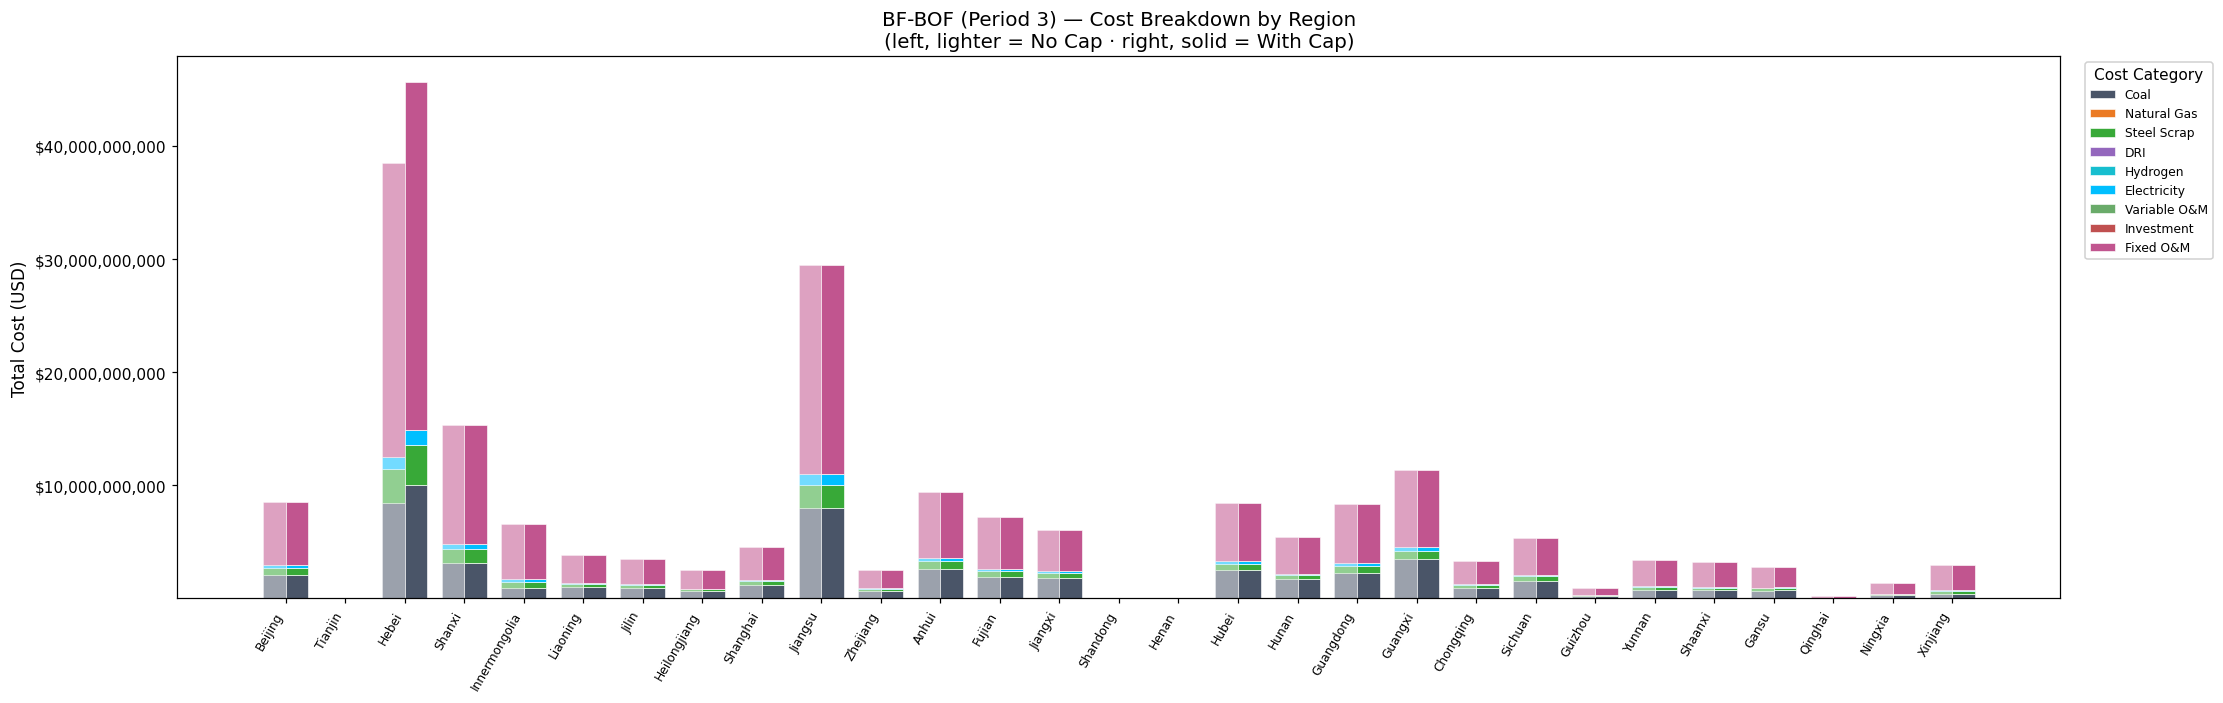

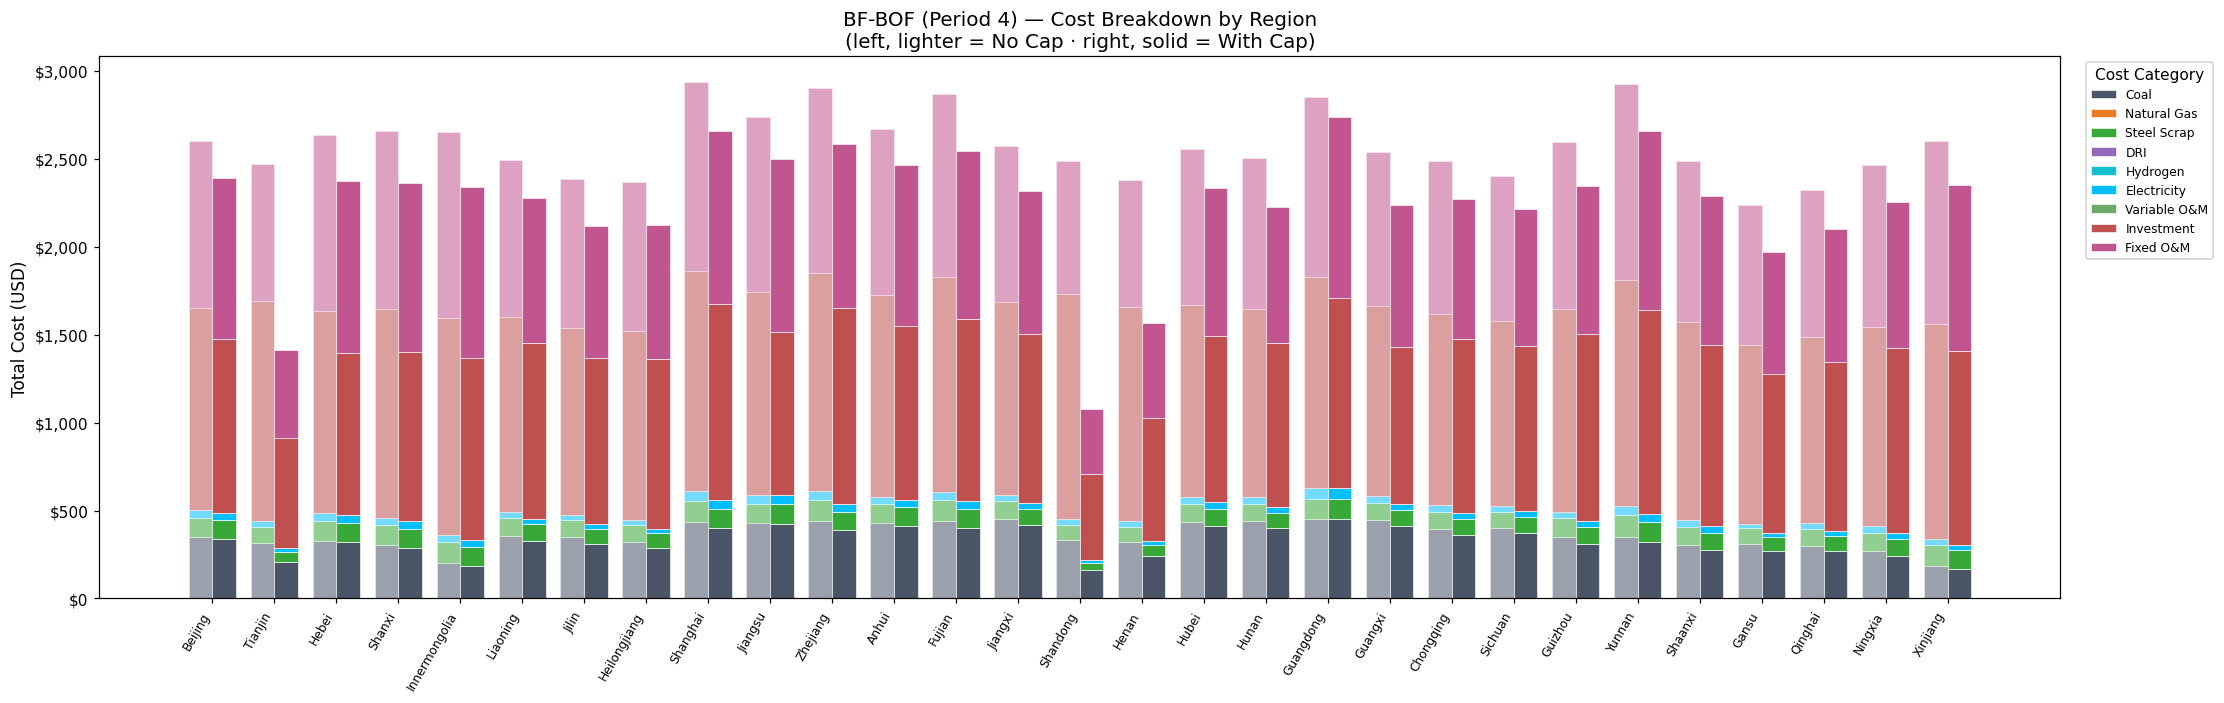

In [11]:
for period in PERIODS:
    plot_cost_stack_comparison(
        all_df, "bfbof", period, value_col="cost_usd",
        title=f"BF-BOF (Period {period}) — Cost Breakdown by Region",
        ylabel="Total Cost (USD)",
        decimals=0,
    )


## BF-BOF — per-province cost, no cap vs. with cap ($/ton steel)

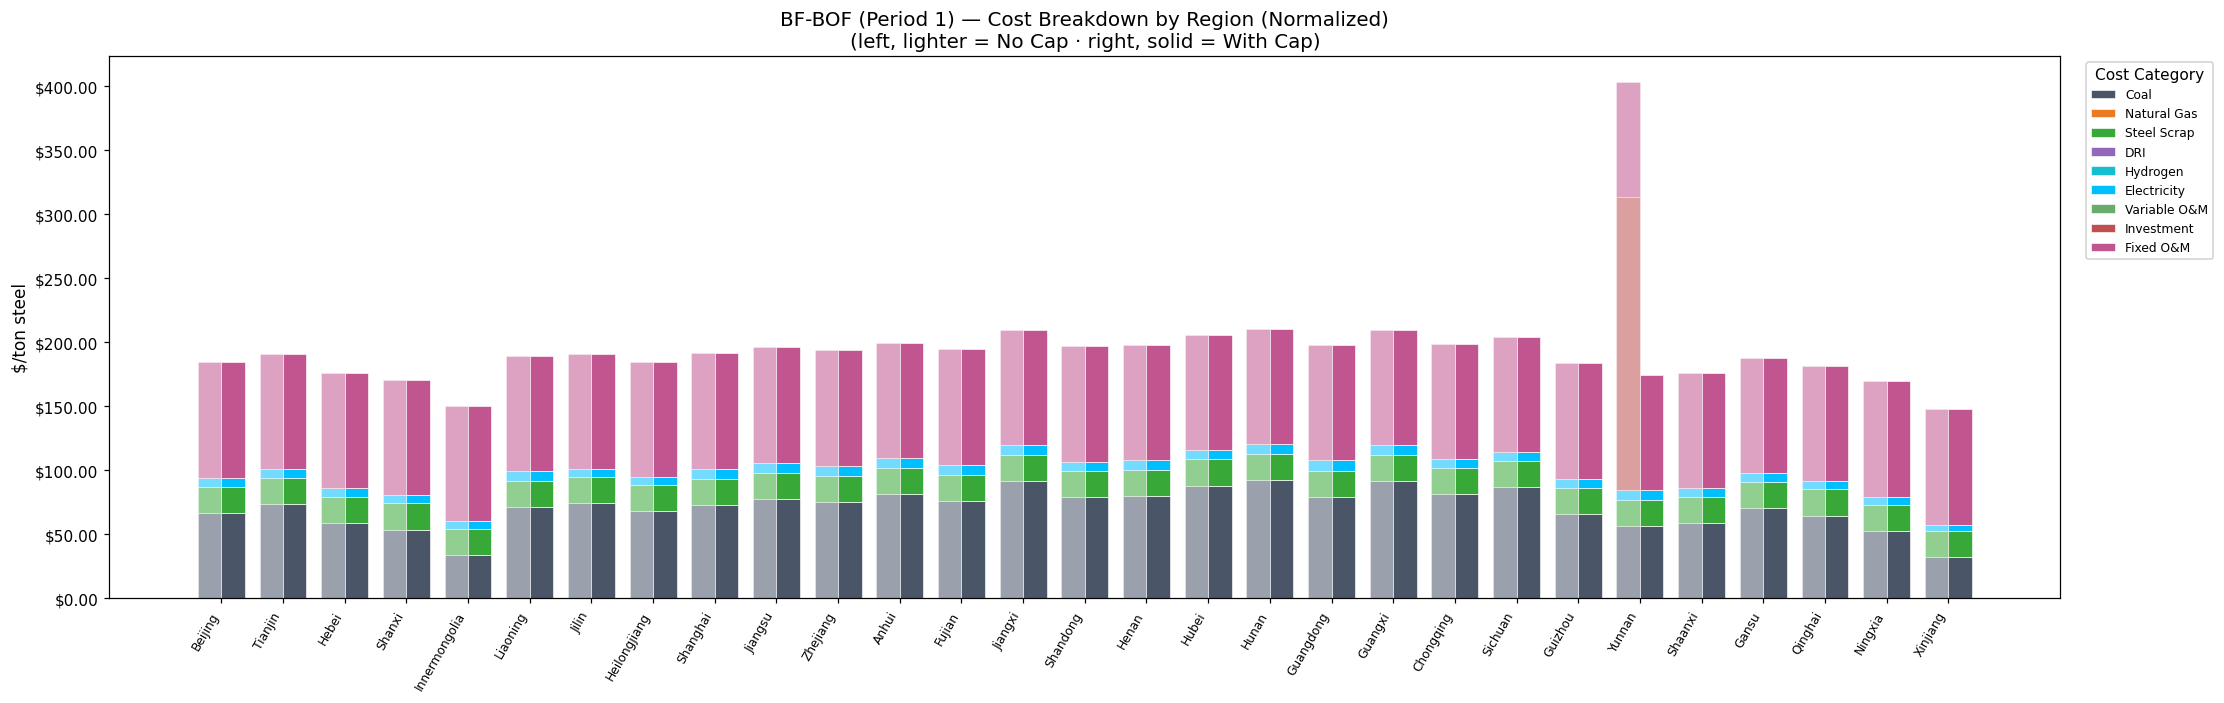

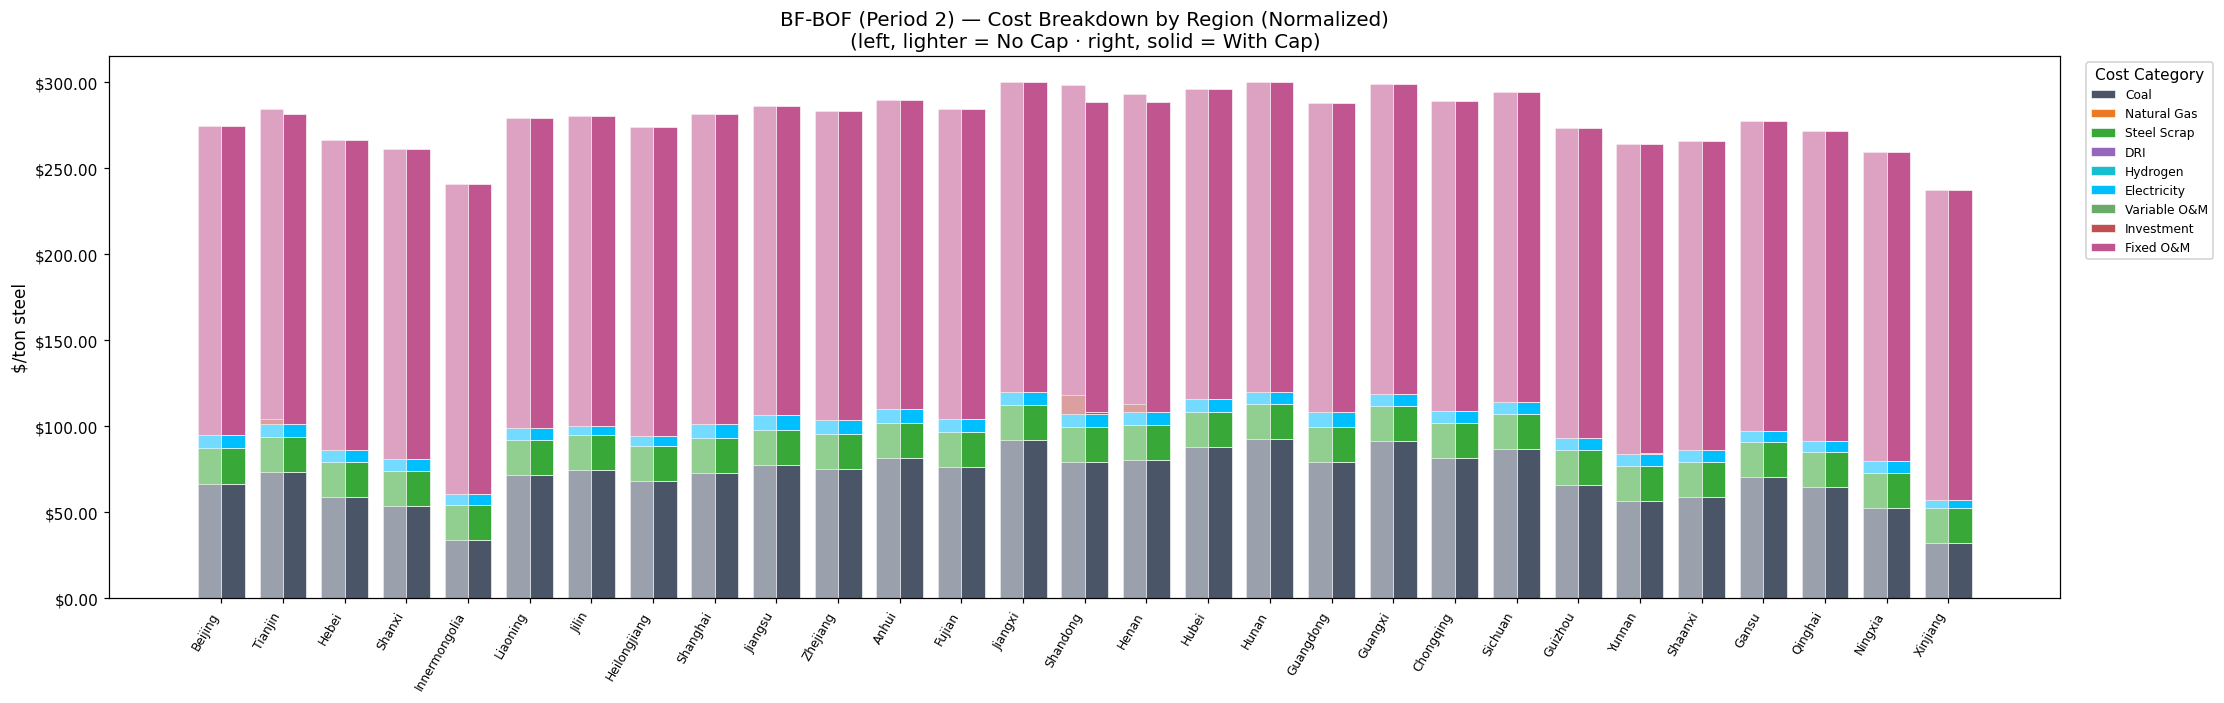

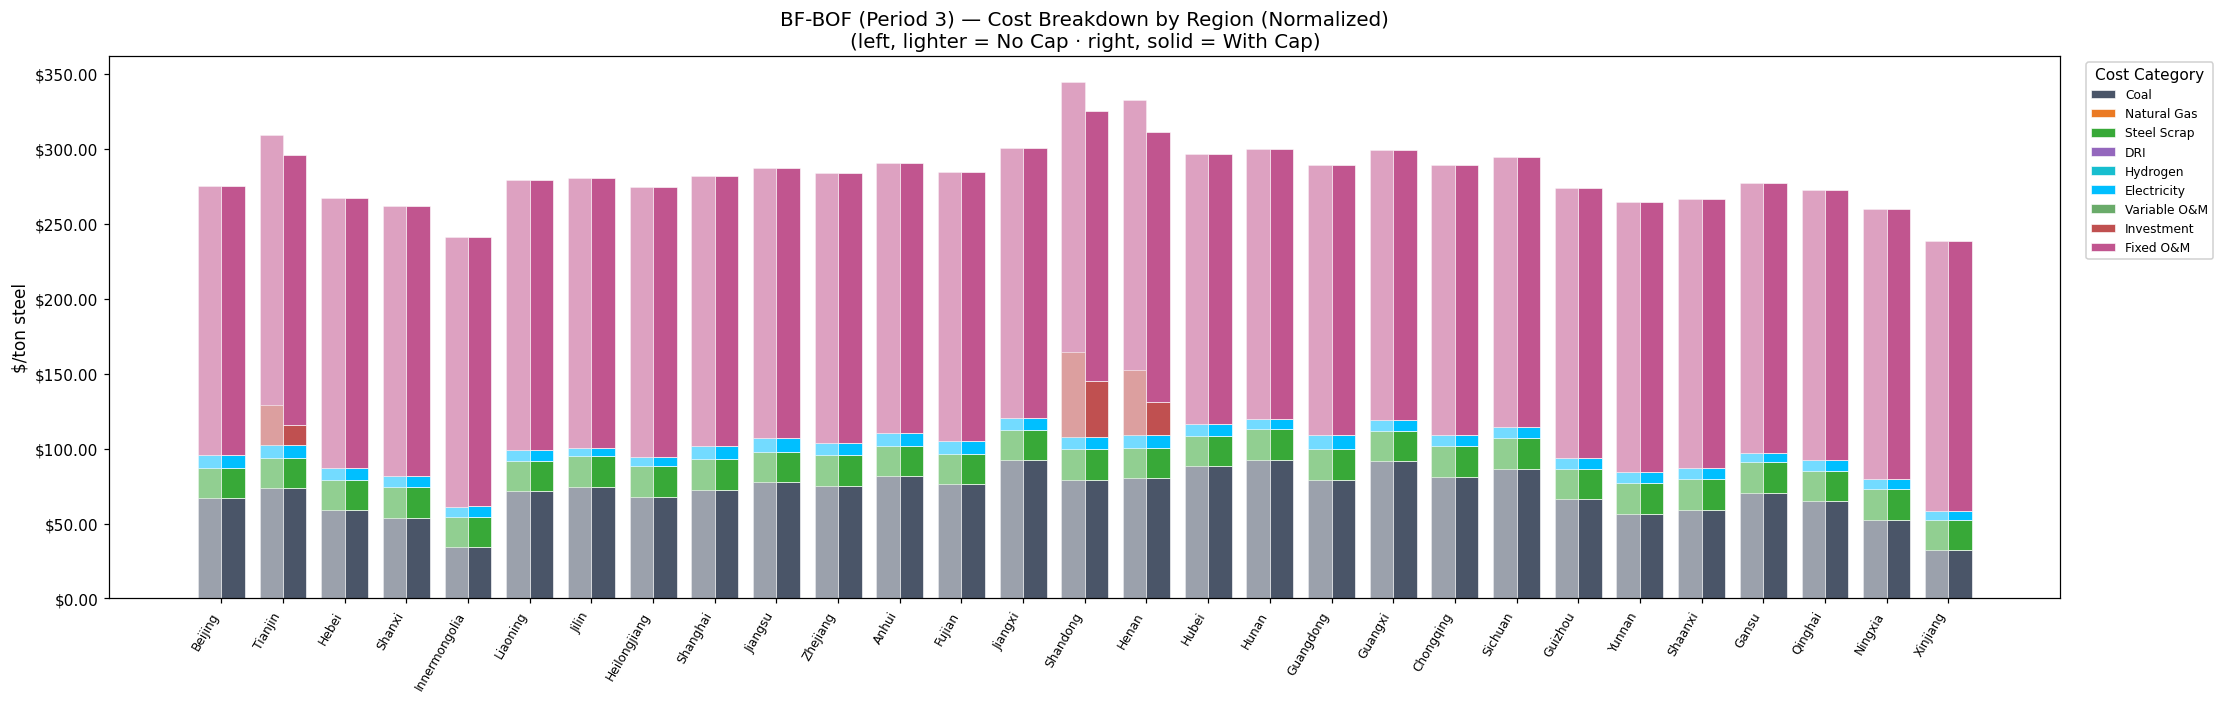

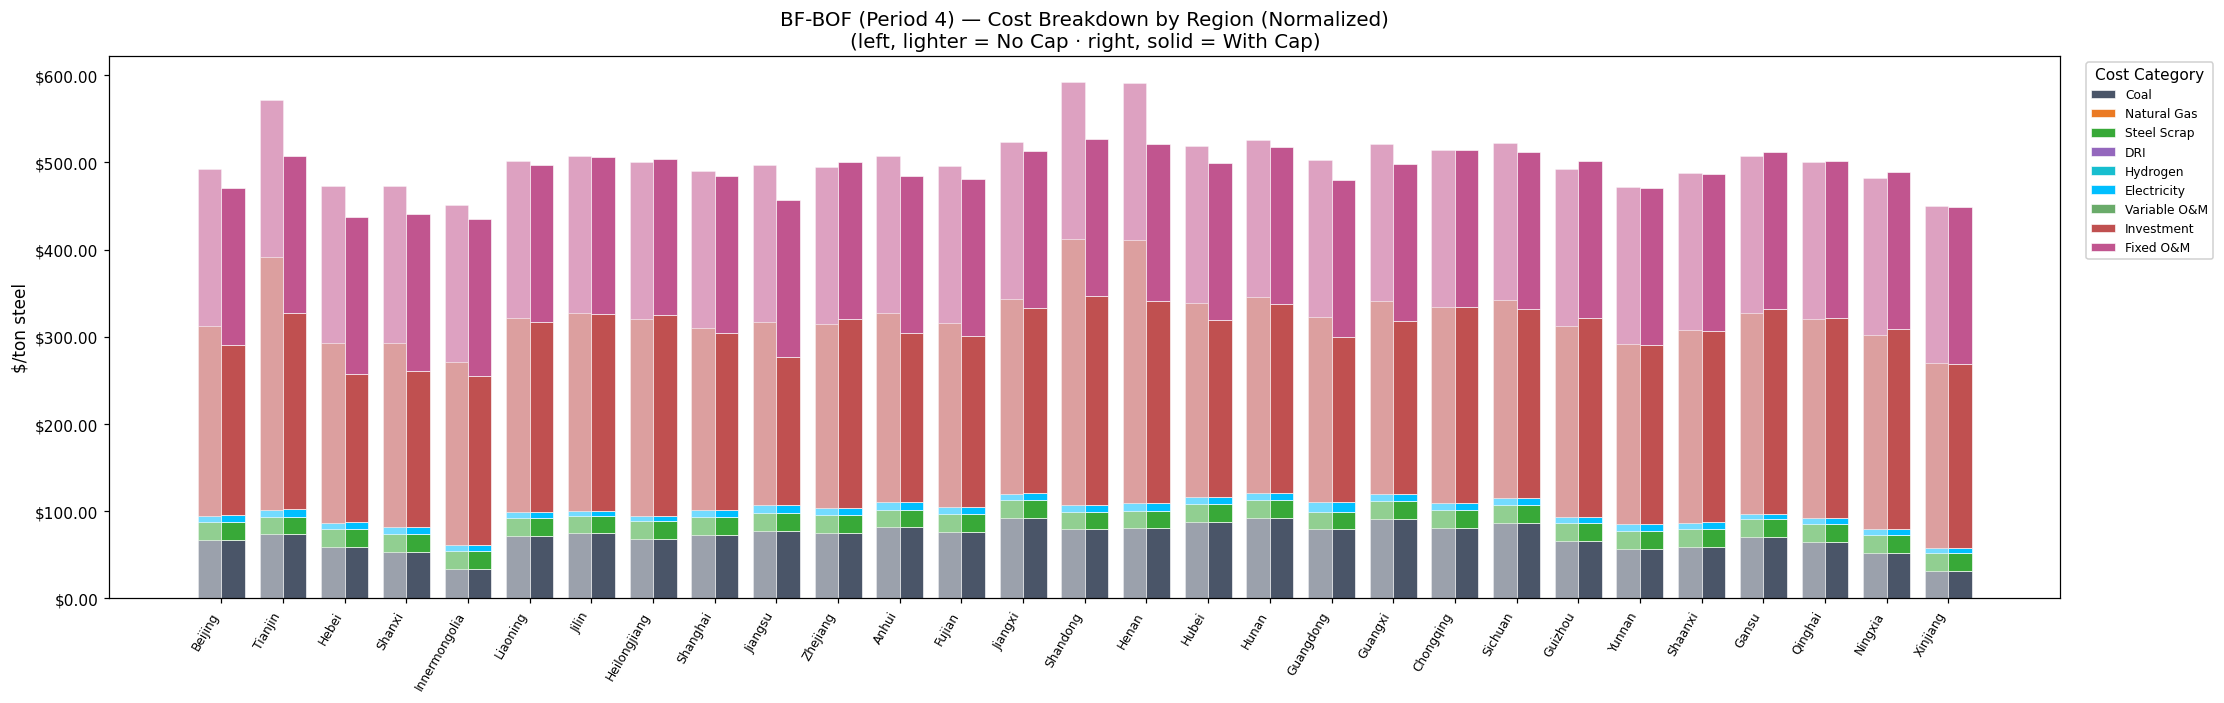

In [12]:
for period in PERIODS:
    plot_cost_stack_comparison(
        all_df, "bfbof", period, value_col="cost_per_ton",
        title=f"BF-BOF (Period {period}) — Cost Breakdown by Region (Normalized)",
        ylabel="$/ton steel",
        decimals=2,
    )


## BF-BOF — national total, unnormalized (all provinces summed)

Raw $ cost, summed across all provinces (not divided by production), by
period and scenario.


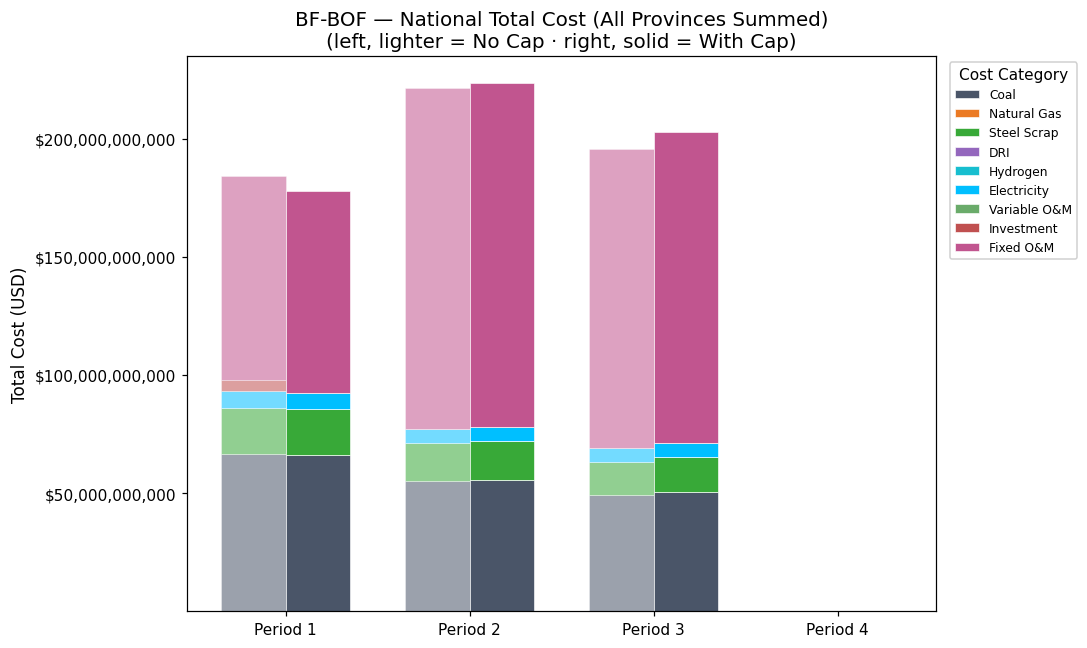

In [13]:
plot_national_total_comparison(
    all_df, "bfbof",
    title="BF-BOF — National Total Cost (All Provinces Summed)",
)


---
# BF-BOF + CCS


## BF-BOF + CCS — per-province cost, no cap vs. with cap (USD)

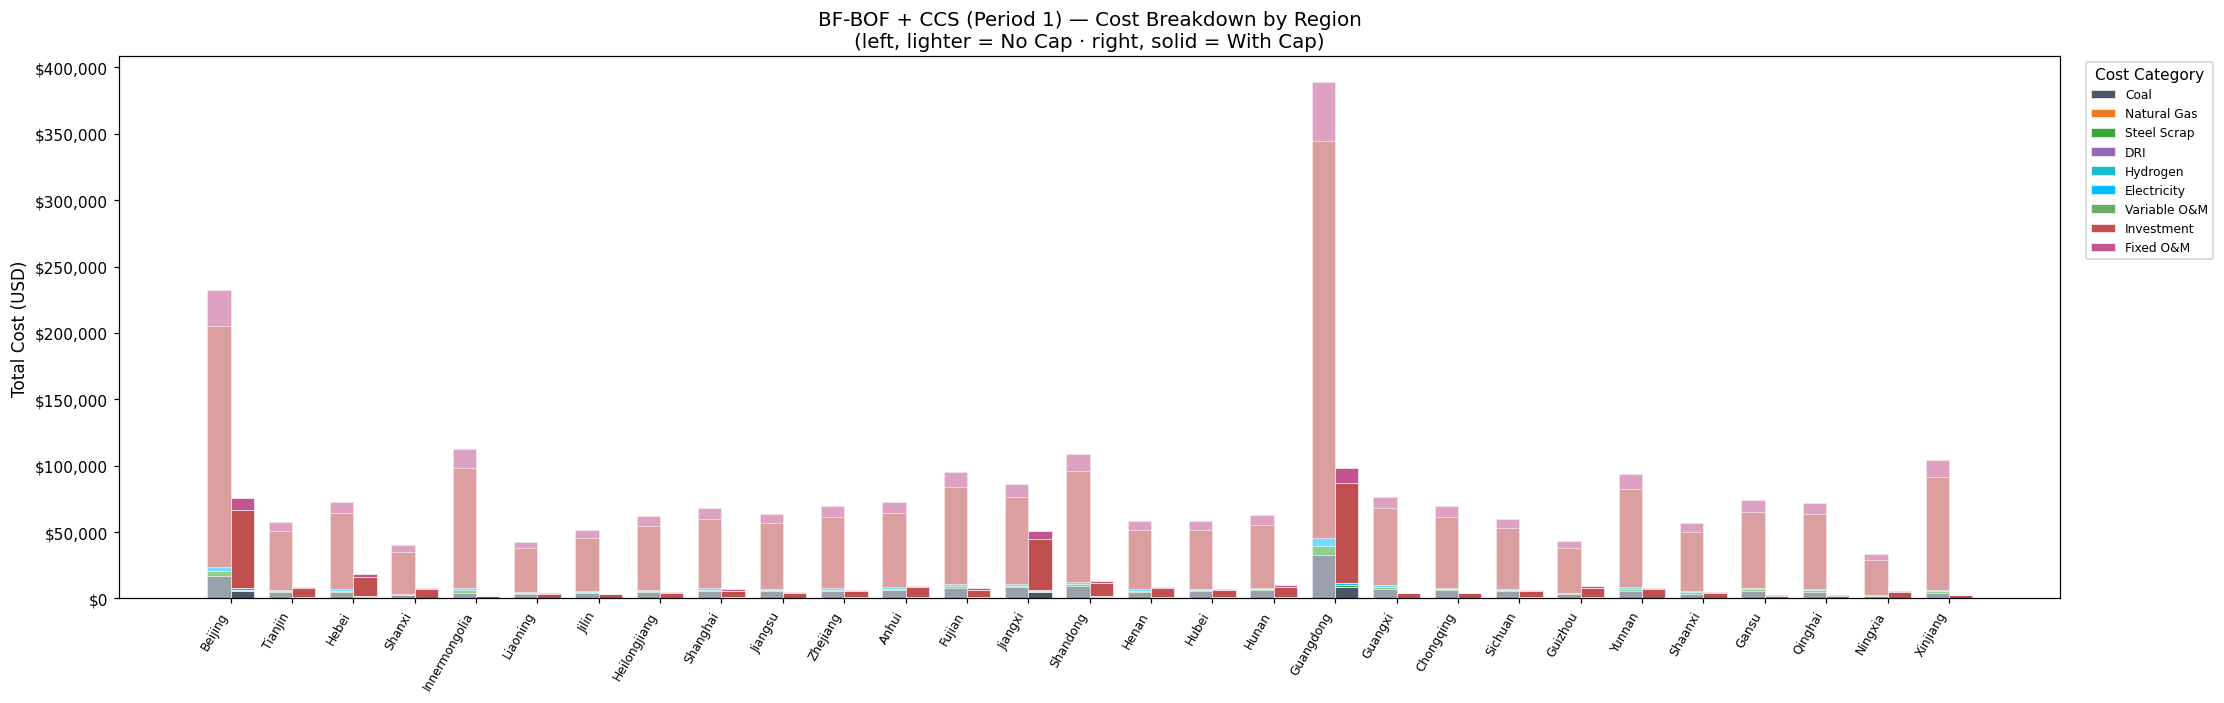

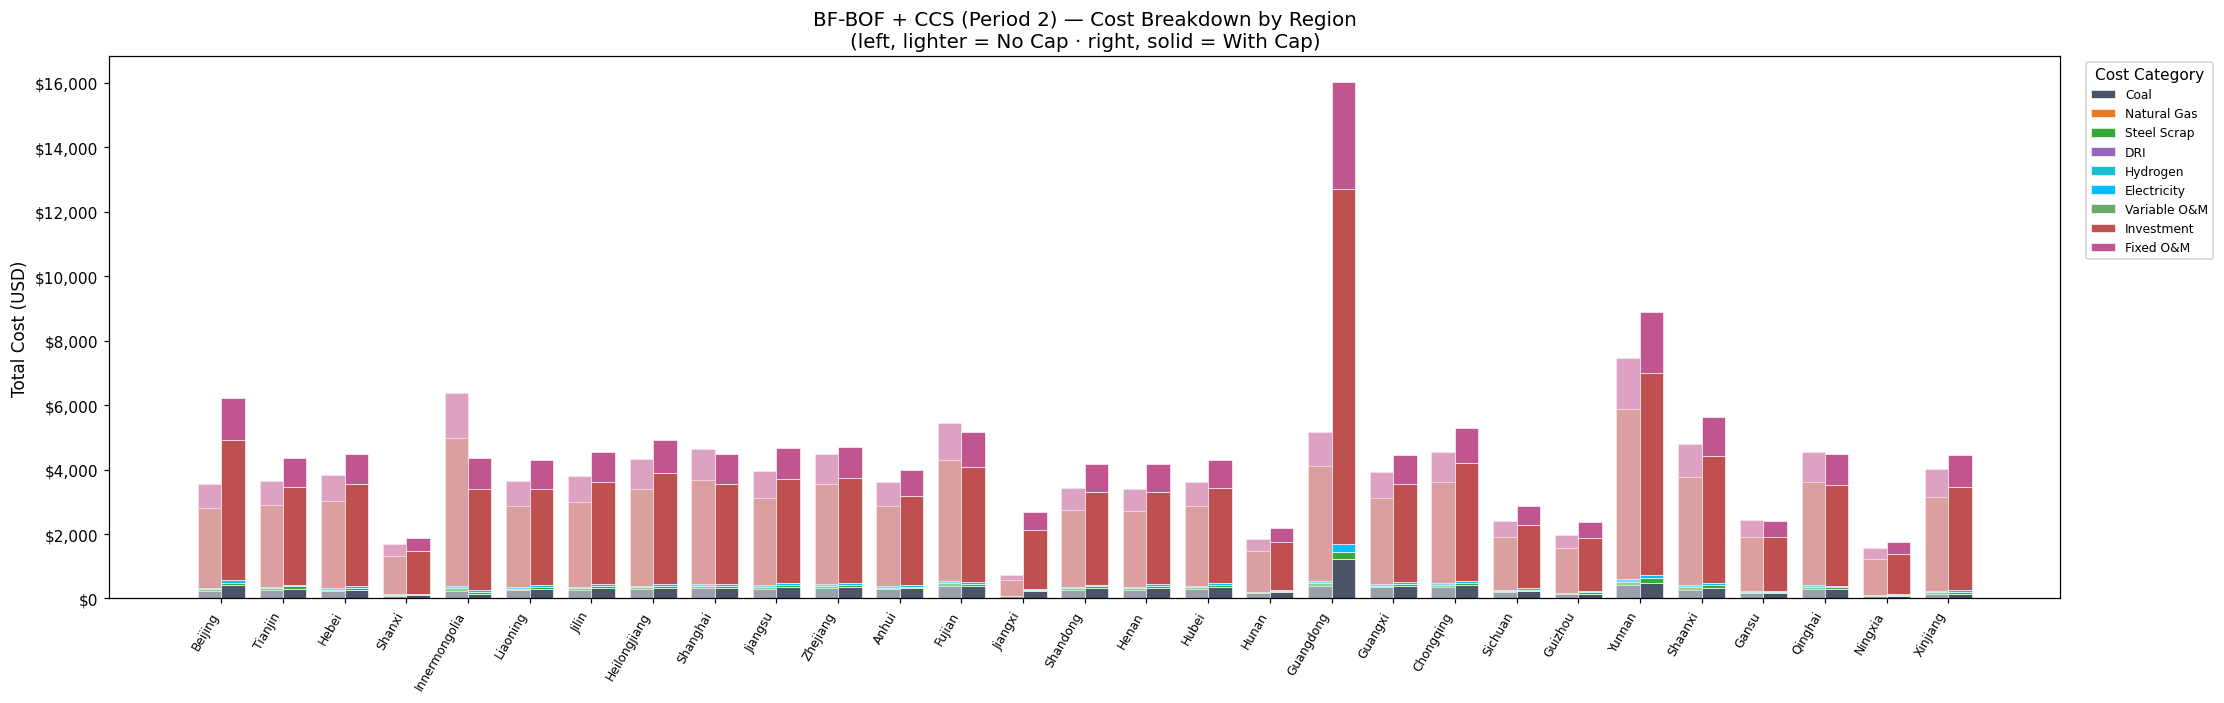

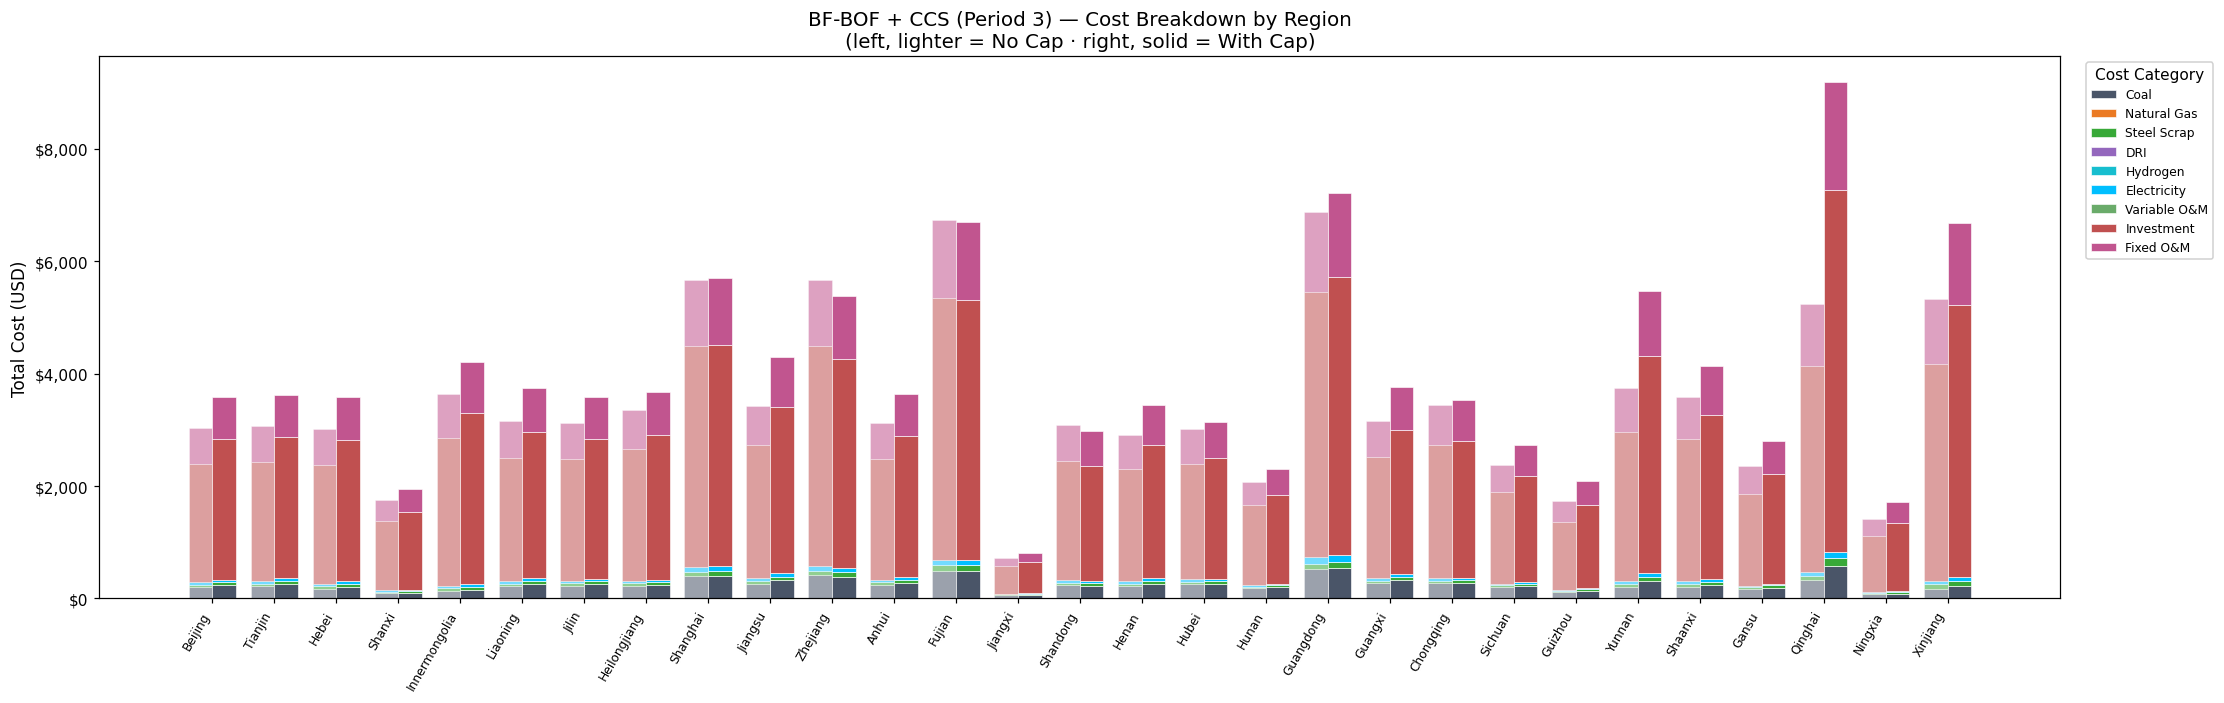

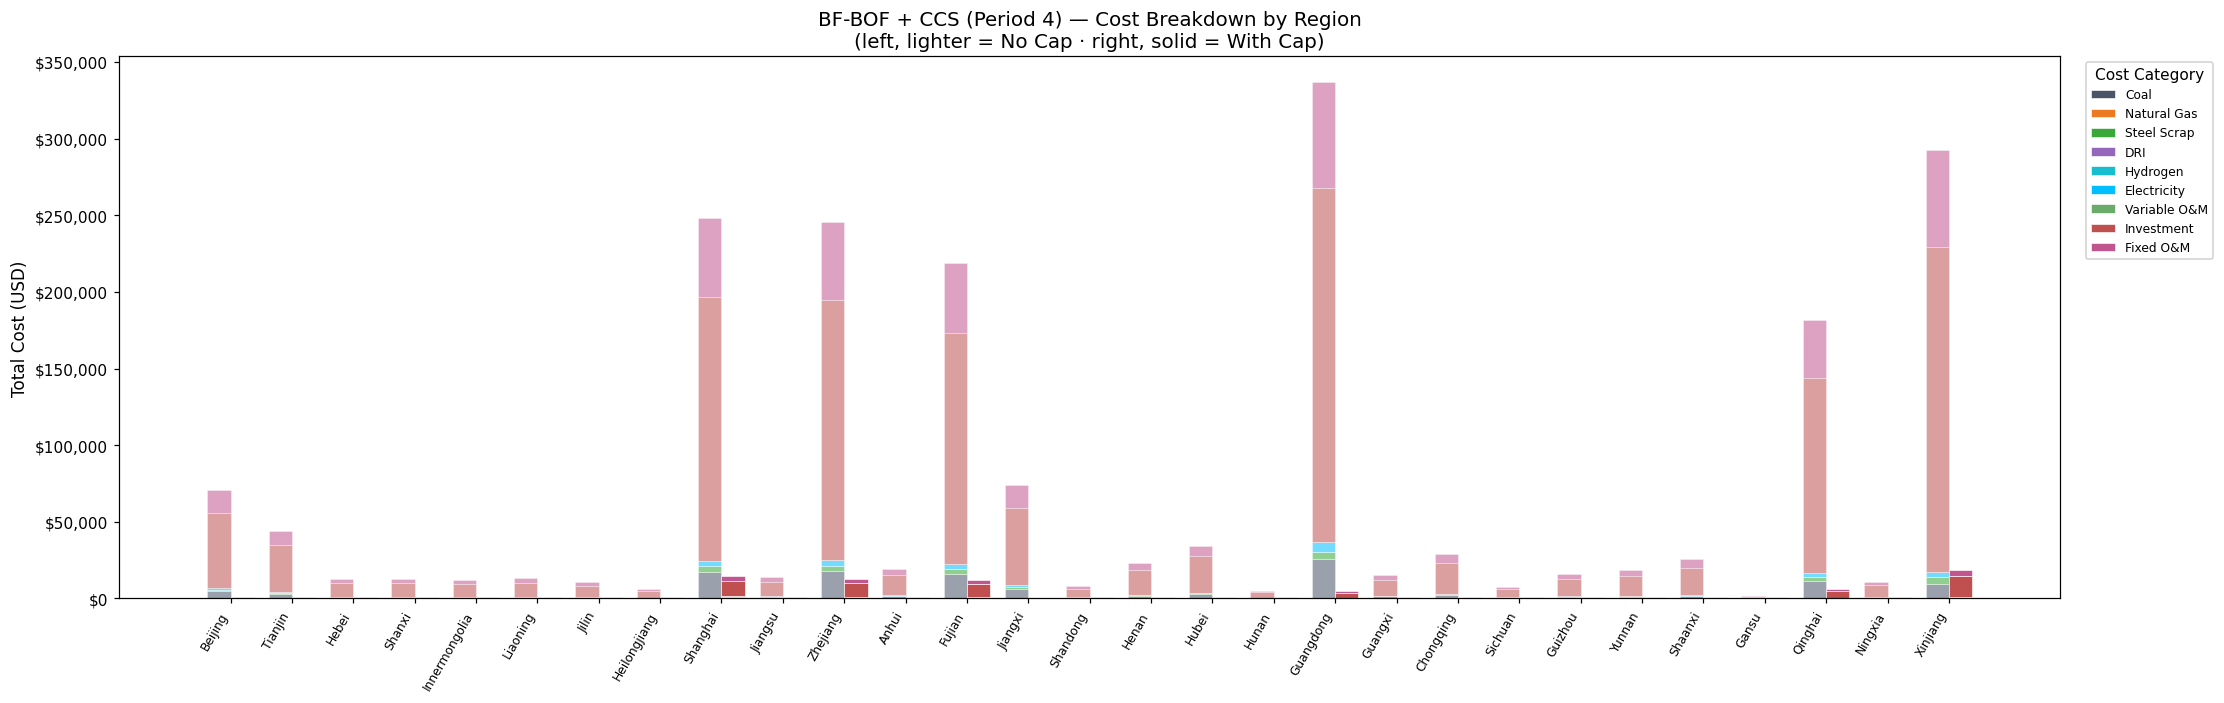

In [14]:
for period in PERIODS:
    plot_cost_stack_comparison(
        all_df, "bfbofccs", period, value_col="cost_usd",
        title=f"BF-BOF + CCS (Period {period}) — Cost Breakdown by Region",
        ylabel="Total Cost (USD)",
        decimals=0,
    )


## BF-BOF + CCS — per-province cost, no cap vs. with cap ($/ton steel)

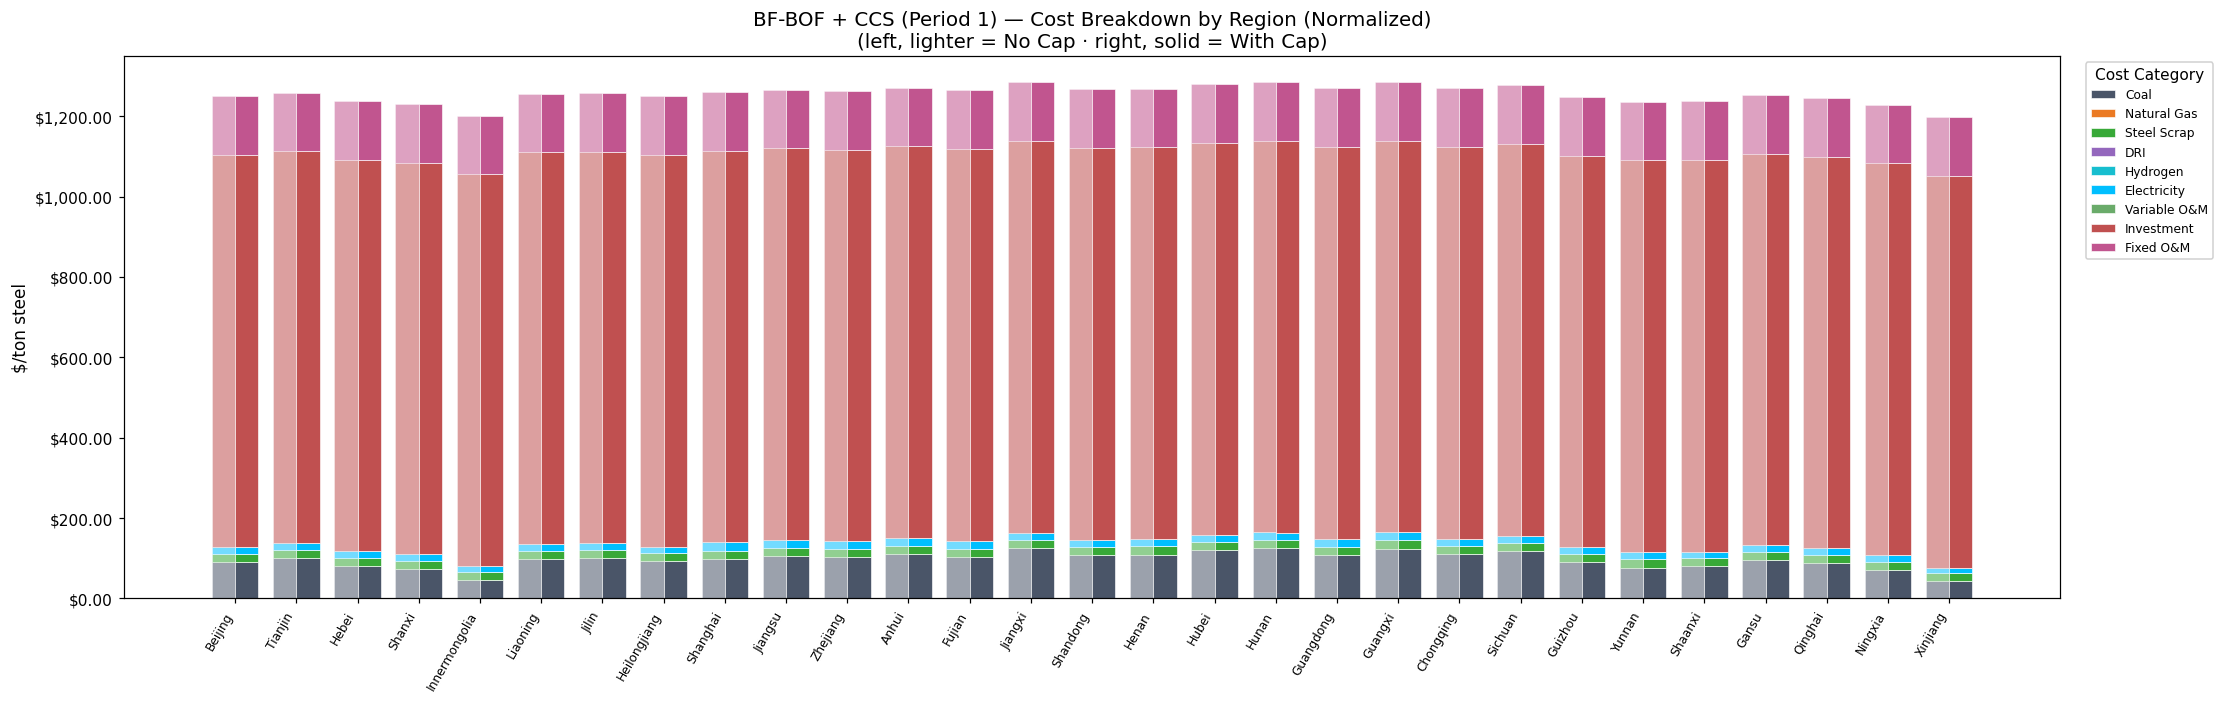

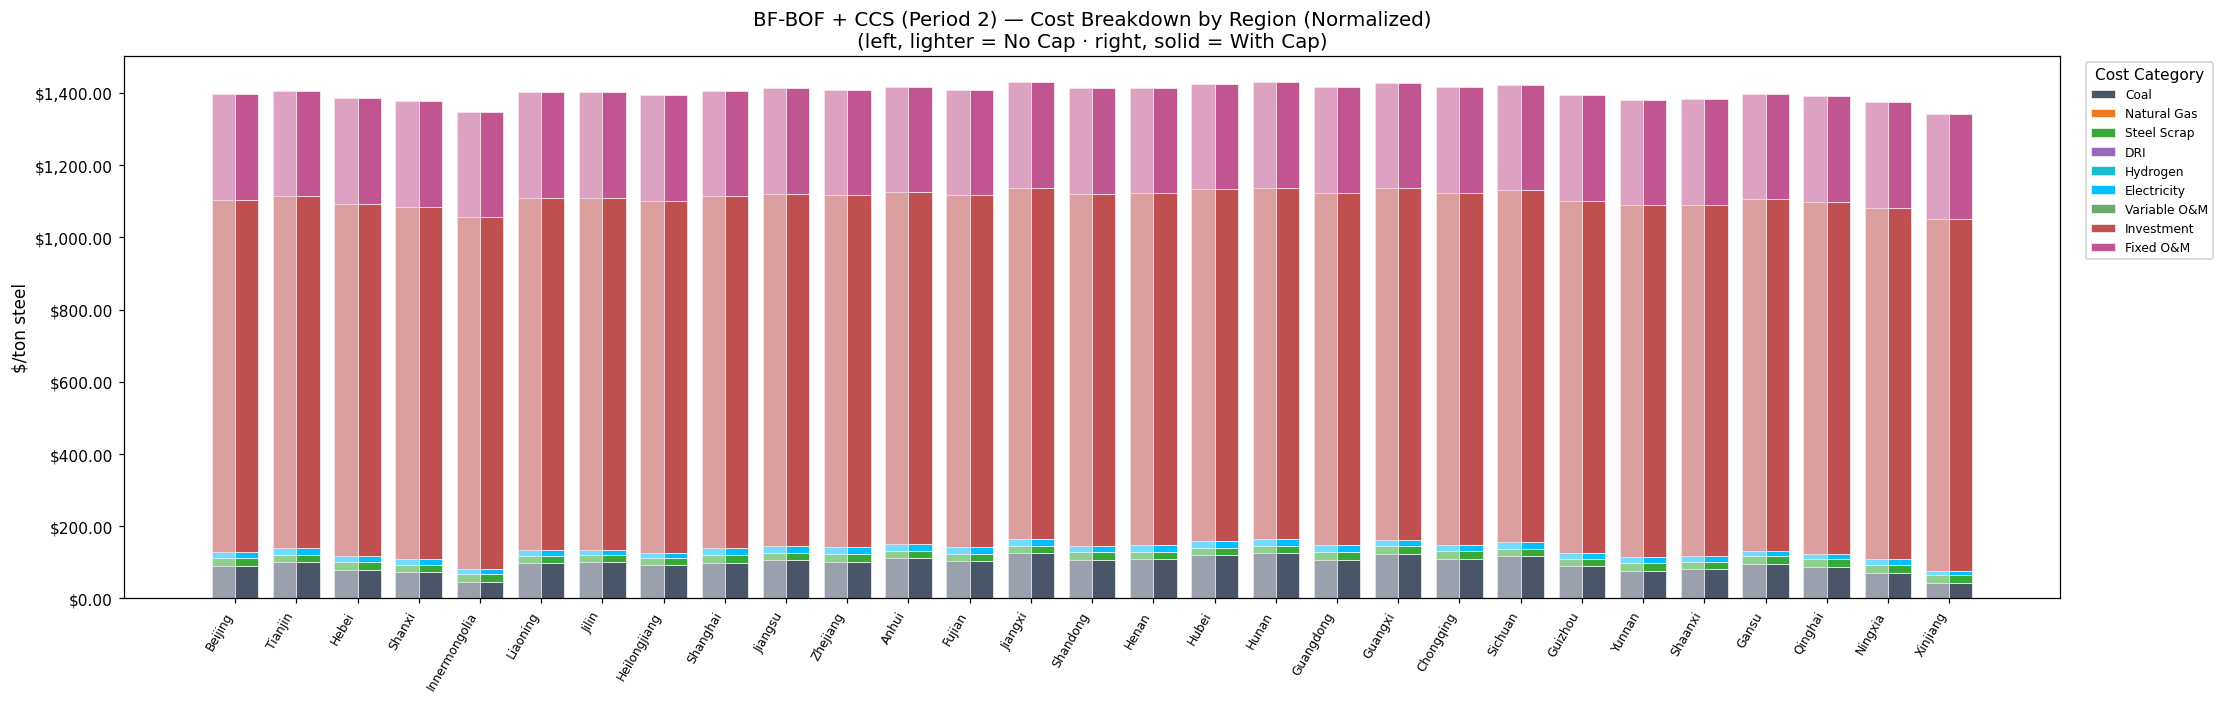

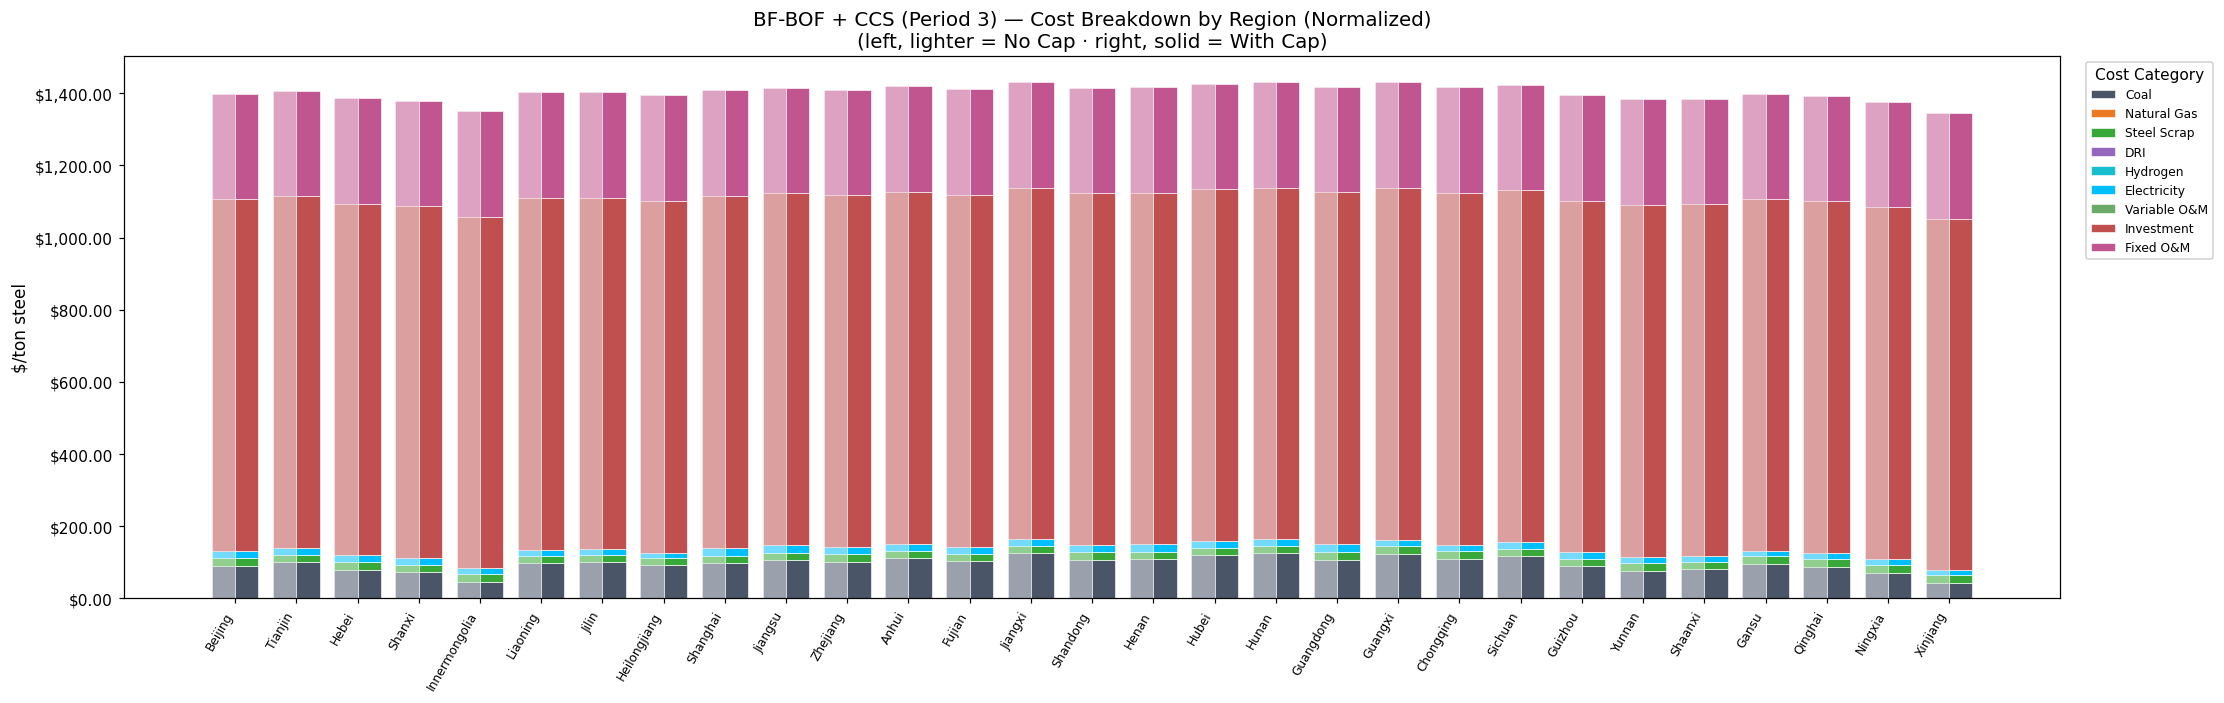

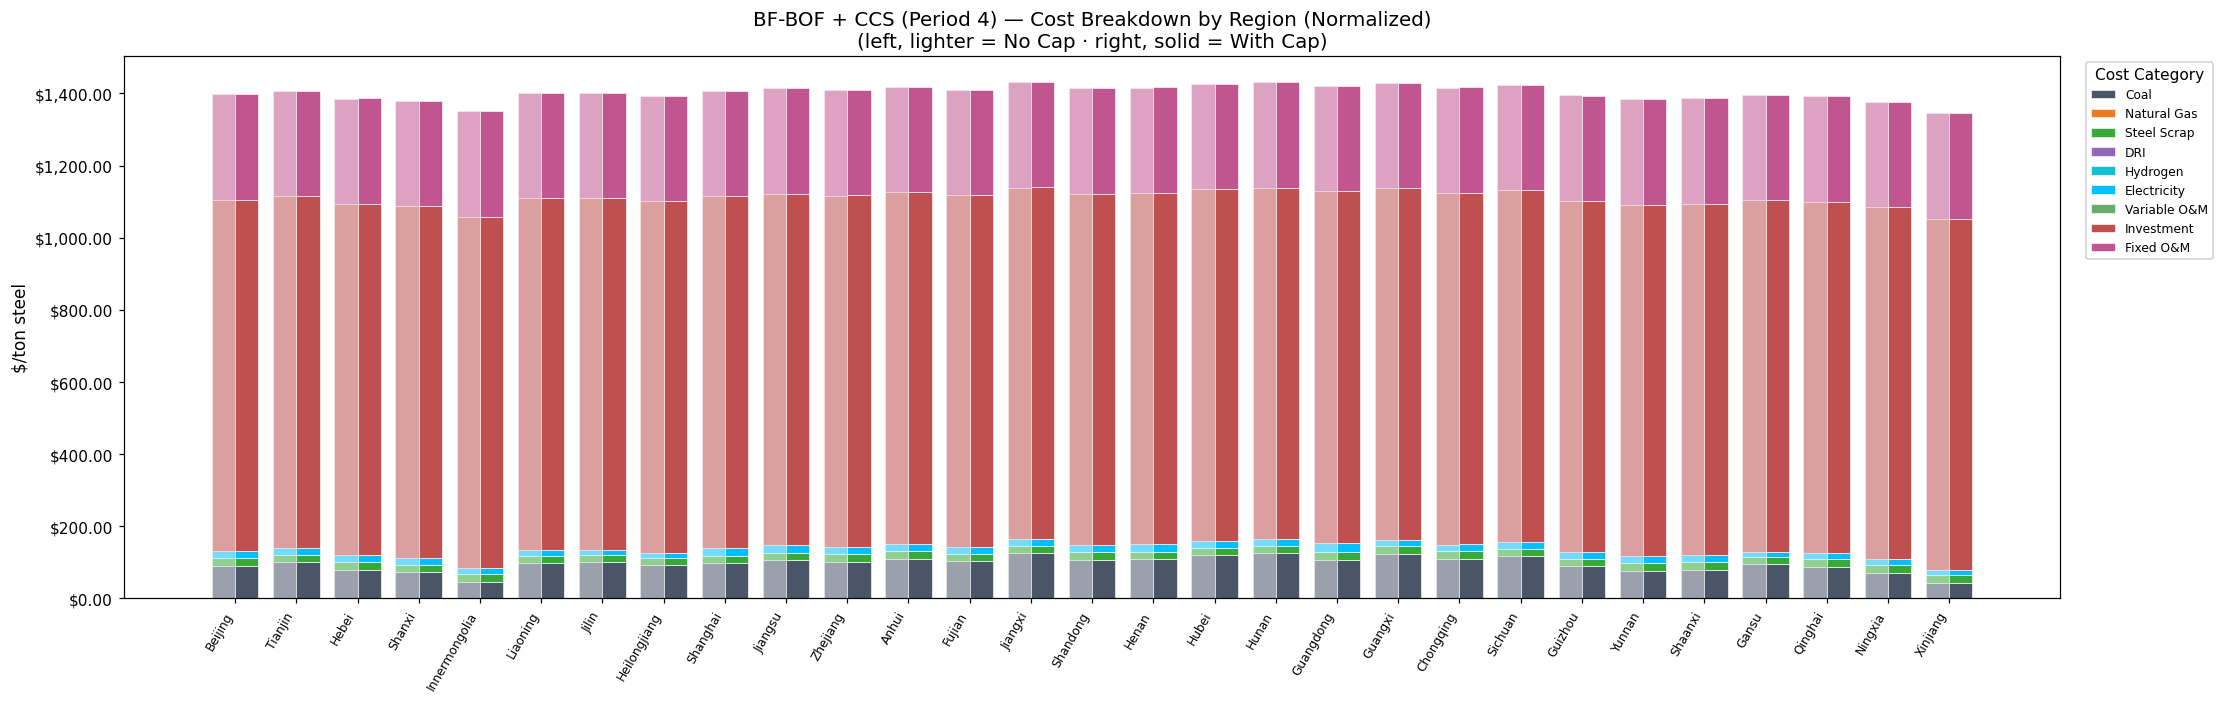

In [15]:
for period in PERIODS:
    plot_cost_stack_comparison(
        all_df, "bfbofccs", period, value_col="cost_per_ton",
        title=f"BF-BOF + CCS (Period {period}) — Cost Breakdown by Region (Normalized)",
        ylabel="$/ton steel",
        decimals=2,
    )


## BF-BOF + CCS — national total, unnormalized (all provinces summed)

Raw $ cost, summed across all provinces (not divided by production), by
period and scenario.


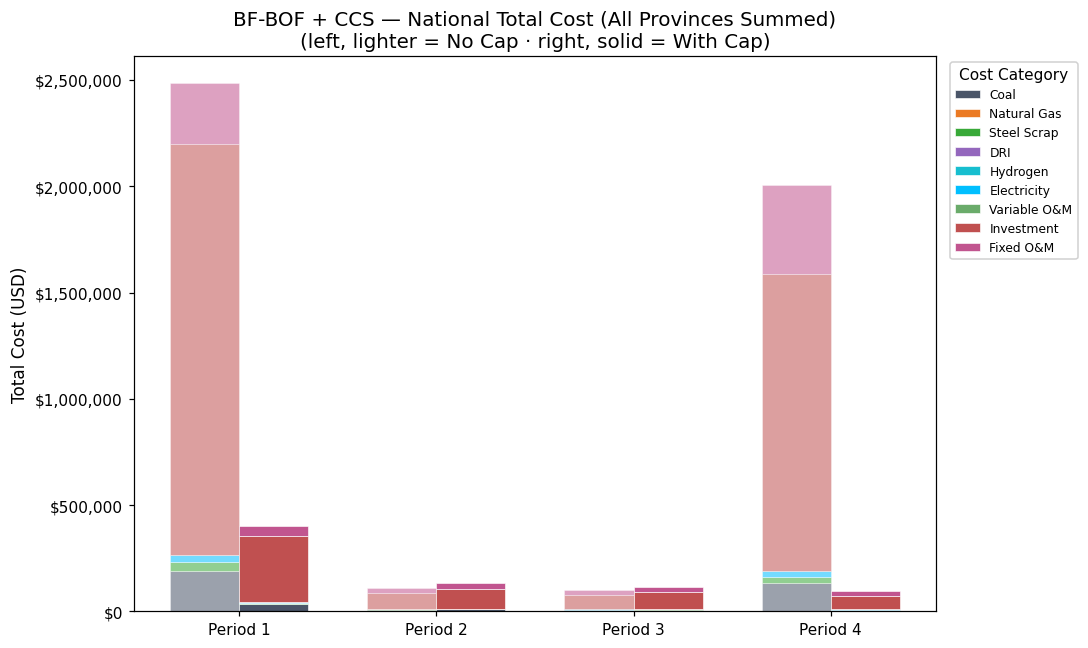

In [16]:
plot_national_total_comparison(
    all_df, "bfbofccs",
    title="BF-BOF + CCS — National Total Cost (All Provinces Summed)",
)


---
# DRI-EAF


## DRI-EAF — per-province cost, no cap vs. with cap (USD)

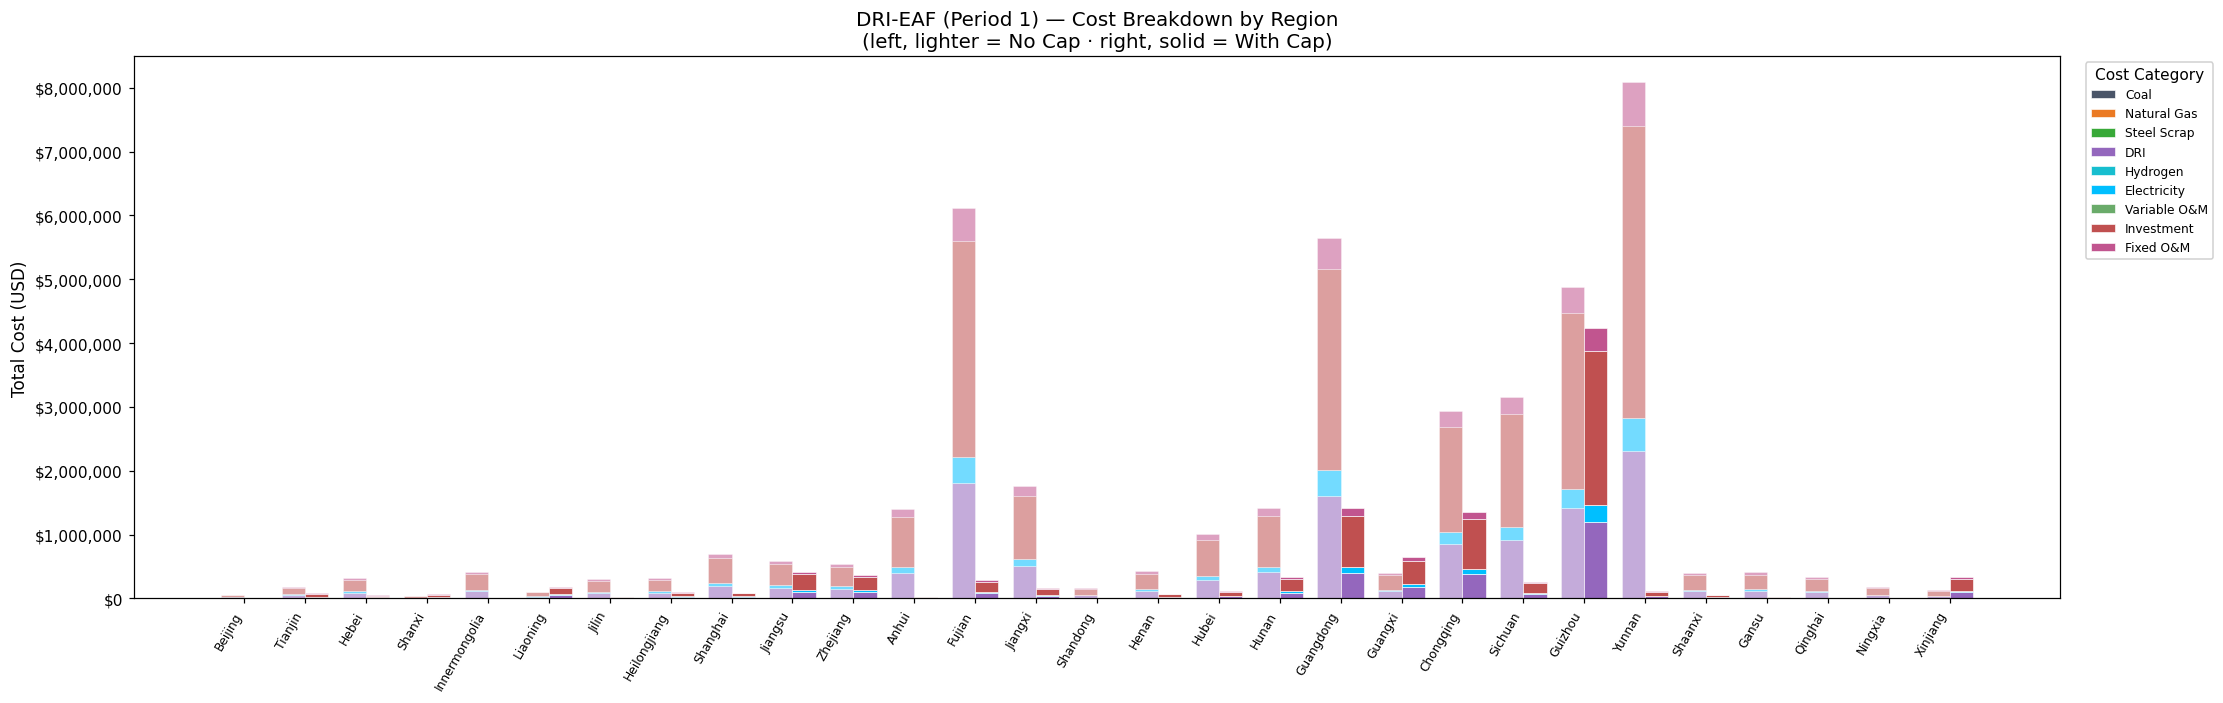

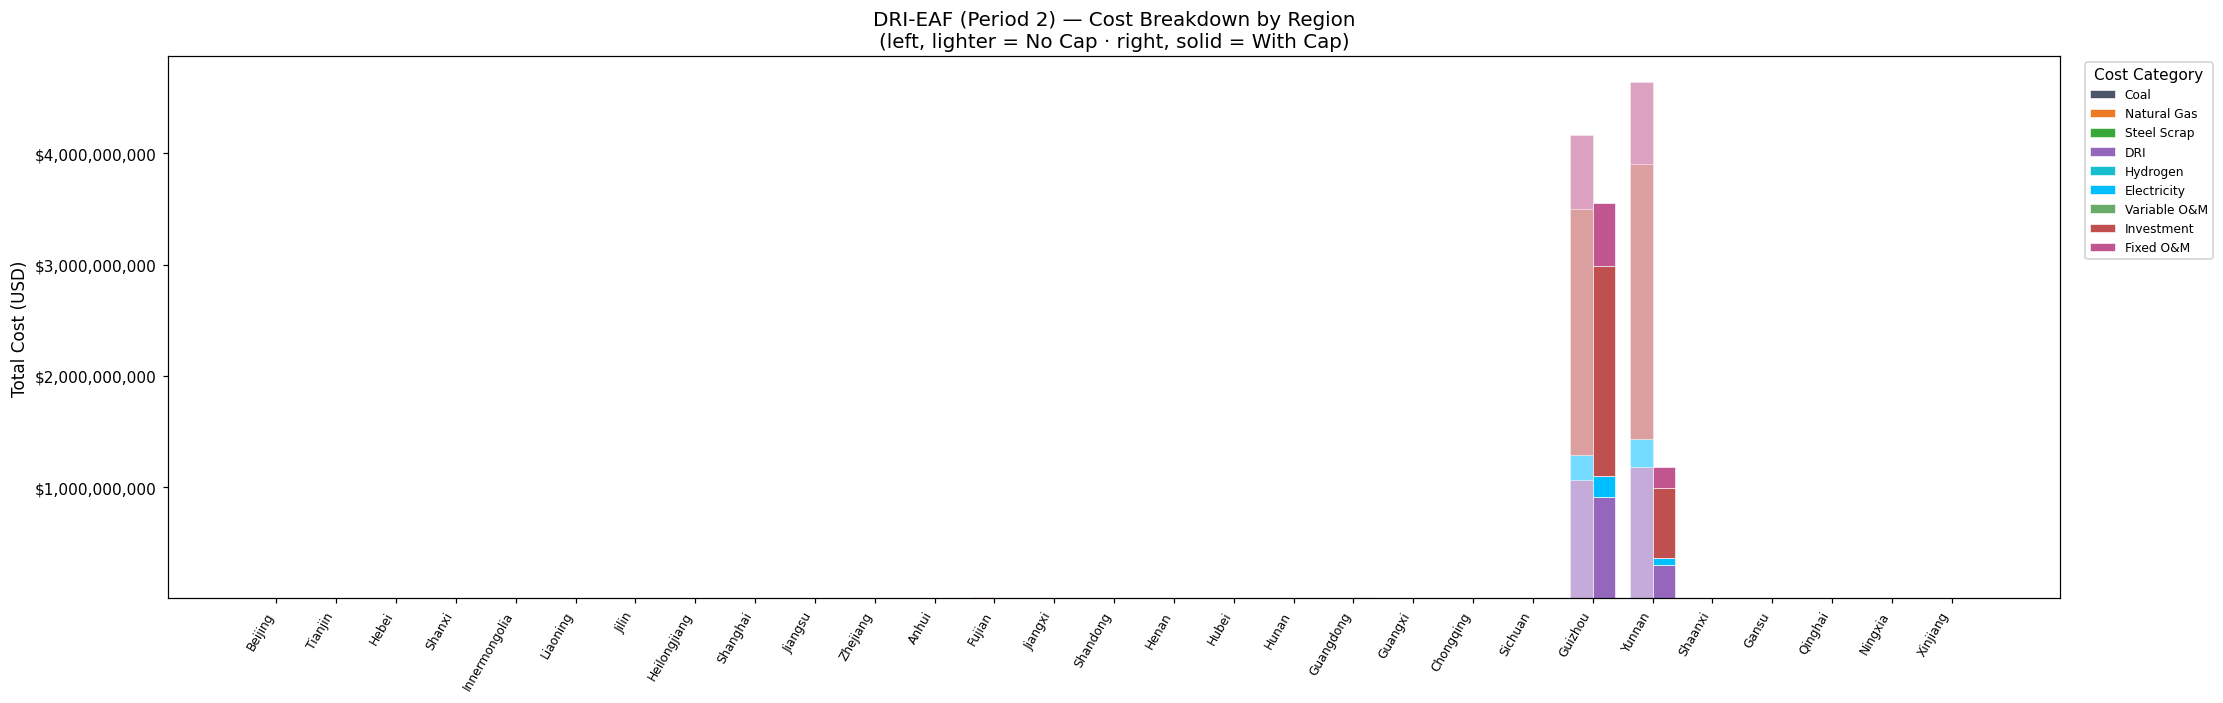

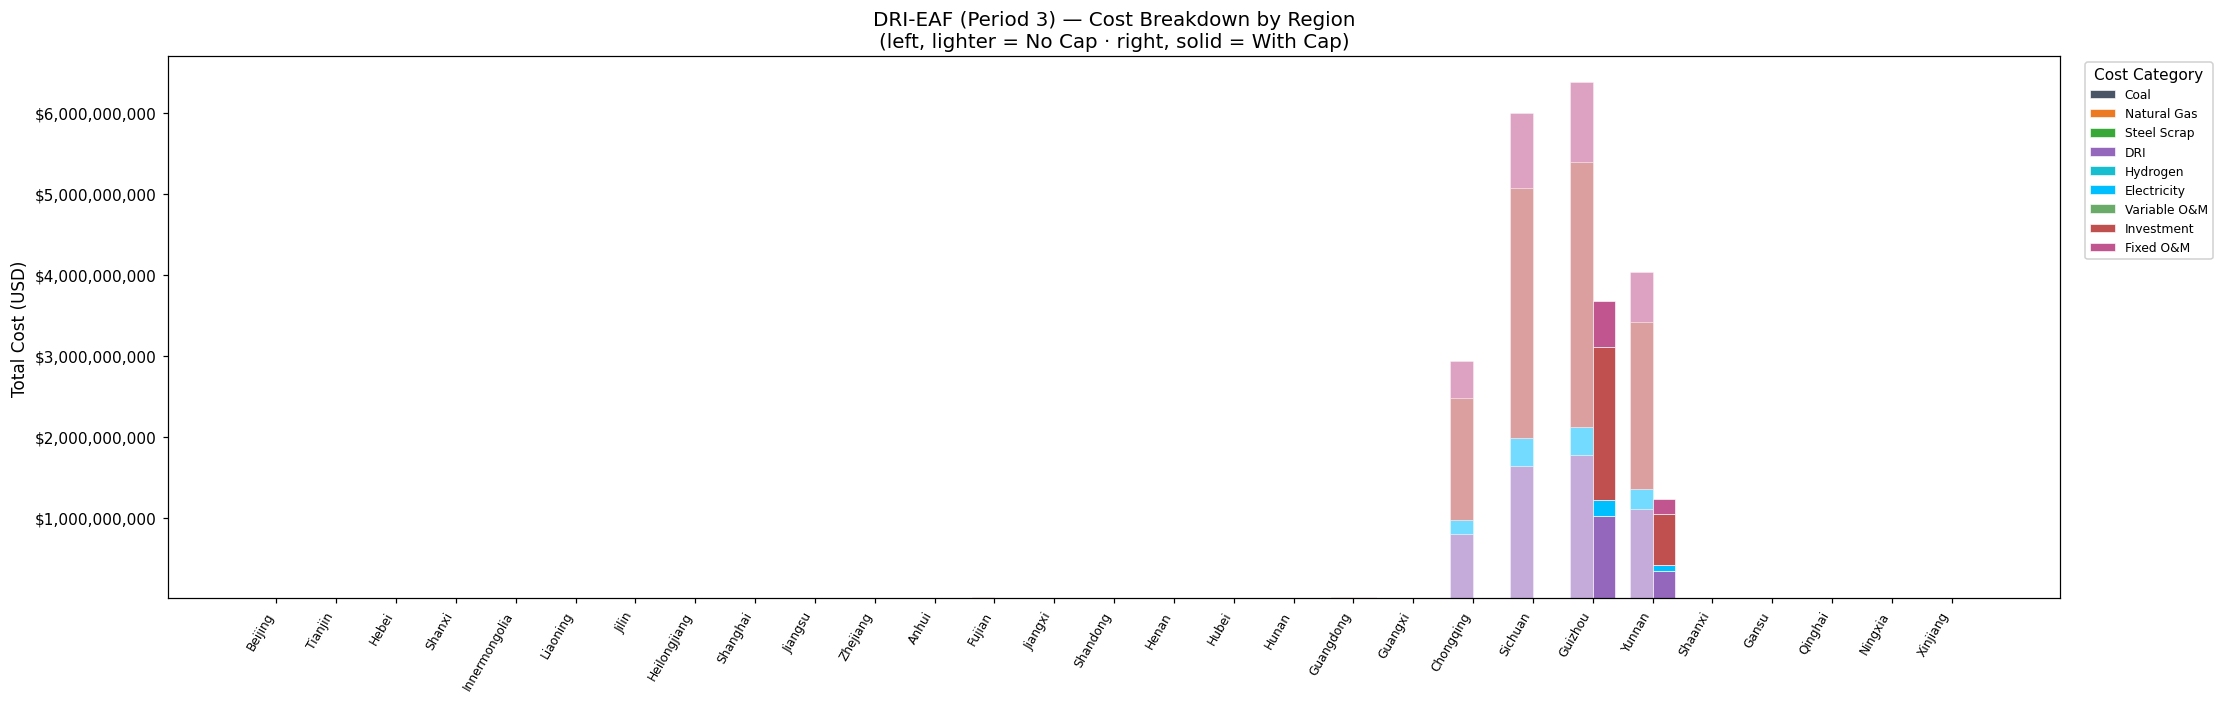

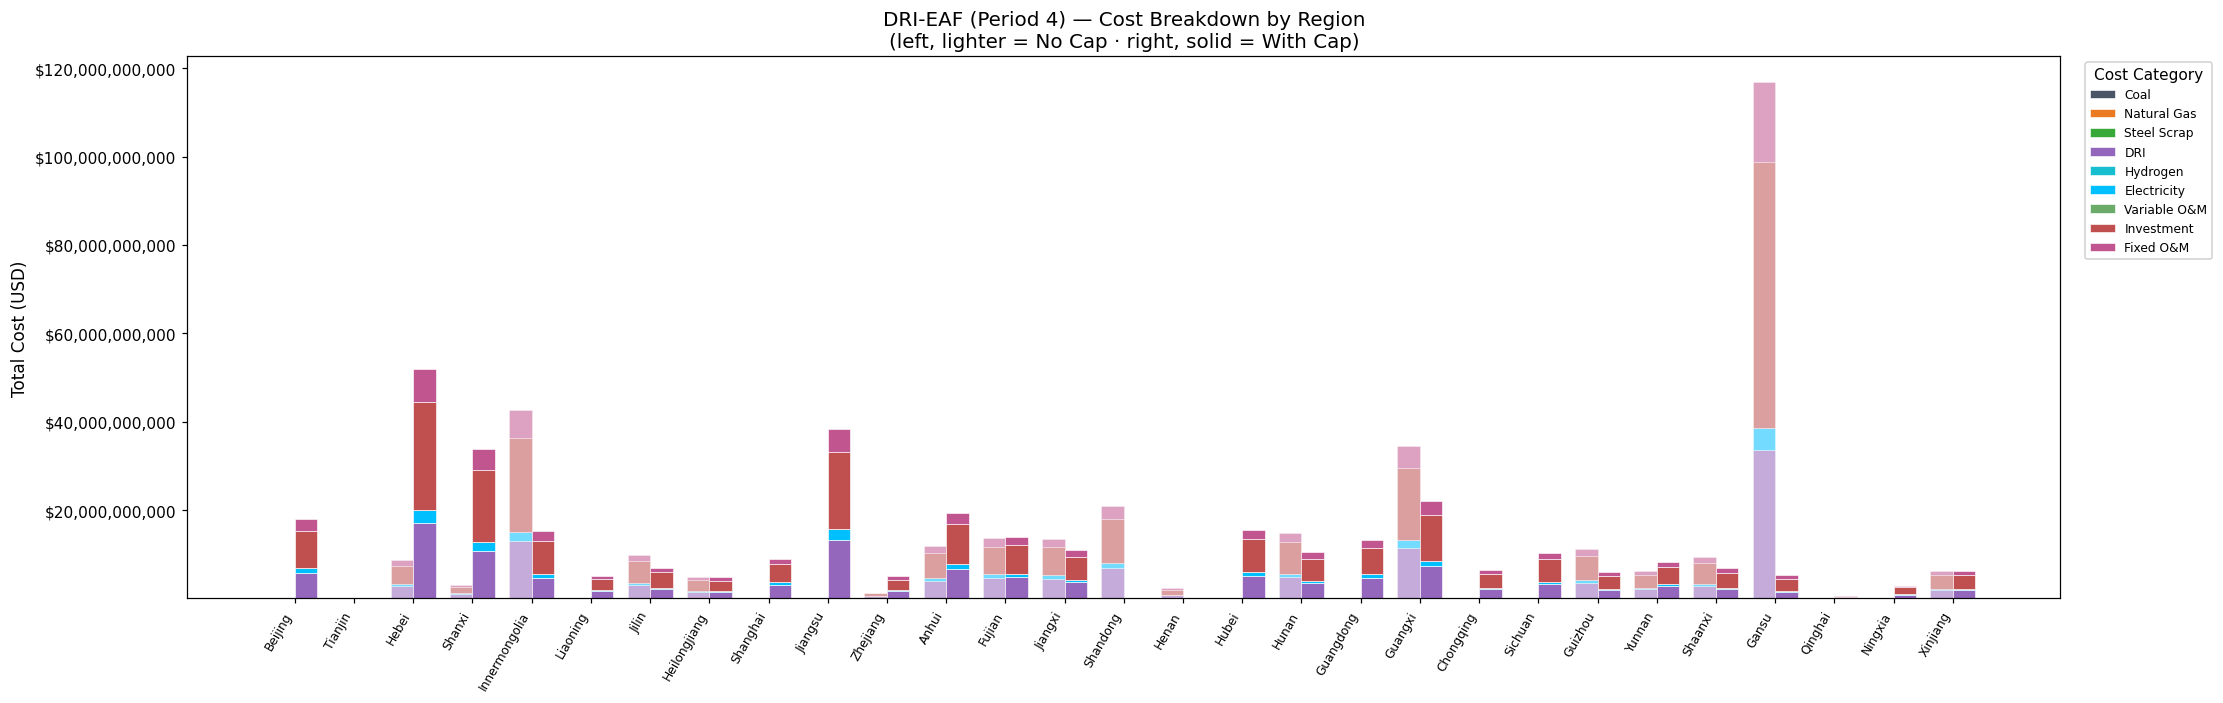

In [17]:
for period in PERIODS:
    plot_cost_stack_comparison(
        all_df, "drieaf", period, value_col="cost_usd",
        title=f"DRI-EAF (Period {period}) — Cost Breakdown by Region",
        ylabel="Total Cost (USD)",
        decimals=0,
    )


## DRI-EAF — per-province cost, no cap vs. with cap ($/ton steel)

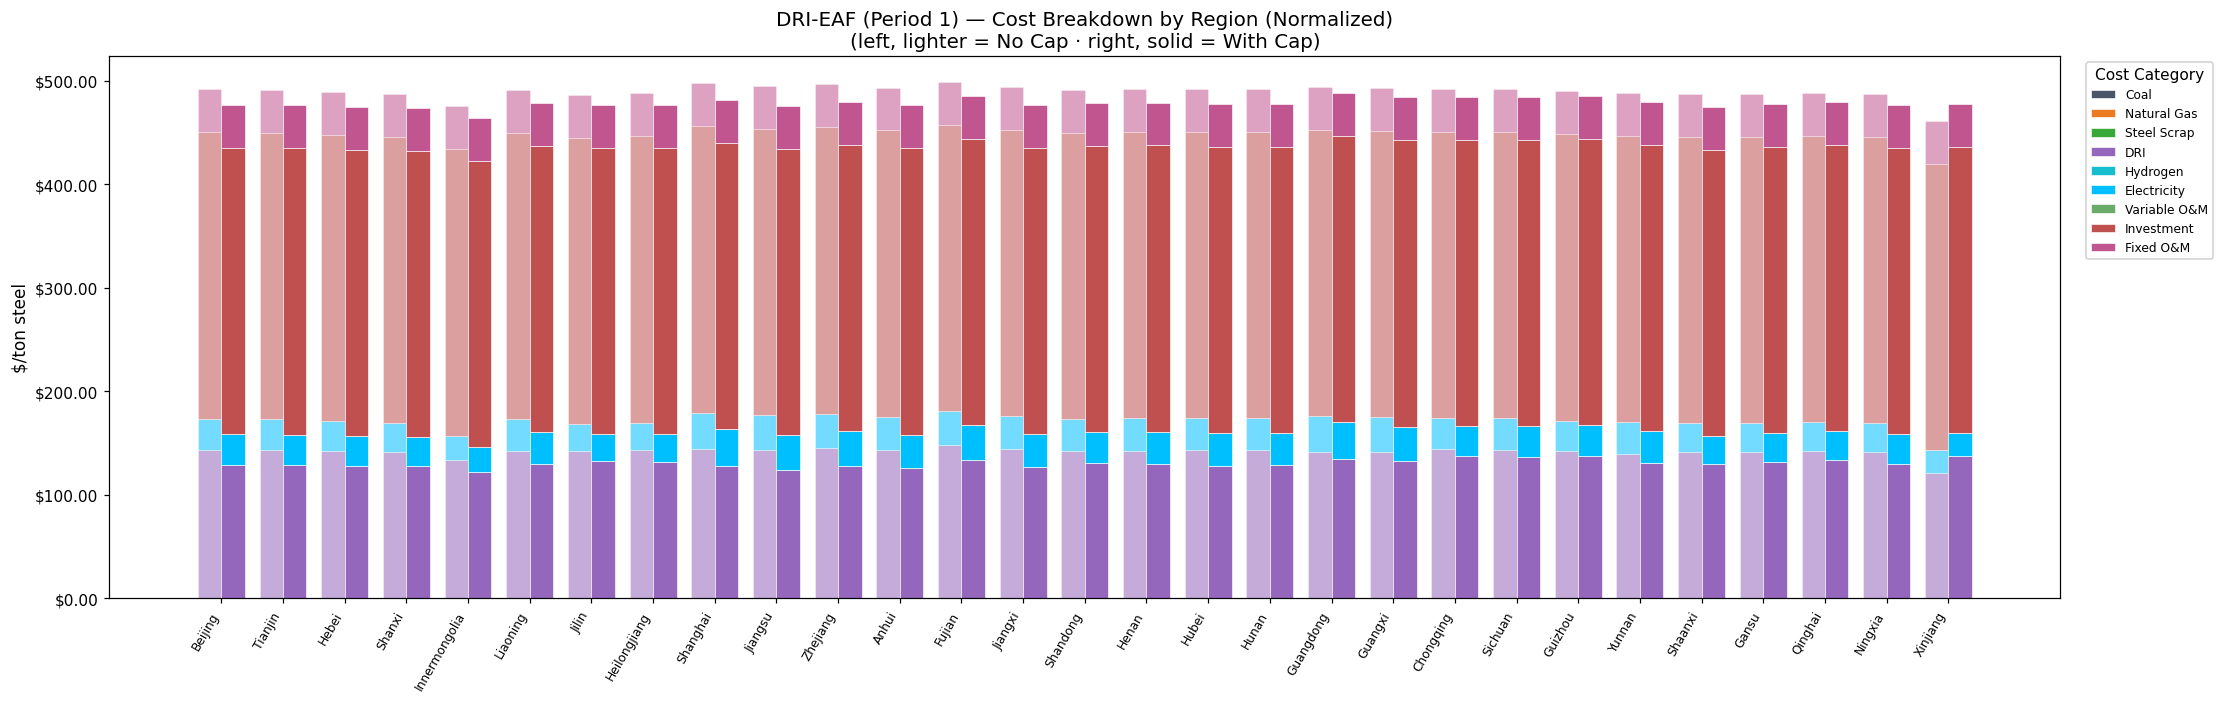

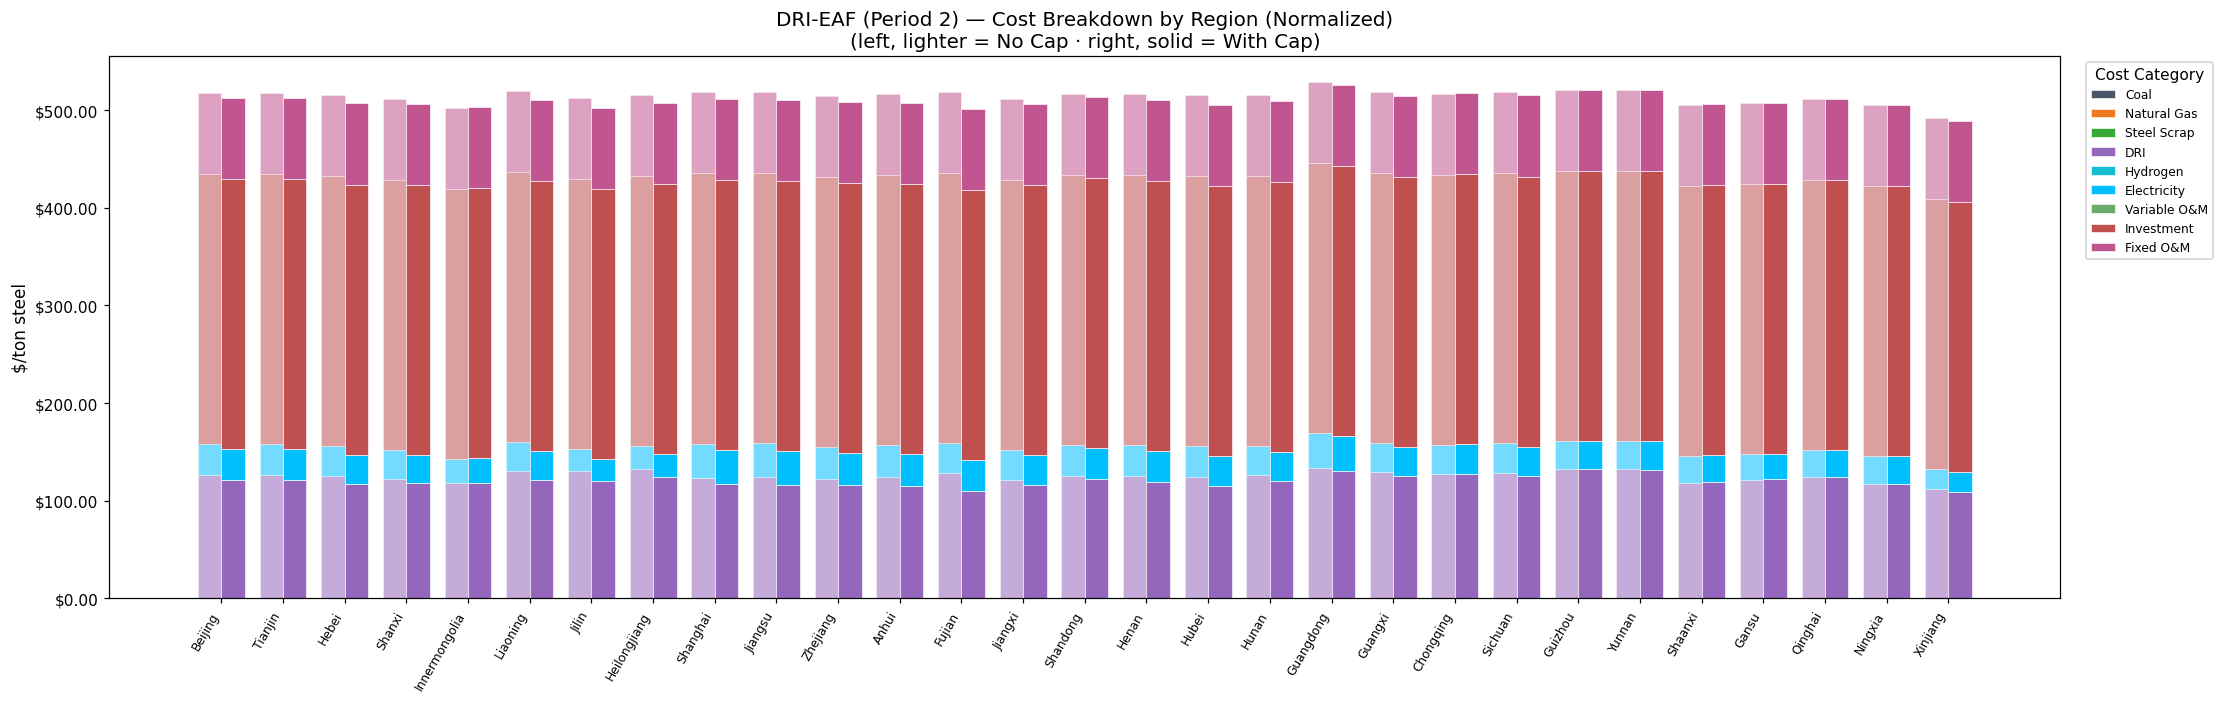

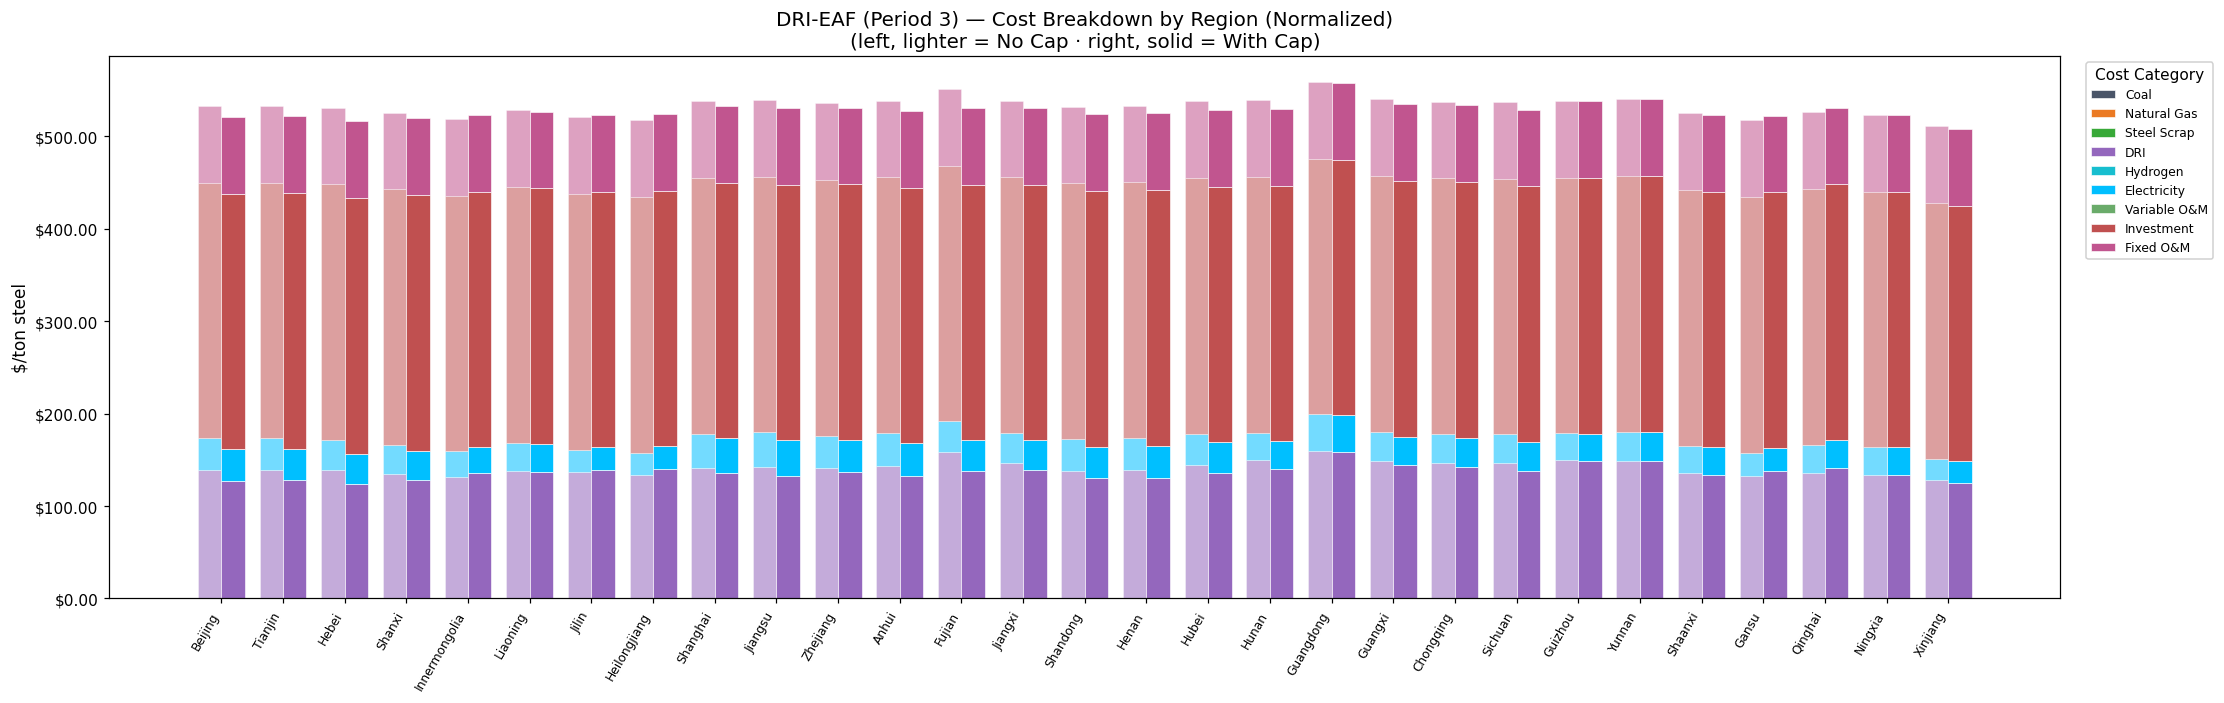

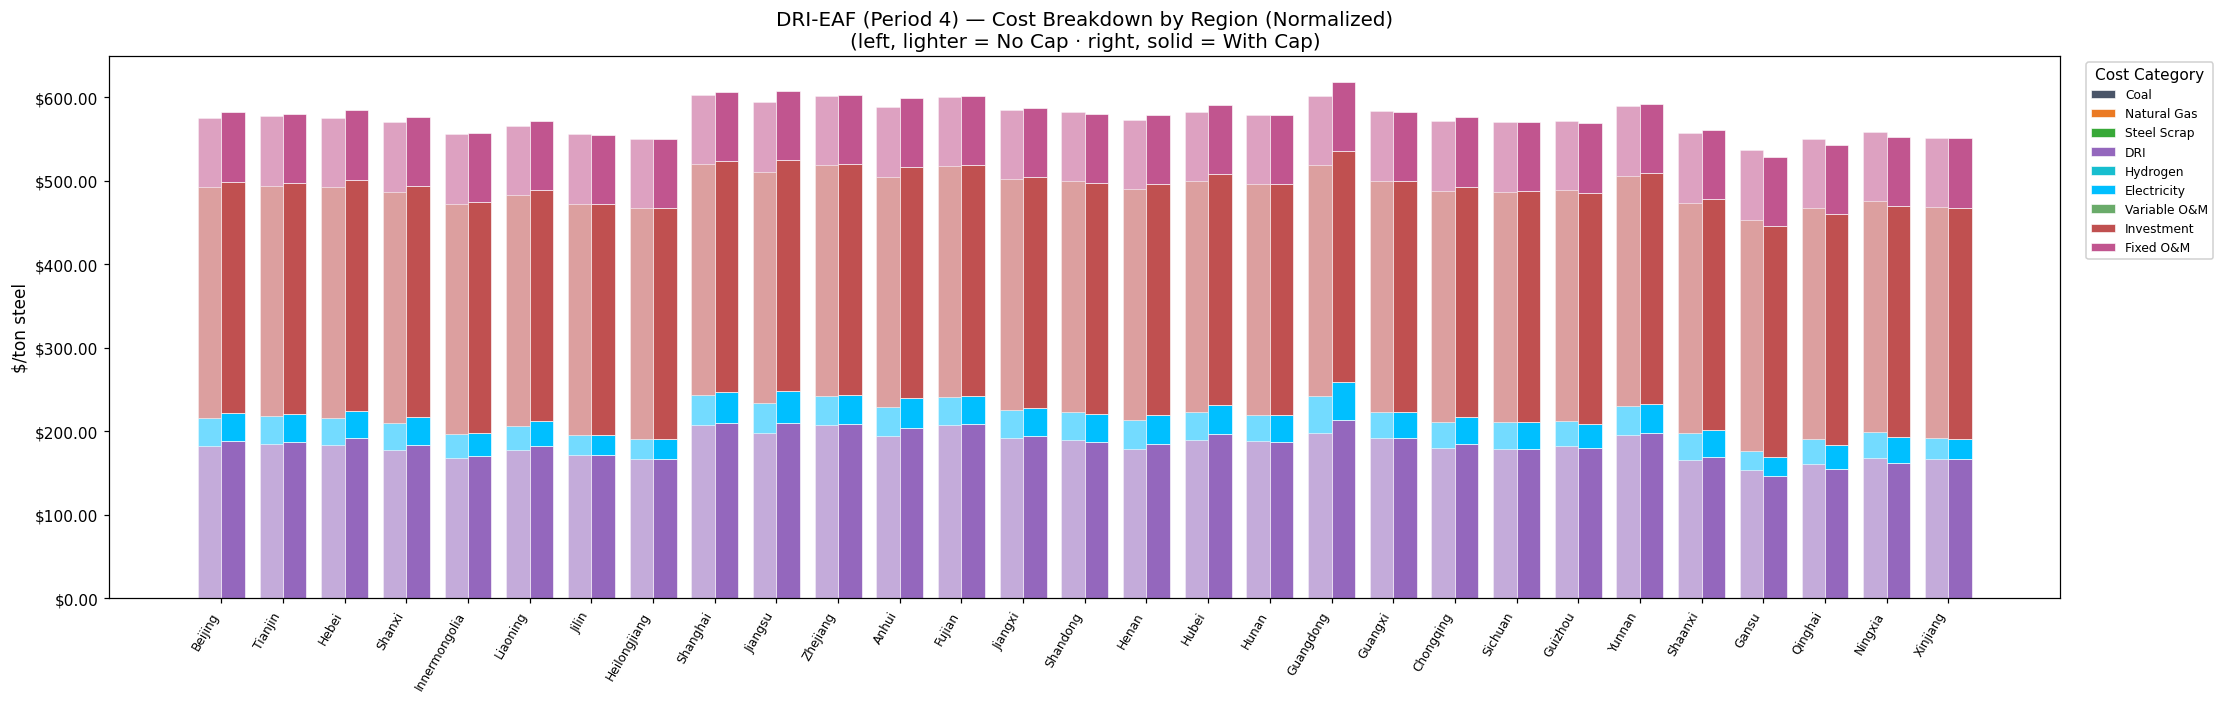

In [18]:
for period in PERIODS:
    plot_cost_stack_comparison(
        all_df, "drieaf", period, value_col="cost_per_ton",
        title=f"DRI-EAF (Period {period}) — Cost Breakdown by Region (Normalized)",
        ylabel="$/ton steel",
        decimals=2,
    )


## DRI-EAF — national total, unnormalized (all provinces summed)

Raw $ cost, summed across all provinces (not divided by production), by
period and scenario.


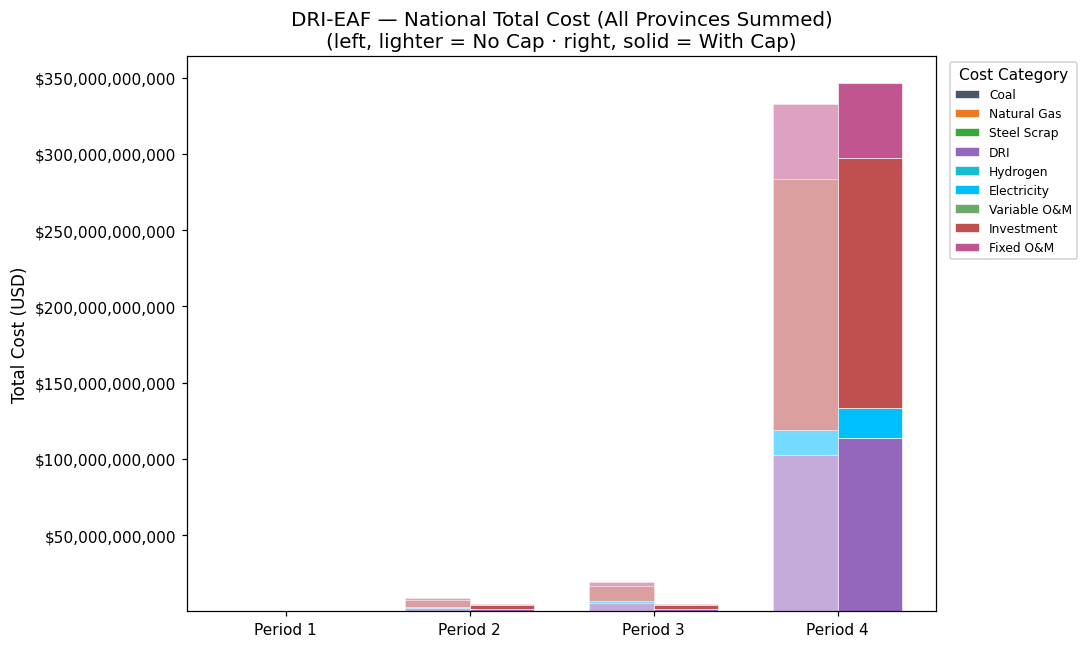

In [19]:
plot_national_total_comparison(
    all_df, "drieaf",
    title="DRI-EAF — National Total Cost (All Provinces Summed)",
)


---
# Scrap EAF 56%


## Scrap EAF 56% — per-province cost, no cap vs. with cap (USD)

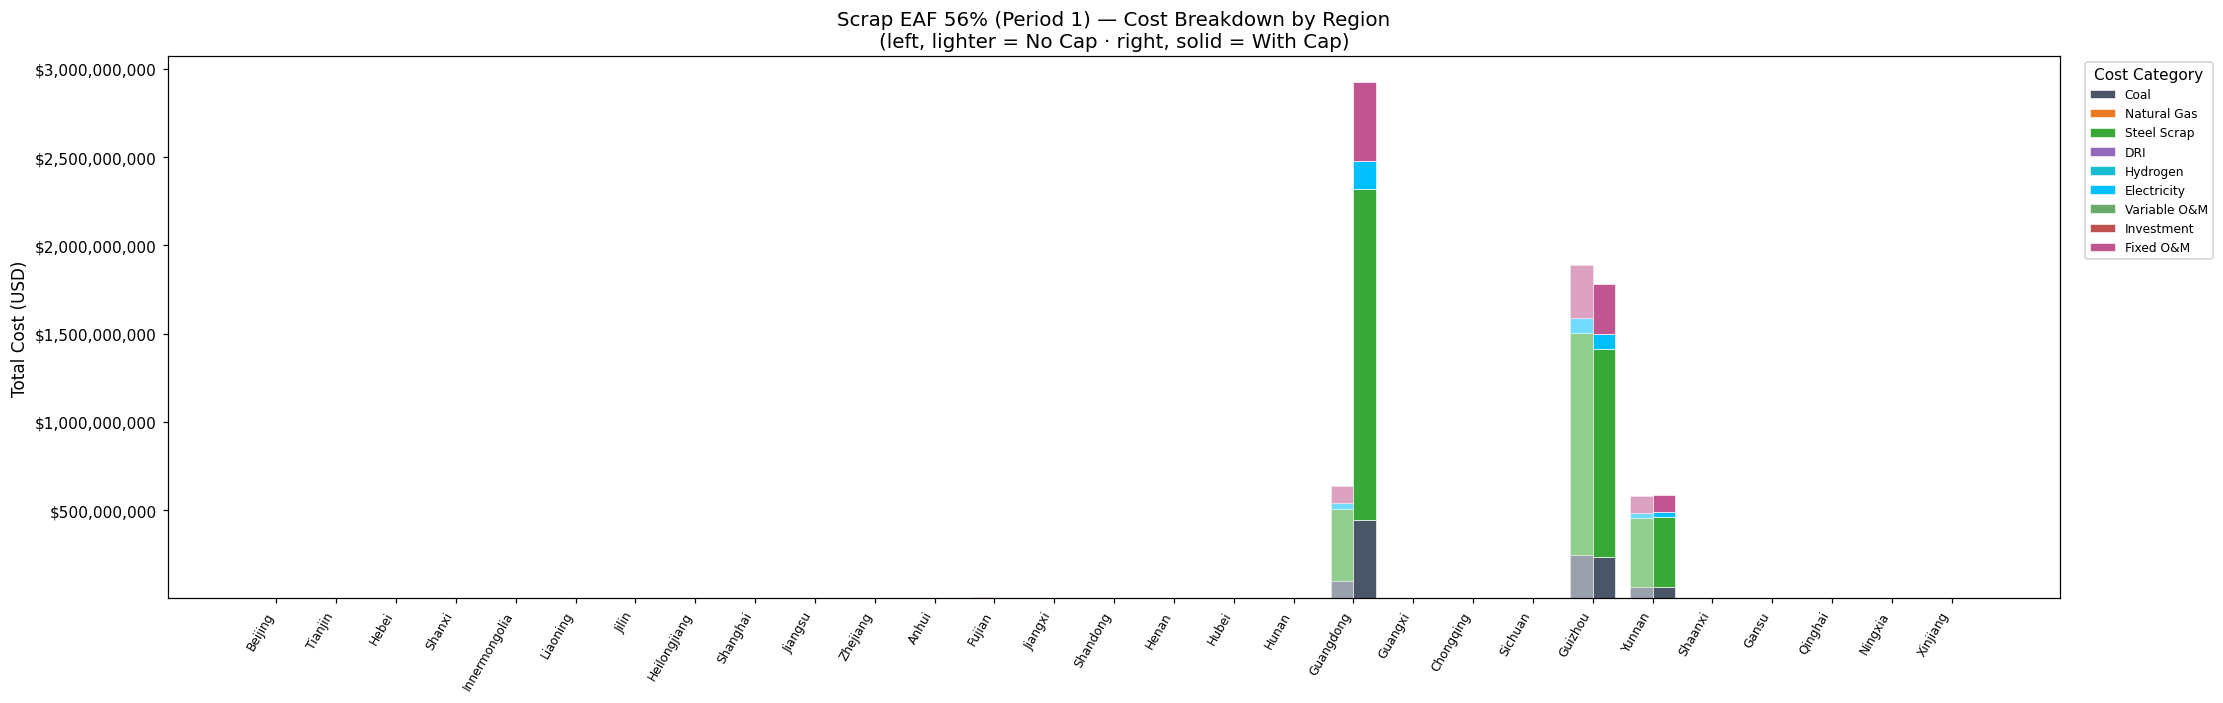

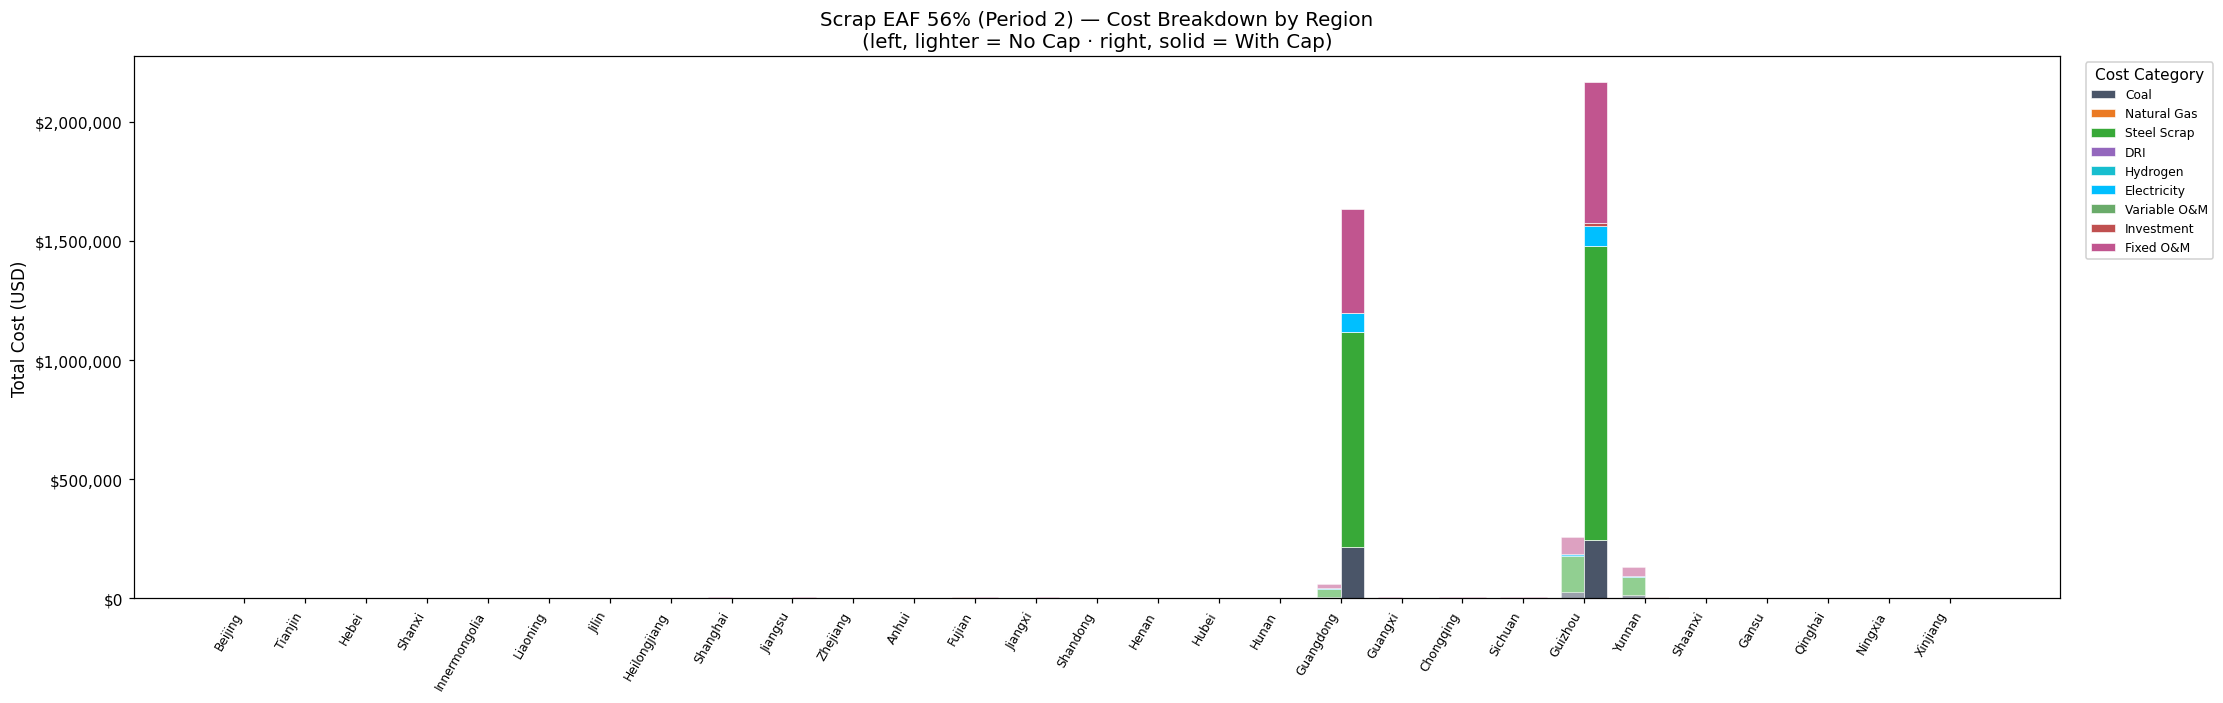

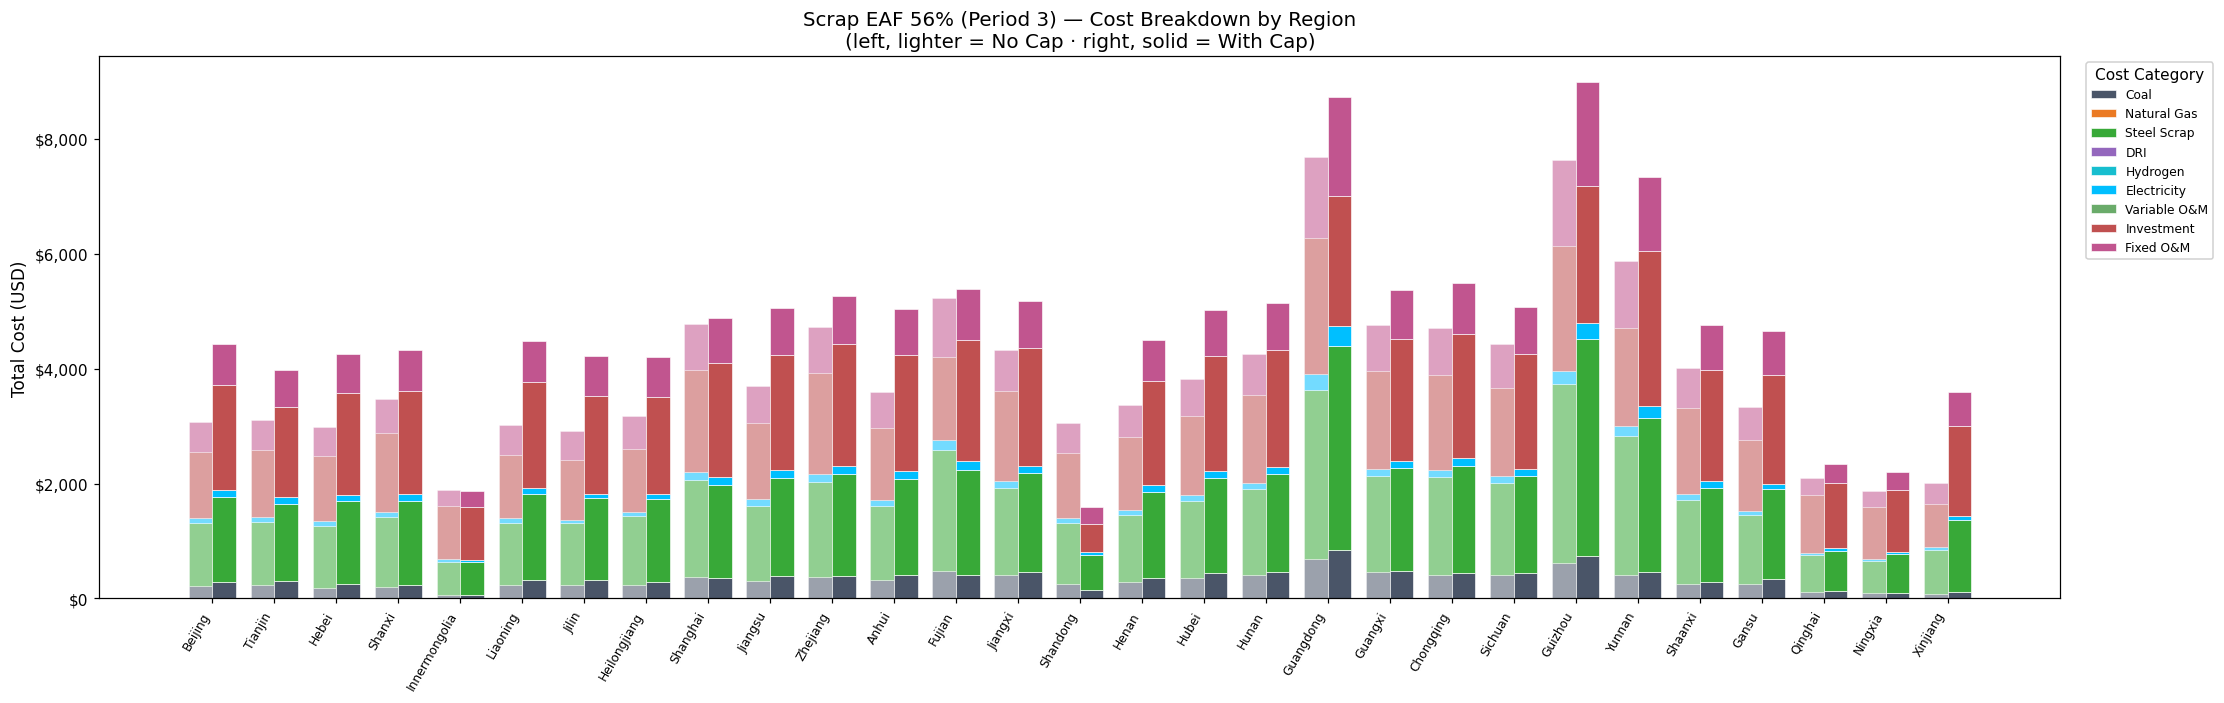

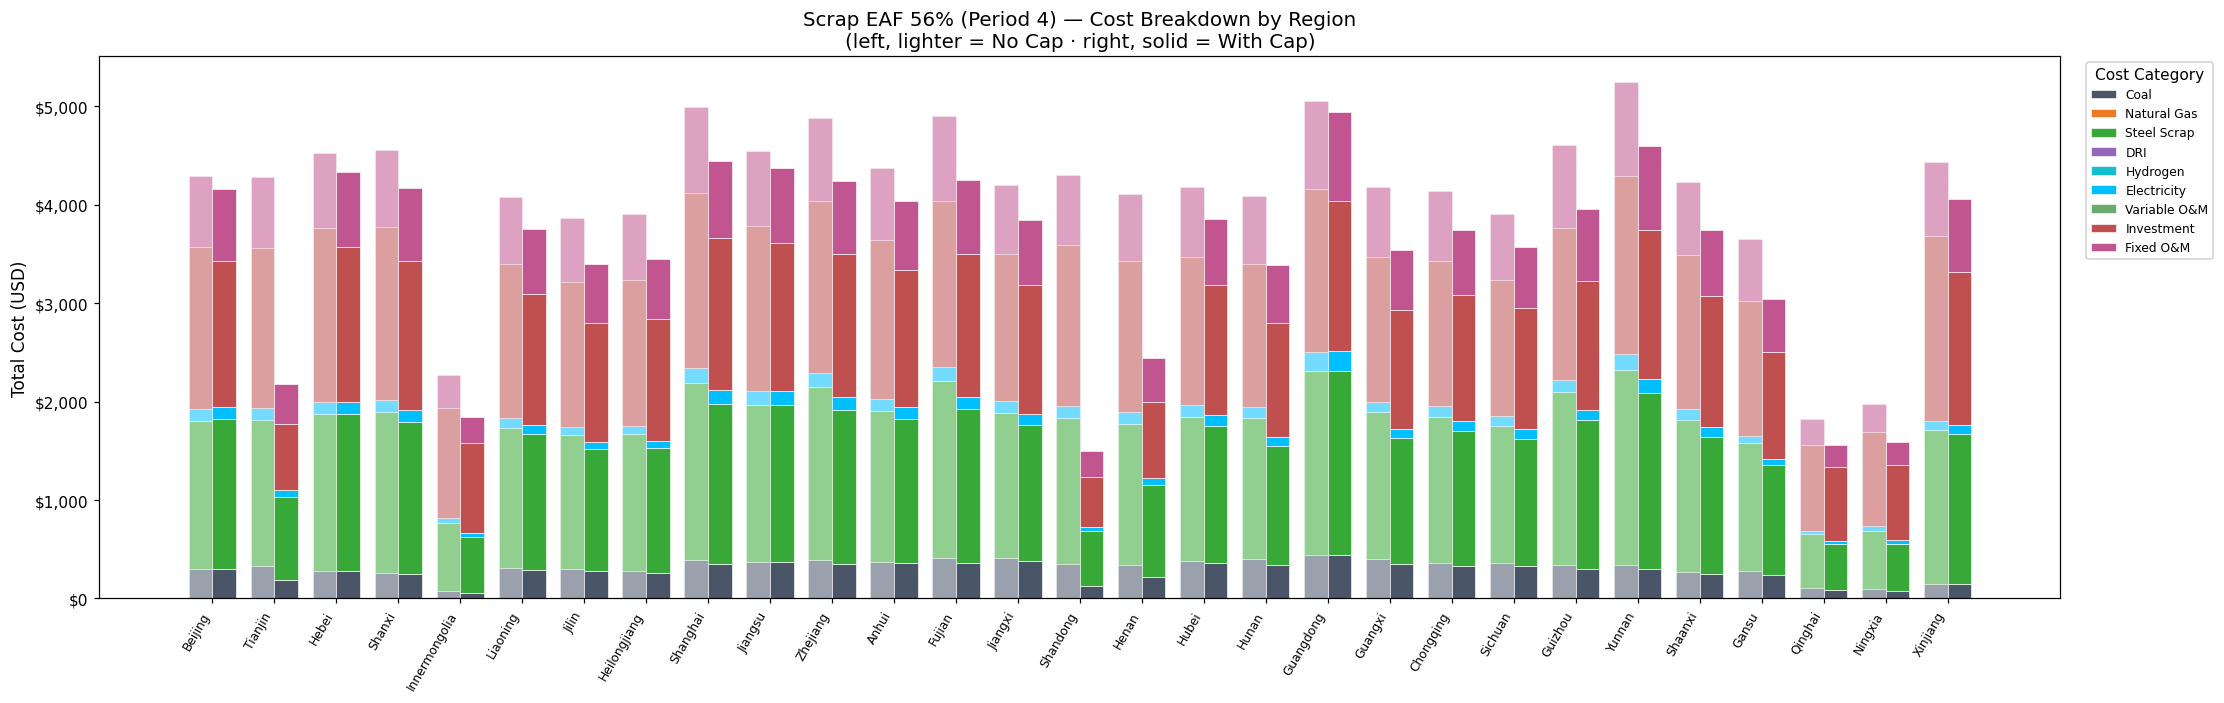

In [20]:
for period in PERIODS:
    plot_cost_stack_comparison(
        all_df, "scrapeaf56", period, value_col="cost_usd",
        title=f"Scrap EAF 56% (Period {period}) — Cost Breakdown by Region",
        ylabel="Total Cost (USD)",
        decimals=0,
    )


## Scrap EAF 56% — per-province cost, no cap vs. with cap ($/ton steel)

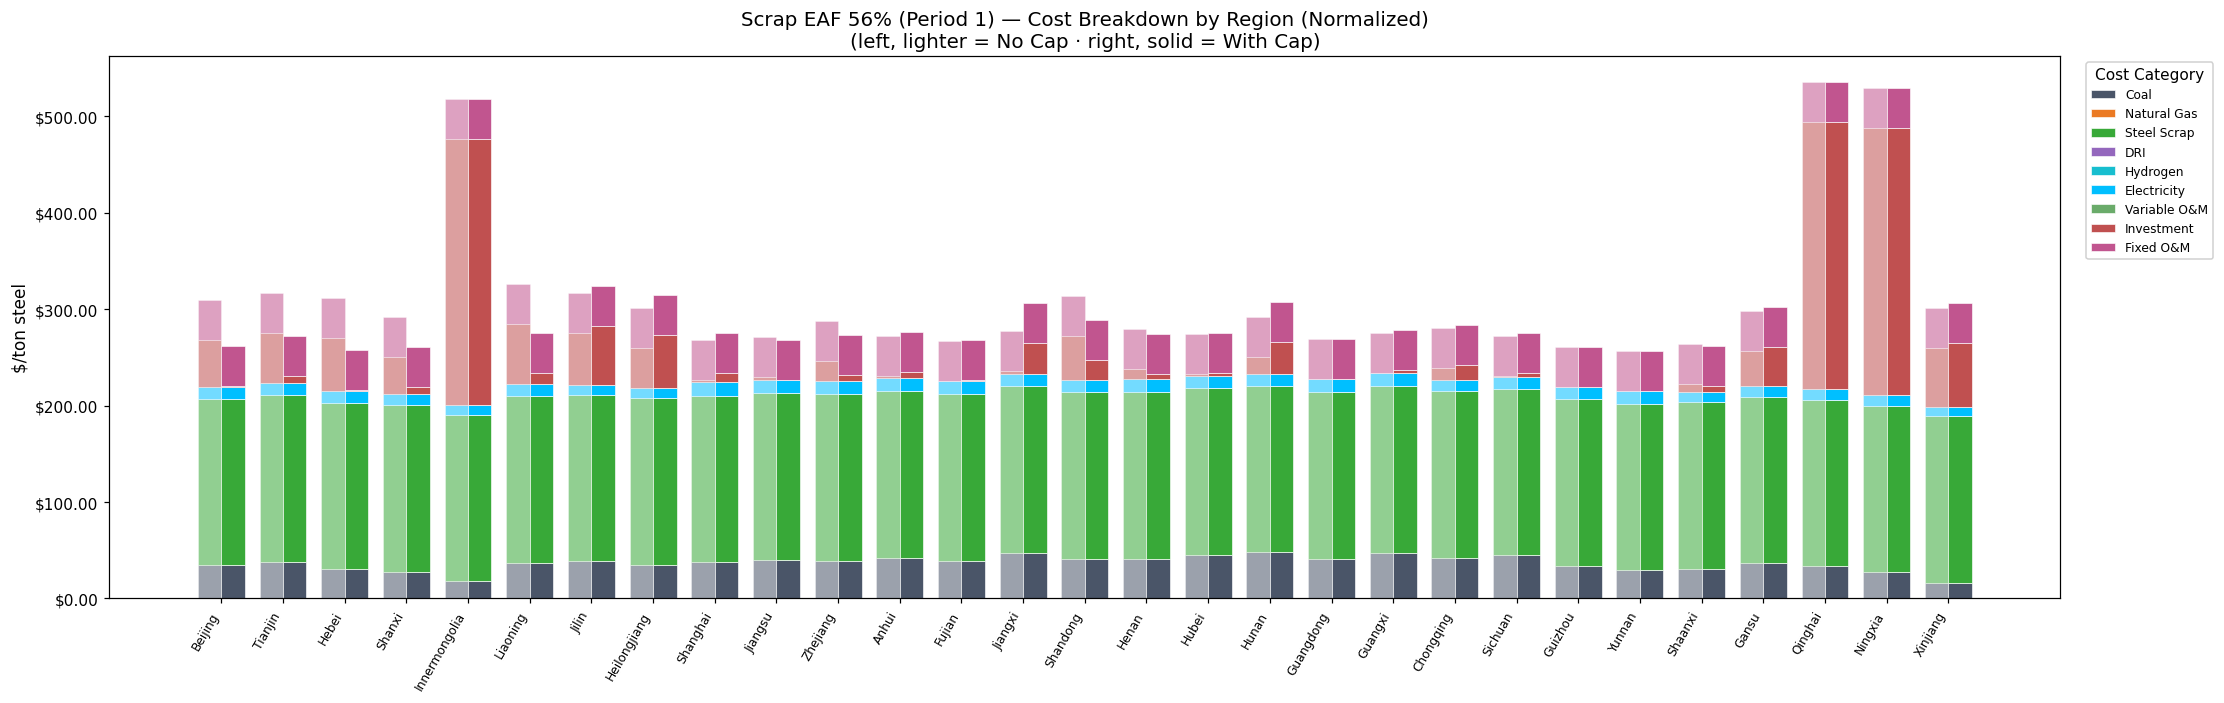

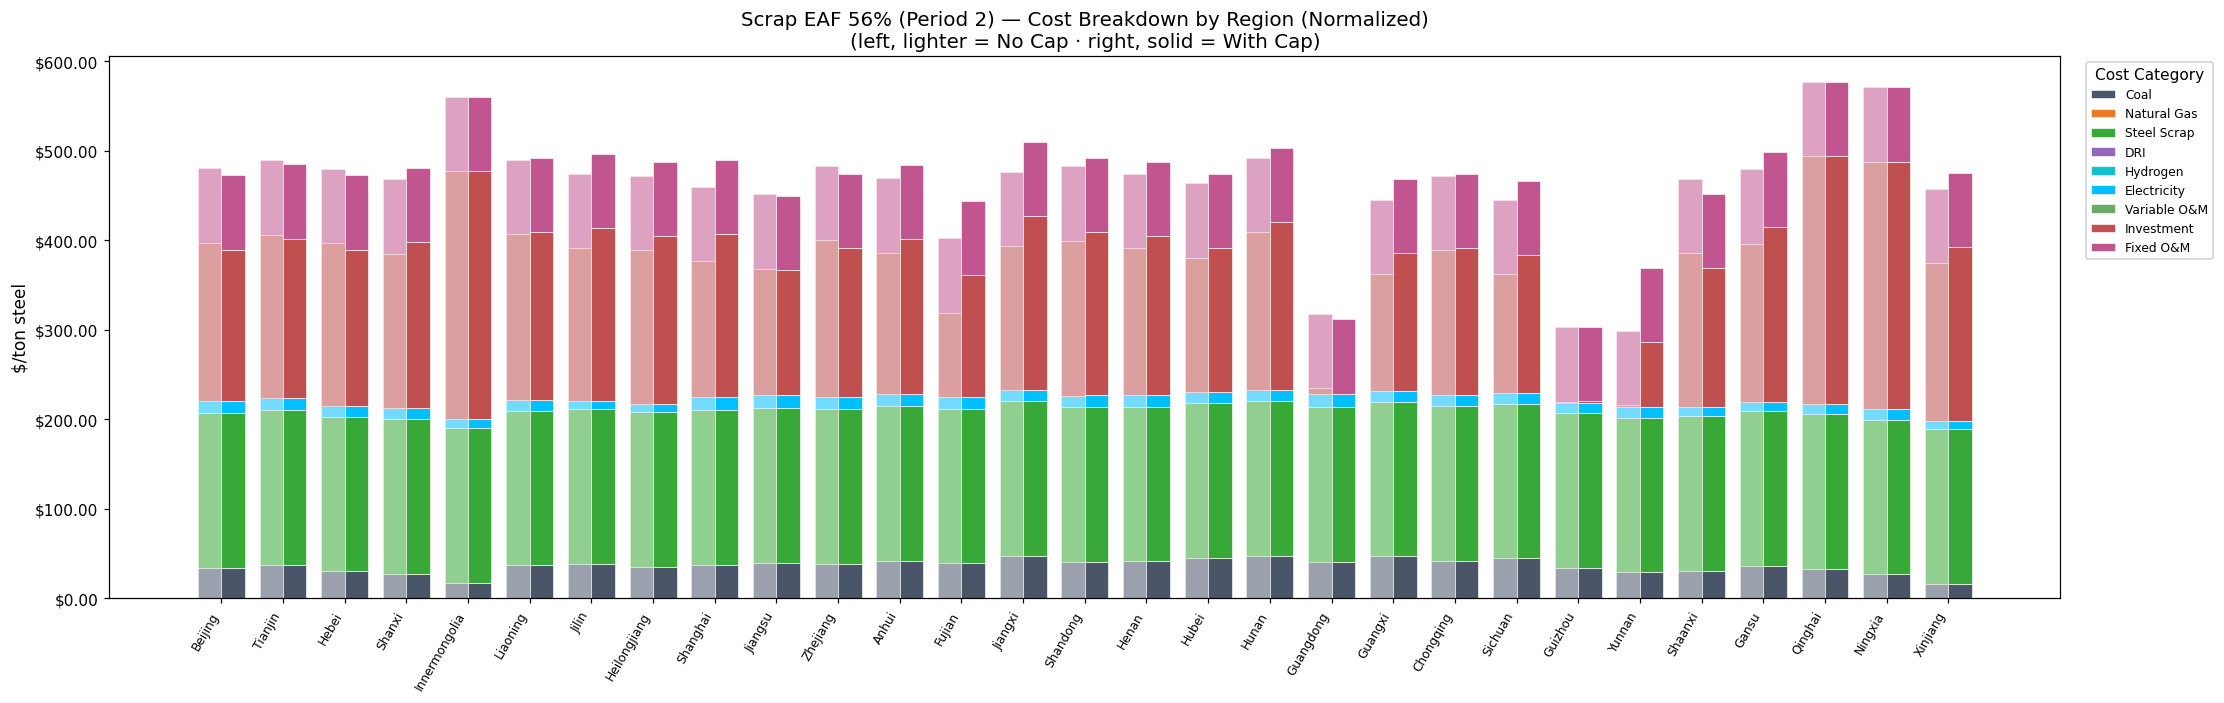

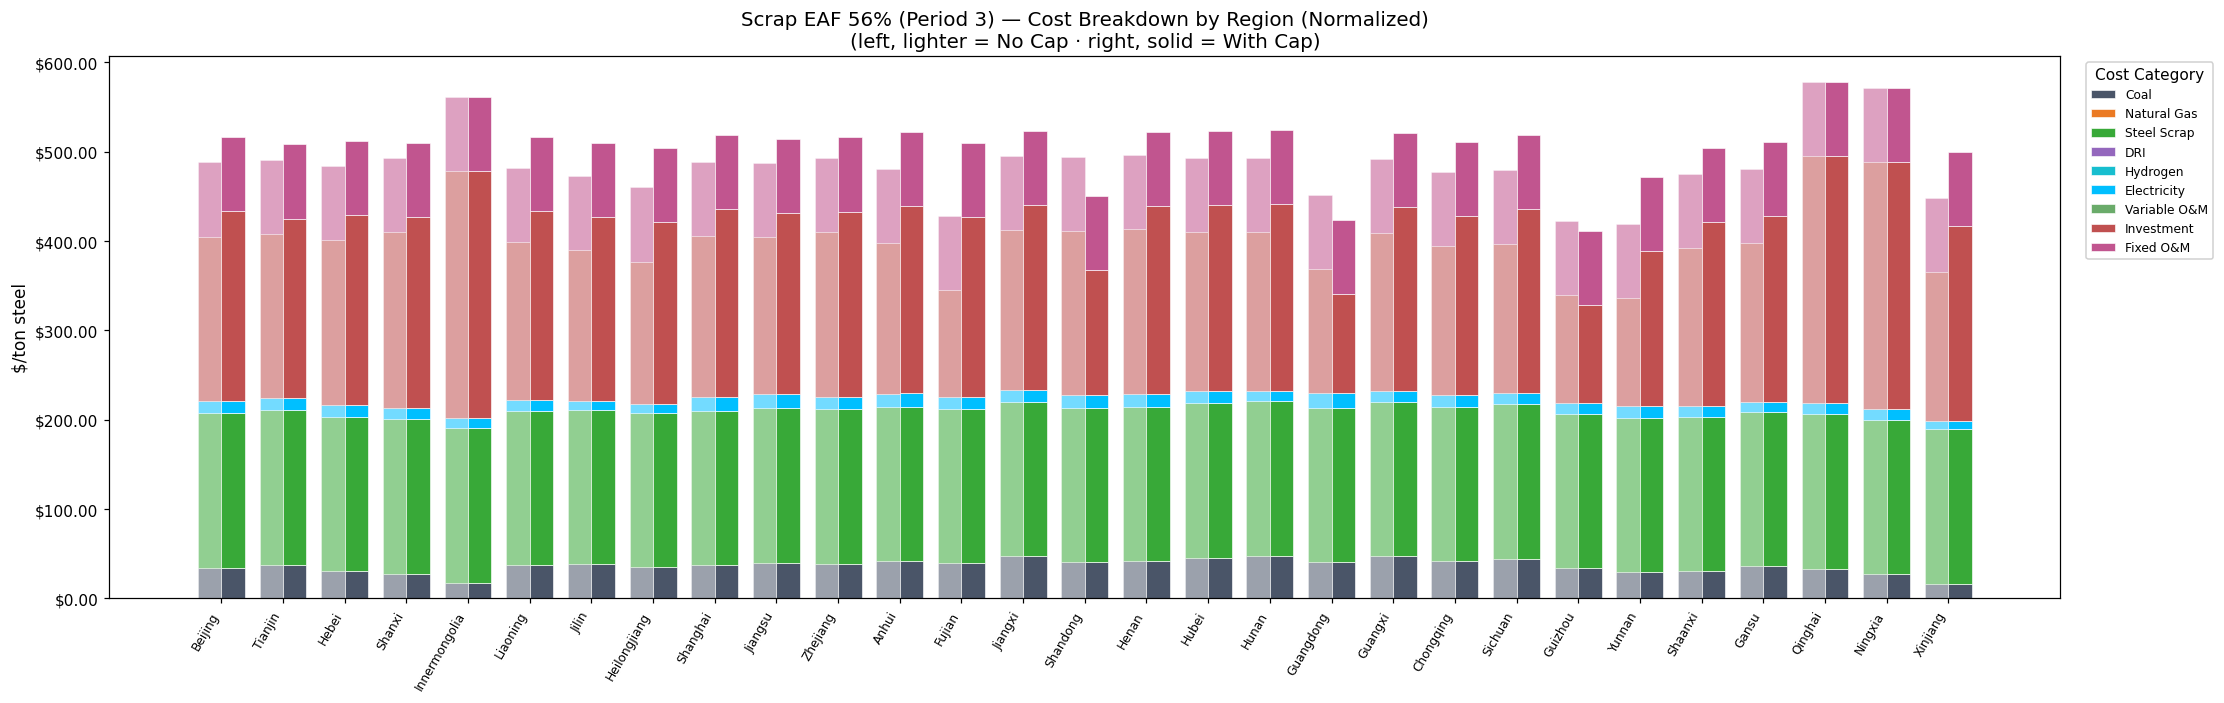

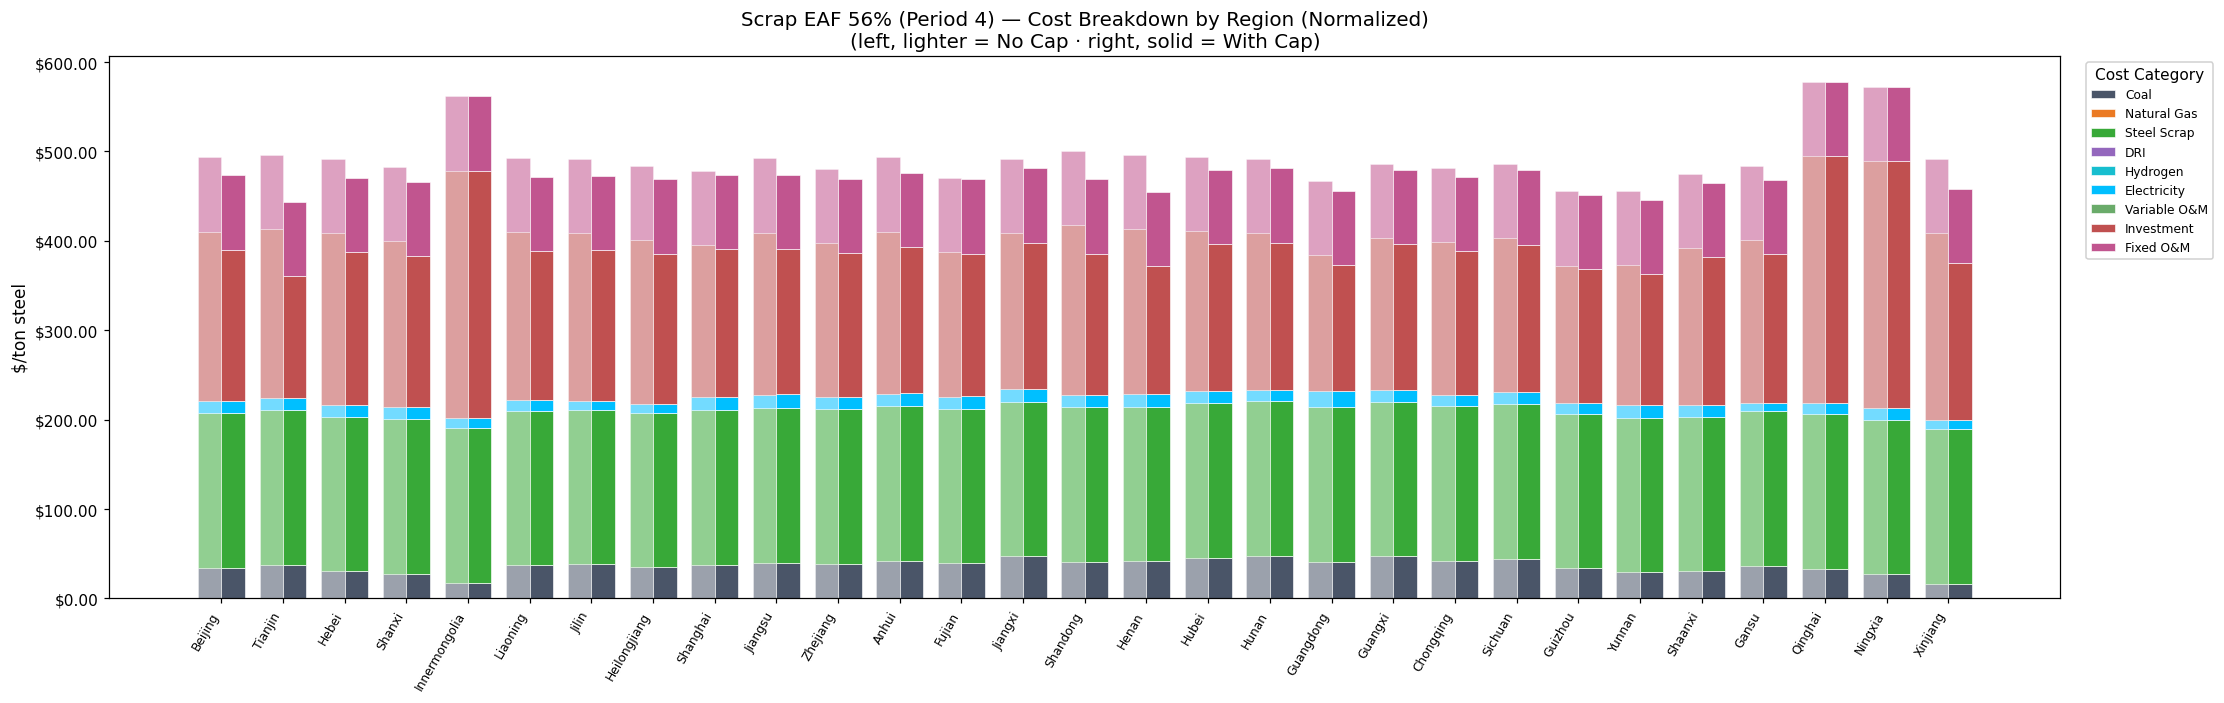

In [21]:
for period in PERIODS:
    plot_cost_stack_comparison(
        all_df, "scrapeaf56", period, value_col="cost_per_ton",
        title=f"Scrap EAF 56% (Period {period}) — Cost Breakdown by Region (Normalized)",
        ylabel="$/ton steel",
        decimals=2,
    )


## Scrap EAF 56% — national total, unnormalized (all provinces summed)

Raw $ cost, summed across all provinces (not divided by production), by
period and scenario.


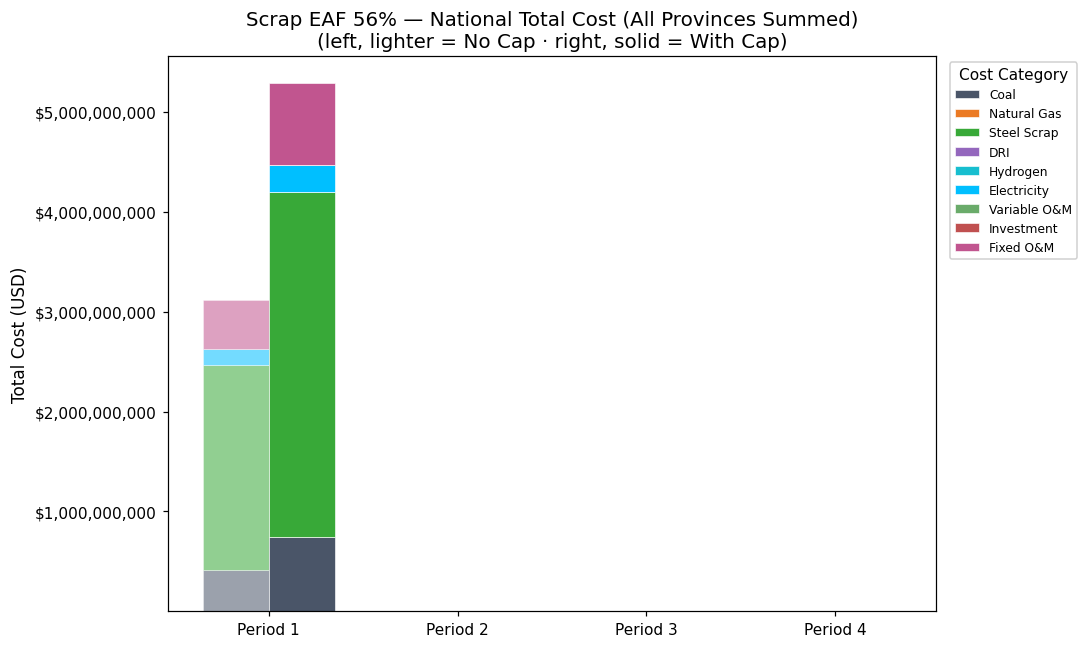

In [22]:
plot_national_total_comparison(
    all_df, "scrapeaf56",
    title="Scrap EAF 56% — National Total Cost (All Provinces Summed)",
)


---
# Scrap EAF 100%


## Scrap EAF 100% — per-province cost, no cap vs. with cap (USD)

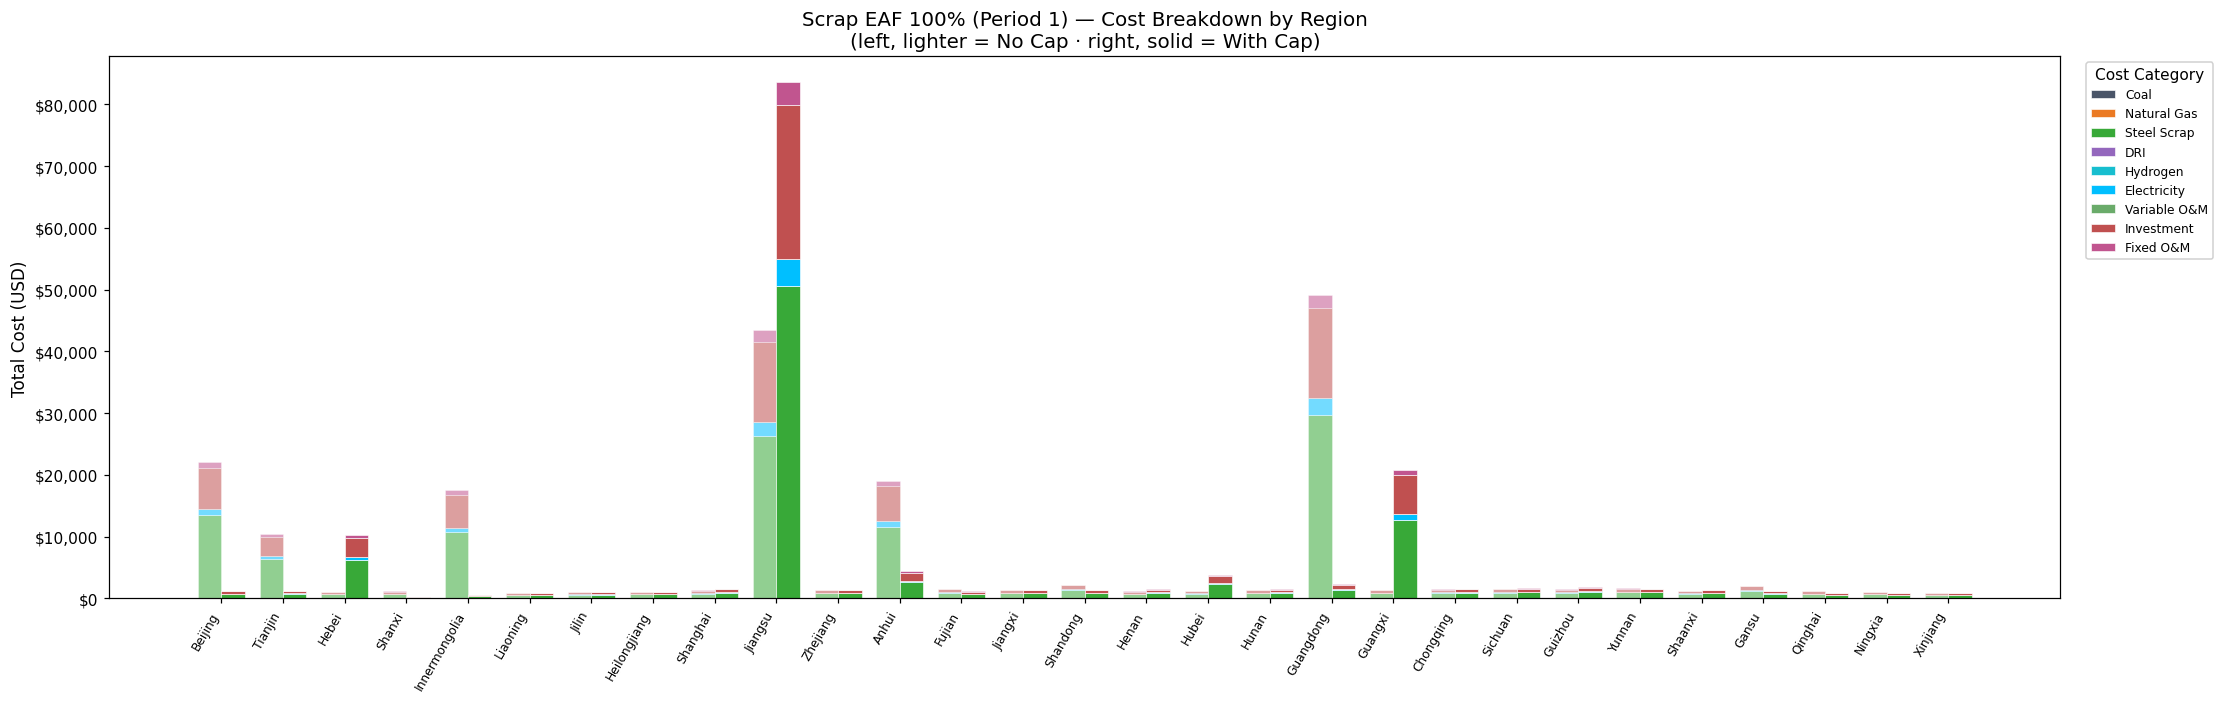

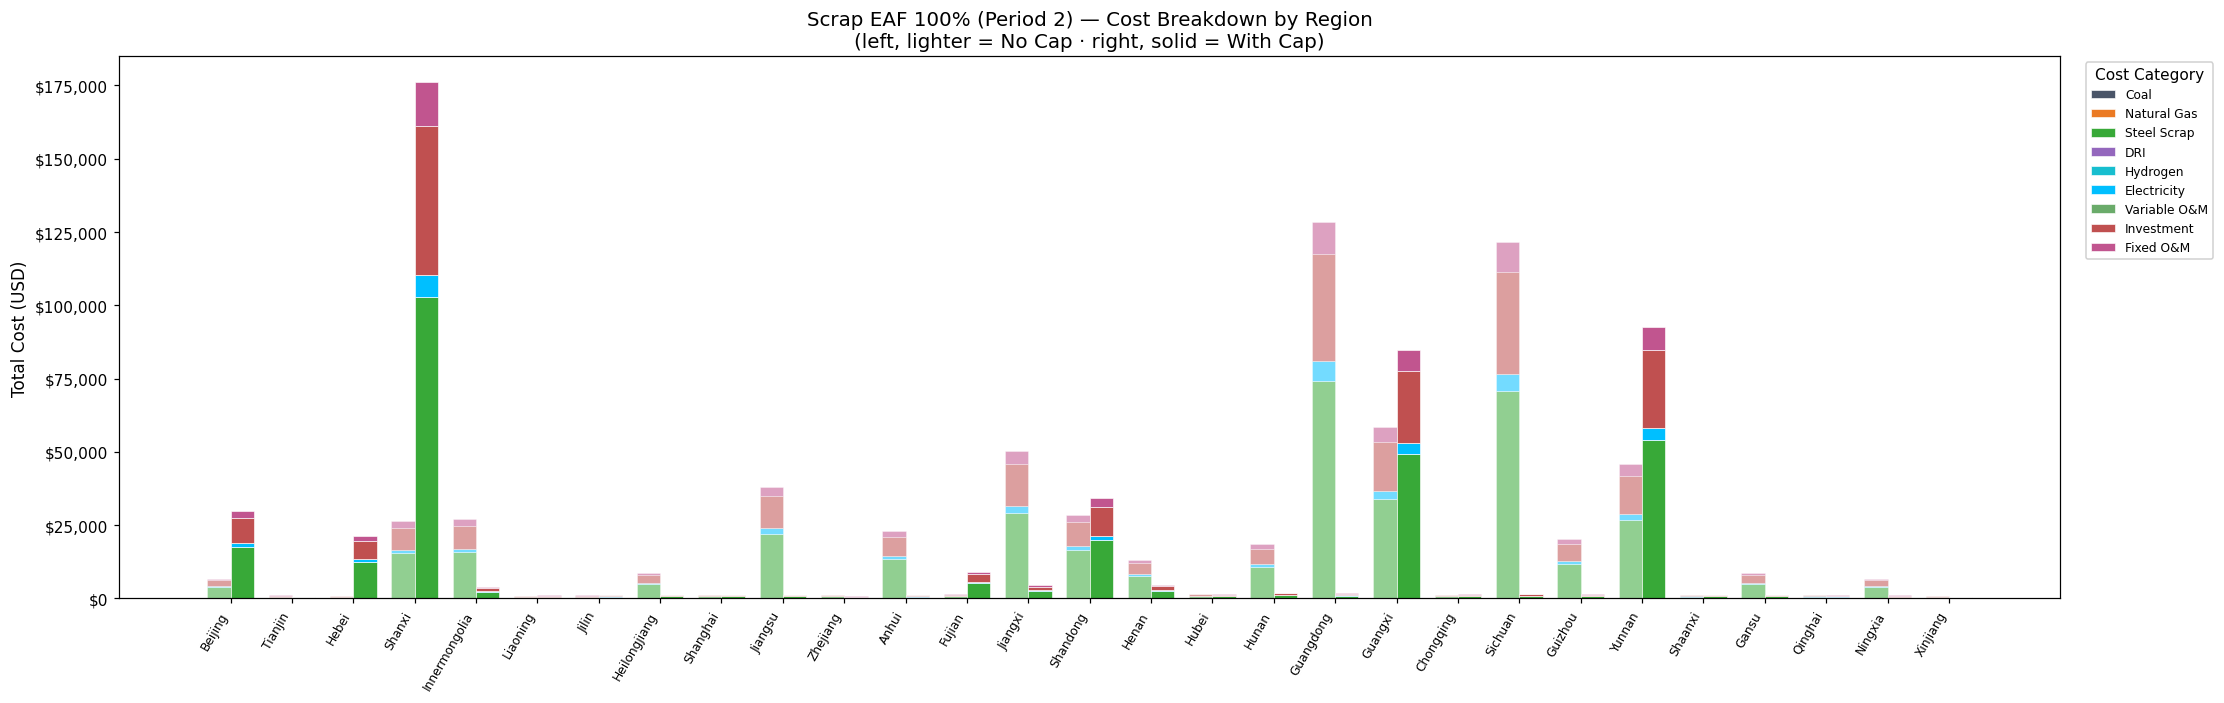

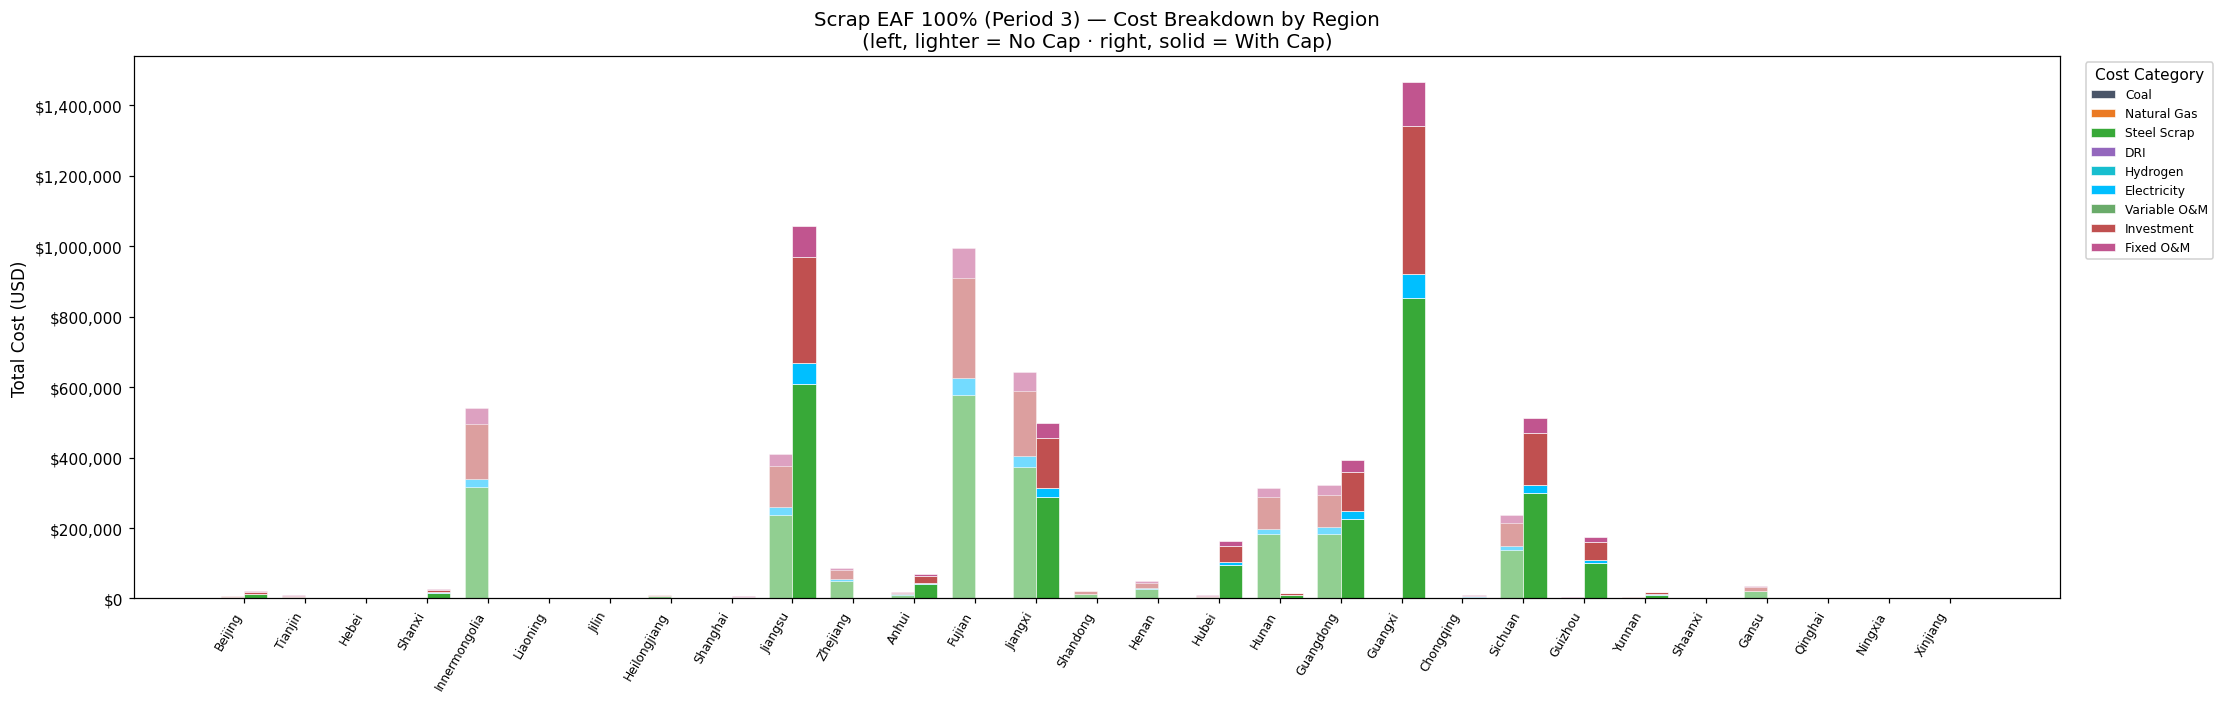

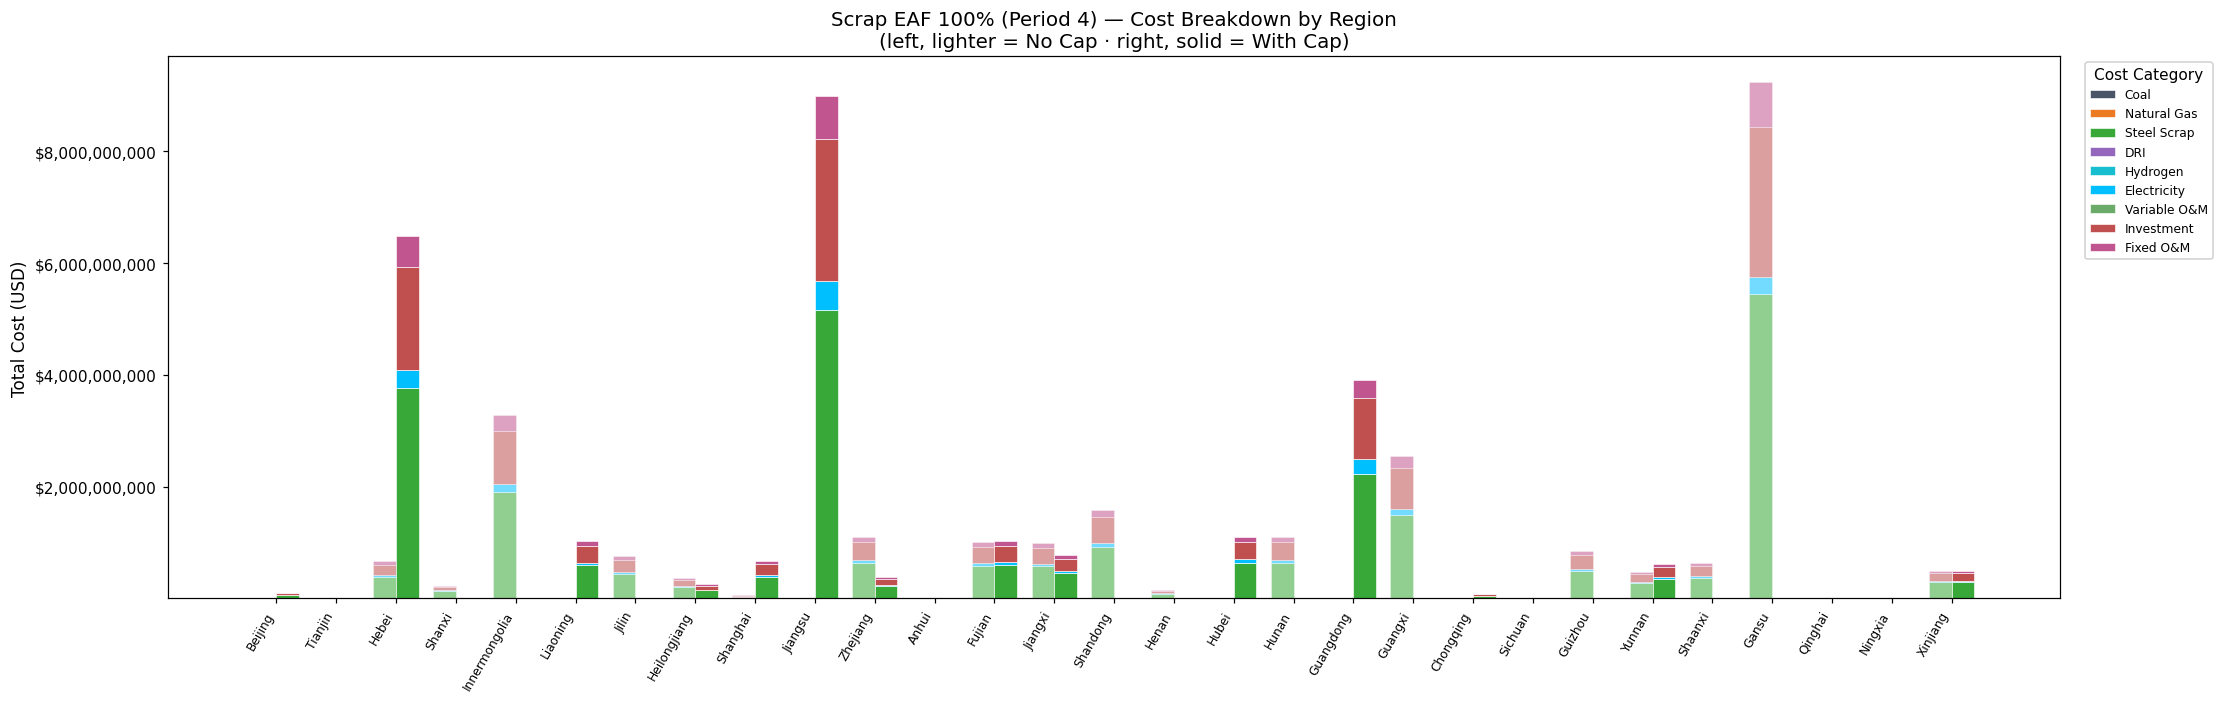

In [23]:
for period in PERIODS:
    plot_cost_stack_comparison(
        all_df, "scrapeaf100", period, value_col="cost_usd",
        title=f"Scrap EAF 100% (Period {period}) — Cost Breakdown by Region",
        ylabel="Total Cost (USD)",
        decimals=0,
    )


## Scrap EAF 100% — per-province cost, no cap vs. with cap ($/ton steel)

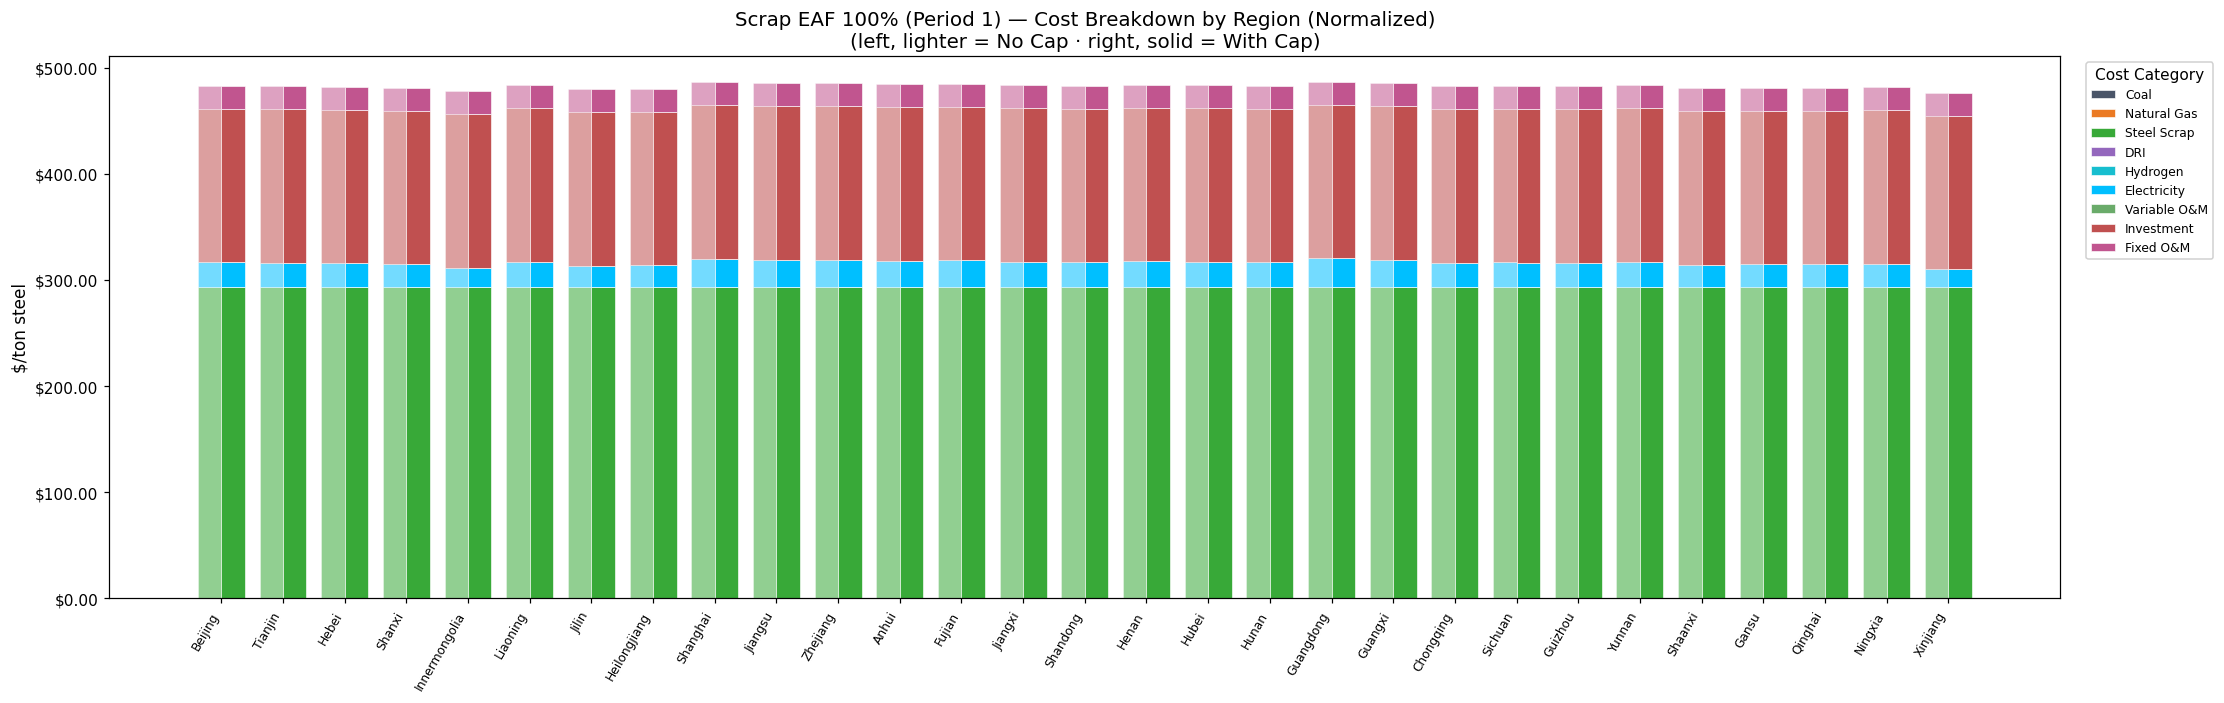

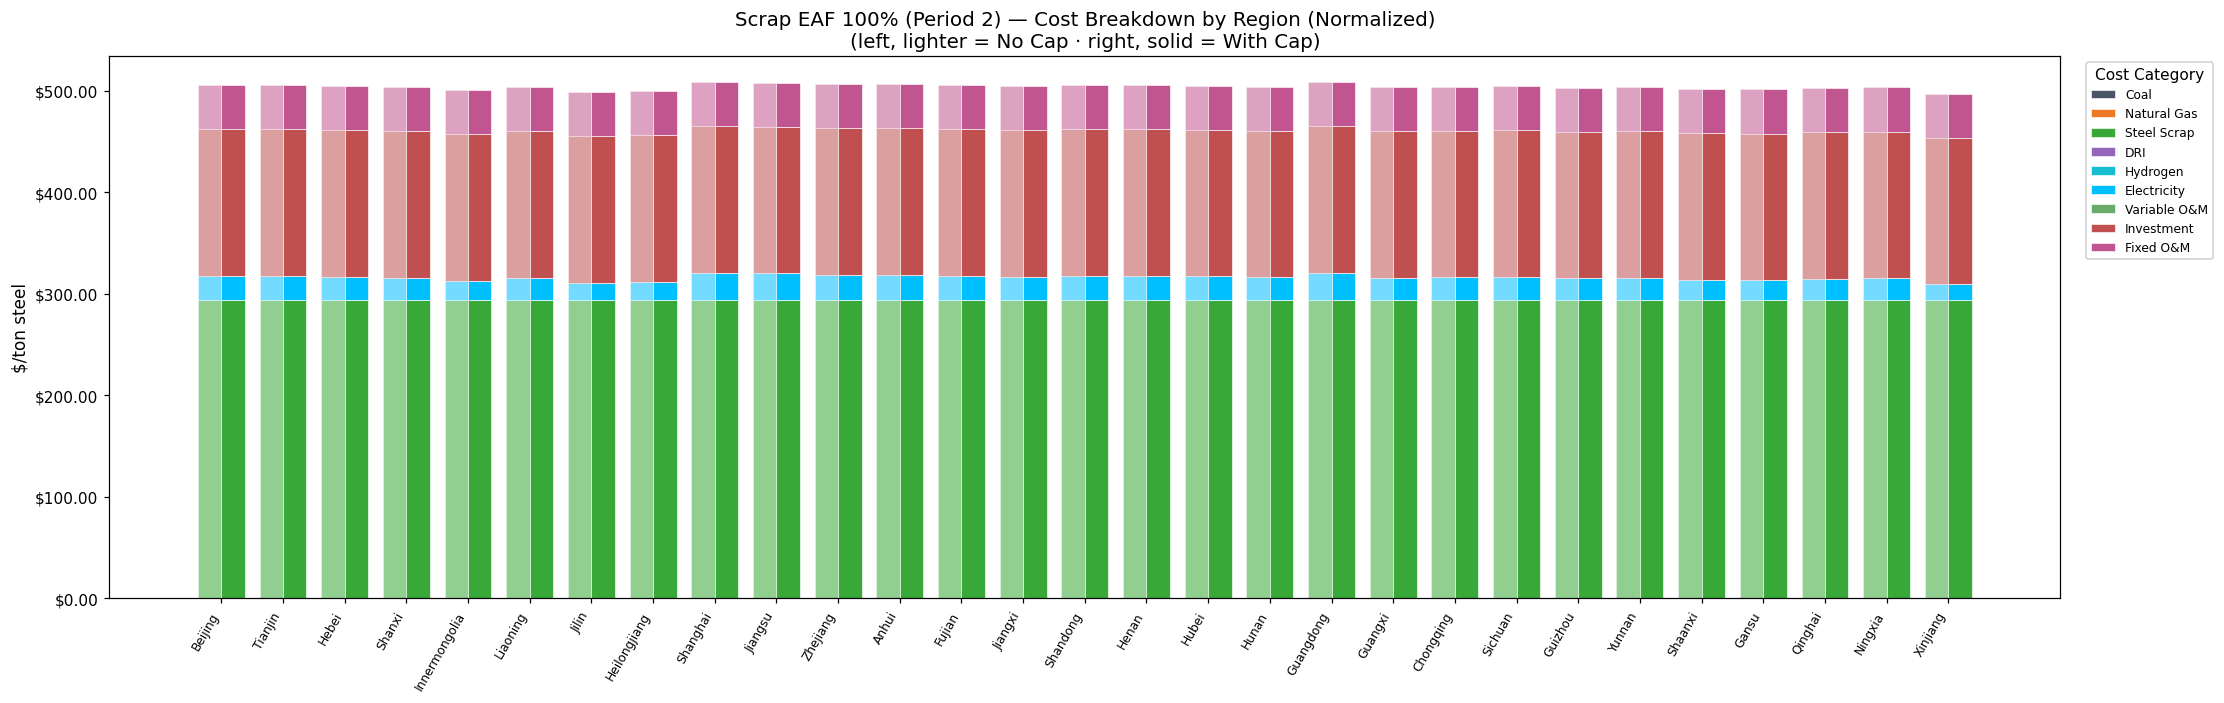

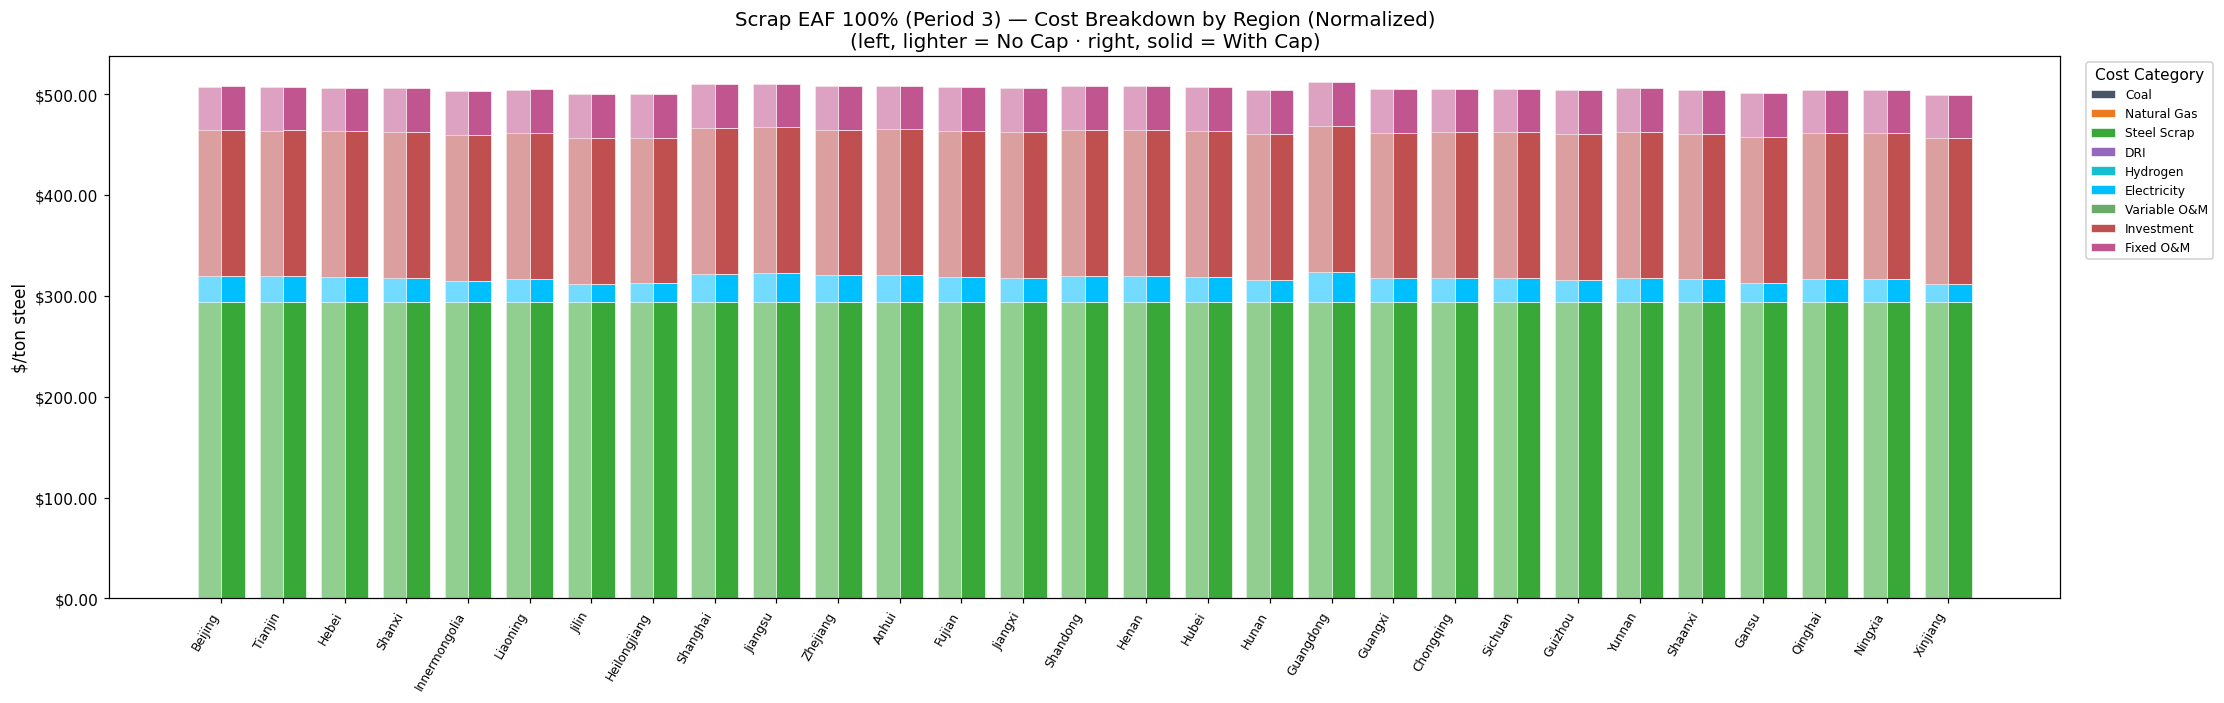

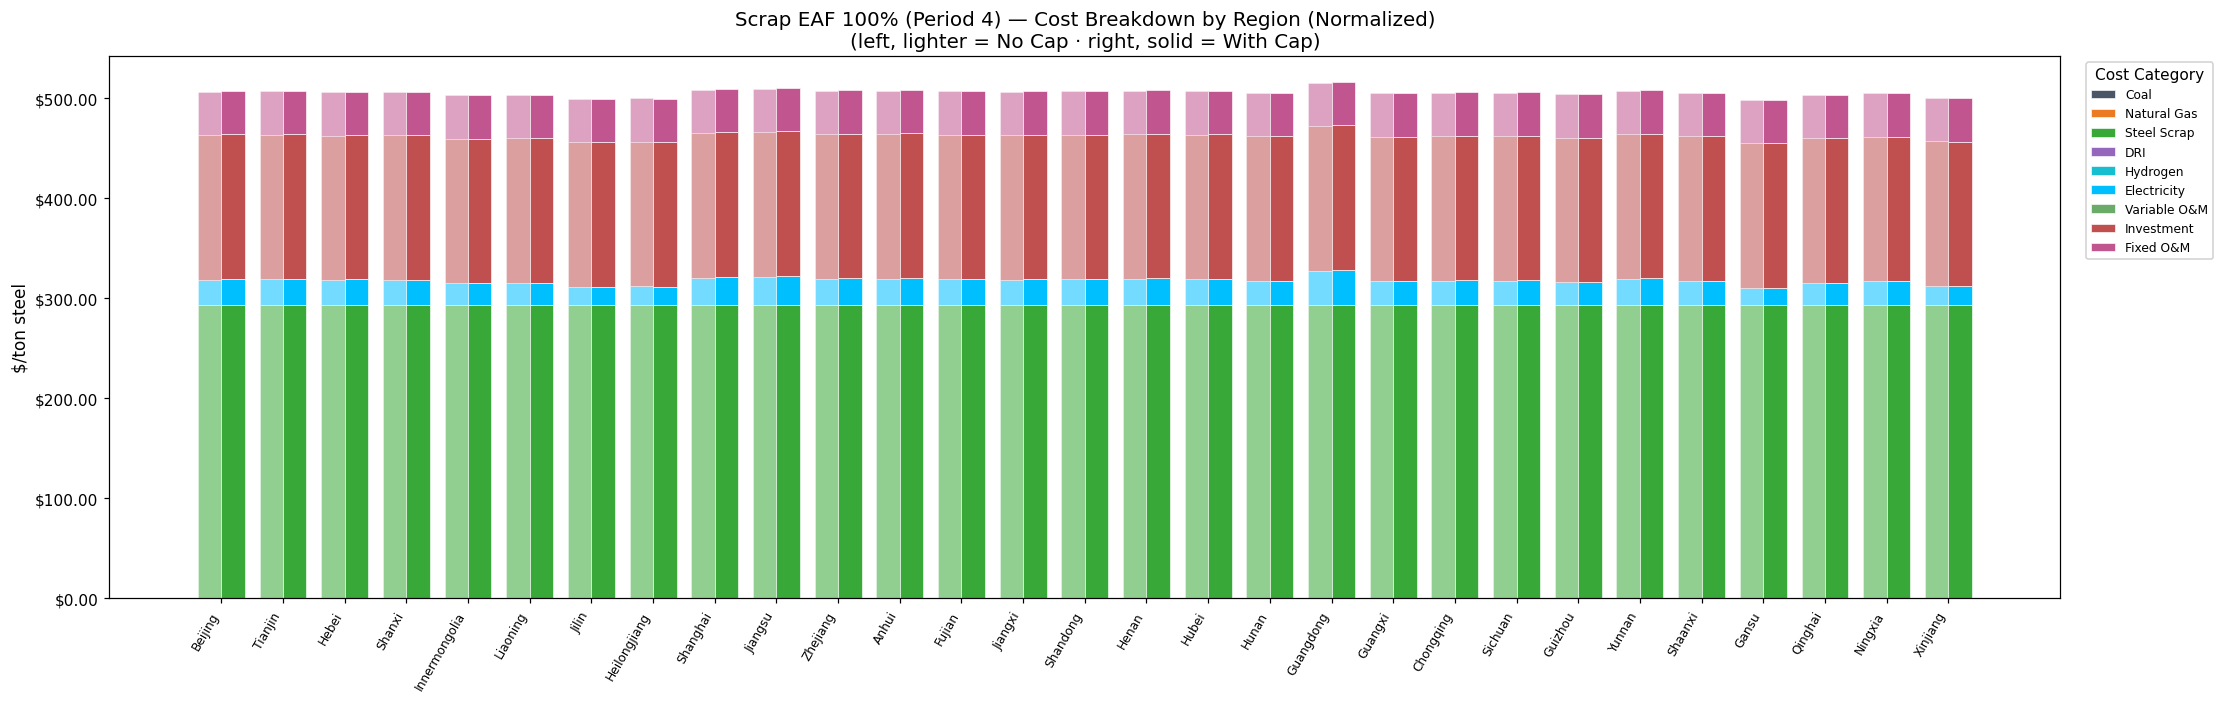

In [24]:
for period in PERIODS:
    plot_cost_stack_comparison(
        all_df, "scrapeaf100", period, value_col="cost_per_ton",
        title=f"Scrap EAF 100% (Period {period}) — Cost Breakdown by Region (Normalized)",
        ylabel="$/ton steel",
        decimals=2,
    )


## Scrap EAF 100% — national total, unnormalized (all provinces summed)

Raw $ cost, summed across all provinces (not divided by production), by
period and scenario.


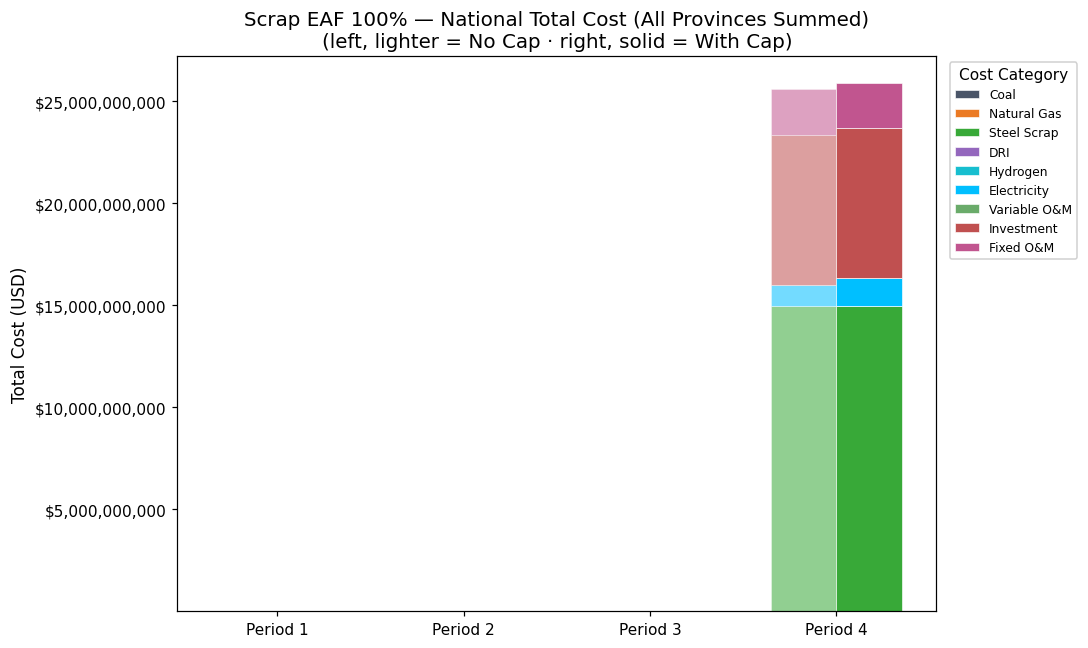

In [25]:
plot_national_total_comparison(
    all_df, "scrapeaf100",
    title="Scrap EAF 100% — National Total Cost (All Provinces Summed)",
)


## Save the detailed breakdown (all technologies, both scenarios, all periods) to CSV

In [26]:
out_path = BASE / "steelmaking_cost_breakdown_all_technologies.csv"
all_df.to_csv(out_path, index=False)
print(f"Saved {len(all_df)} rows to {out_path}")


Saved 10440 rows to /Users/chinnykwok/hmei/Net_Zero_China/NZC_Workshop_Example_Systems_June_2026/NZC_Workshop_All Sector_12day_MultiPeriods_WIP/case/results_tdr12days_062026/steelmaking_cost_breakdown_all_technologies.csv
